# Grupo 3: Cadena de Suministro de Ayuda Humanitaria

## Título y objetivo

Este notebook implementa un modelo reproducible de inventarios y distribución de ayuda humanitaria durante las 72 horas posteriores al terremoto en Ciudad UVG. El modelo distingue centros de acopio, zonas, suministros, rutas y vehículos, y utiliza bloques temporales de 6 horas.

## Imports y configuración

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Any
import re
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HORIZONTE_HORAS = 72
PASO_HORAS = 6
N_PASOS = HORIZONTE_HORAS // PASO_HORAS
N_RUNS = 100
SEMILLA_BASE = 2026

RUTA_EXCEL = Path("datos/Grupo3_CadenaSuministro.xlsx")
HOJA_DATOS = "Datos_Grupo3"

assert N_PASOS == 12
assert N_RUNS >= 30

# ------------------------------------------------------------
# Configuración central del modelo
# ------------------------------------------------------------

ZONAS_ESPERADAS = [
    "Z1",
    "Z2",
    "Z3",
    "Z4",
    "Z5",
]

SUMINISTROS_ESPERADOS = [
    "agua",
    "alimentos",
    "medicamentos",
]

MAPEO_NOMBRES_CENTROS = {
    "Bodega Central": "Bodega Central CONRED",
    "Bodega Central CONRED": "Bodega Central CONRED",
    "Almacén Norte": "Almacén Norte",
    "Depósito Sur": "Depósito Sur",
    "Centro Log. Z5": "Centro Logístico Z5",
    "Centro Logístico Z5": "Centro Logístico Z5",
}

MAPEO_DESTINOS_ZONAS = {
    "Albergue Z2": "Z2",
    "Albergue Z3": "Z3",
    "Albergue Z5-1": "Z5",
    "Albergue Z5-2": "Z5",
    "Albergue Estadio": None,
}

configuracion_modelo = {
    "horizonte_horas": HORIZONTE_HORAS,
    "paso_horas": PASO_HORAS,
    "n_pasos": N_PASOS,
    "zonas_esperadas": ZONAS_ESPERADAS,
    "suministros_esperados": SUMINISTROS_ESPERADOS,

    "mapeo_nombres_centros": MAPEO_NOMBRES_CENTROS,
    "mapeo_destinos_zonas": MAPEO_DESTINOS_ZONAS,

    "factor_distancia_retorno": 2.0,

    "fraccion_velocidad_ruta_danada": 0.40,

    "factor_tiempo_ruta_parcial": None,
    "factor_capacidad_ruta_parcial": None,
    "permitir_rutas_parciales_sin_actualizacion": False,

    "centro_receptor_reposicion": "Bodega Central CONRED",

    "factor_personas_por_m3_almacenamiento": 4.5,
    "cv_demanda_supuesto_poblacion_base": 0.15,
    "tipos_vehiculo_carga": ["camion_grande", "camioneta"],
    "semilla_base_convoy": SEMILLA_BASE,

    "acumular_demanda_no_satisfecha": False,

    "incertidumbre": {
        "cv_demanda": 0.0,
        "cv_tiempo_ruta": 0.0,
        "cv_reposicion": 0.0,
    },
}

assert configuracion_modelo["n_pasos"] == 12
assert 0 < configuracion_modelo[
    "fraccion_velocidad_ruta_danada"
] <= 1
assert configuracion_modelo[
    "factor_distancia_retorno"
] >= 1

print("CONFIGURACIÓN GENERAL: PASA")
print(
    "Bloques:",
    configuracion_modelo["n_pasos"],
)
print(
    "Zonas:",
    configuracion_modelo["zonas_esperadas"],
)
print(
    "Centro provisional de reposición:",
    configuracion_modelo["centro_receptor_reposicion"],
)

RUTA_DEMANDA_GRUPO1 = Path(
    "datos/output_grupo3_demanda_suministros.csv"
)

RUTA_REPORTE_GRUPO4 = Path(
    "datos/Grupo4_Reporte_Infraestructura.docx"
)

RUTA_SALIDA_GRUPO7 = Path("outputs/intercambio")
RUTA_ACTIVOS_REPORTE = Path("report_assets")
RUTA_REPORTE_TEX = Path("reporte_grupo3.tex")
RETRASO_INFORMACION_HORAS = 6

# Red original y tasas del Excel, centralizadas para que las
# verificaciones del intercambio no repitan literales sueltos.
RUTAS_ORIGINALES_EXCEL = [
    "Bodega Central → Albergue Estadio",
    "Bodega Central → Albergue Z2",
    "Bodega Central → Albergue Z5-1",
    "Bodega Central → Albergue Z5-2",
    "Almacén Norte → Albergue Z2",
    "Almacén Norte → Albergue Estadio",
    "Depósito Sur → Albergue Z3",
    "Centro Log. Z5 → Albergue Z5-1",
    "Centro Log. Z5 → Albergue Z5-2",
]

TASAS_CONSUMO_EXCEL = {
    "agua": 0.75,
    "alimentos": 0.25,
    "medicamentos": 0.0125,
}

configuracion_modelo["rutas_originales_excel"] = RUTAS_ORIGINALES_EXCEL
configuracion_modelo["tasas_consumo_excel"] = TASAS_CONSUMO_EXCEL
configuracion_modelo["ruta_salida_grupo7"] = RUTA_SALIDA_GRUPO7

CONFIGURACIÓN GENERAL: PASA
Bloques: 12
Zonas: ['Z1', 'Z2', 'Z3', 'Z4', 'Z5']
Centro provisional de reposición: Bodega Central CONRED


## Carga del Excel

In [2]:
def cargar_datos_grupo3(
    ruta_excel: str | Path
) -> dict[str, pd.DataFrame]:

    ruta_excel = Path(ruta_excel)

    if not ruta_excel.exists():
        raise FileNotFoundError(
            f"No se encontró el Excel del Grupo 3 en: "
            f"{ruta_excel.resolve()}"
        )

    archivo_excel = pd.ExcelFile(ruta_excel)
    nombres_hojas = archivo_excel.sheet_names

    if HOJA_DATOS not in nombres_hojas:
        raise ValueError(
            f"Falta la hoja requerida '{HOJA_DATOS}'. "
            f"Hojas encontradas: {nombres_hojas}"
        )

    hoja_completa = pd.read_excel(
        archivo_excel,
        sheet_name=HOJA_DATOS,
        header=None,
    )

    encabezados_secciones = {
        "centros": "1. CENTROS DE ACOPIO",
        "consumo": "2. TASAS DE CONSUMO",
        "rutas": "3. RED DE DISTRIBUCIÓN",
        "flota": "4. FLOTA DE VEHÍCULOS",
        "reposicion": "5. REPOSICIÓN DE SUMINISTROS",
        "output_requerido": "OUTPUT REQUERIDO",
    }

    texto_primera_columna = (
        hoja_completa.iloc[:, 0]
        .fillna("")
        .astype(str)
    )

    filas_secciones = {}

    for nombre, texto_buscado in encabezados_secciones.items():
        coincidencias = texto_primera_columna.str.contains(
            texto_buscado,
            case=False,
            regex=False,
        )

        filas_encontradas = hoja_completa.index[
            coincidencias
        ].tolist()

        filas_secciones[nombre] = (
            filas_encontradas[0]
            if filas_encontradas
            else None
        )

    print(f"Archivo cargado: {ruta_excel.name}")
    print(f"Hojas encontradas: {nombres_hojas}")
    print(
        f"Dimensiones de '{HOJA_DATOS}': "
        f"{hoja_completa.shape}"
    )
    print(
        "Filas iniciales de las secciones:",
        filas_secciones,
    )

    return {
        "hoja_completa": hoja_completa.copy(deep=True),
        "filas_secciones": pd.DataFrame(
            list(filas_secciones.items()),
            columns=["seccion", "fila_inicio"],
        ),
    }


datos_crudos = cargar_datos_grupo3(RUTA_EXCEL)

Archivo cargado: Grupo3_CadenaSuministro.xlsx
Hojas encontradas: ['Datos_Grupo3']
Dimensiones de 'Datos_Grupo3': (53, 6)
Filas iniciales de las secciones: {'centros': 4, 'consumo': 11, 'rutas': 17, 'flota': 29, 'reposicion': 35, 'output_requerido': 48}


## Normalización de tablas

### Centro de acopio

In [3]:
def normalizar_centros(
    hoja_completa: pd.DataFrame,
    fila_inicio: int,
) -> pd.DataFrame:

    if fila_inicio is None:
        raise ValueError(
            "No se encontró la sección de centros de acopio."
        )

    fila_encabezados = fila_inicio + 1
    primera_fila_datos = fila_inicio + 2
    ultima_fila_datos = primera_fila_datos + 4

    centros = hoja_completa.iloc[
        primera_fila_datos:ultima_fila_datos,
        0:6,
    ].copy()

    centros.columns = [
        "centro",
        "zona_original",
        "agua_litros",
        "alimentos_raciones",
        "medicamentos_kits",
        "capacidad_almacenamiento_m3",
    ]

    centros["zona"] = centros[
        "zona_original"
    ].str.extract(r"(Z\d+)", expand=False)

    columnas_numericas = [
        "agua_litros",
        "alimentos_raciones",
        "medicamentos_kits",
        "capacidad_almacenamiento_m3",
    ]

    for columna in columnas_numericas:
        centros[columna] = pd.to_numeric(
            centros[columna],
            errors="raise",
        )

    orden_columnas = [
        "centro",
        "zona",
        "zona_original",
        "agua_litros",
        "alimentos_raciones",
        "medicamentos_kits",
        "capacidad_almacenamiento_m3",
    ]

    return centros[orden_columnas].reset_index(drop=True)


fila_centros = int(
    datos_crudos["filas_secciones"]
    .set_index("seccion")
    .loc["centros", "fila_inicio"]
)

df_centros = normalizar_centros(
    datos_crudos["hoja_completa"],
    fila_centros,
)

display(df_centros)

,centro,zona,zona_original,agua_litros,alimentos_raciones,medicamentos_kits,capacidad_almacenamiento_m3
0,Bodega Central CONRED,Z4,Z4 (Este comercial),180000,42000,1200,2400
1,Almacén Norte,Z2,Z2 (Norte residencial),65000,18000,380,900
2,Depósito Sur,Z3,Z3 (Sur industrial),40000,9500,210,550
3,Centro Logístico Z5,Z5,Z5 (Oeste periférico),28000,7200,145,400


### Tasas de consumo

In [4]:
def normalizar_consumo(
    hoja_completa: pd.DataFrame,
    fila_inicio: int,
    paso_horas: int,
) -> pd.DataFrame:

    if fila_inicio is None:
        raise ValueError(
            "No se encontró la sección de tasas de consumo."
        )

    primera_fila_datos = fila_inicio + 2
    ultima_fila_datos = primera_fila_datos + 3

    consumo = hoja_completa.iloc[
        primera_fila_datos:ultima_fila_datos,
        0:4,
    ].copy()

    consumo.columns = [
        "suministro_original",
        "consumo_por_persona_dia",
        "unidad_original",
        "nota",
    ]

    nombres_normalizados = {
        "Agua potable": "agua",
        "Alimentos (raciones)": "alimentos",
        "Medicamentos básicos": "medicamentos",
    }

    consumo["suministro"] = consumo[
        "suministro_original"
    ].map(nombres_normalizados)

    consumo["consumo_por_persona_dia"] = pd.to_numeric(
        consumo["consumo_por_persona_dia"],
        errors="raise",
    )

    consumo["consumo_por_persona_bloque"] = (
        consumo["consumo_por_persona_dia"]
        * paso_horas
        / 24
    )

    unidades_por_bloque = {
        "agua": "litros/persona/bloque",
        "alimentos": "raciones/persona/bloque",
        "medicamentos": "kits/persona/bloque",
    }

    consumo["unidad_por_bloque"] = consumo[
        "suministro"
    ].map(unidades_por_bloque)

    orden_columnas = [
        "suministro",
        "suministro_original",
        "consumo_por_persona_dia",
        "unidad_original",
        "consumo_por_persona_bloque",
        "unidad_por_bloque",
        "nota",
    ]

    return consumo[orden_columnas].reset_index(drop=True)


fila_consumo = int(
    datos_crudos["filas_secciones"]
    .set_index("seccion")
    .loc["consumo", "fila_inicio"]
)

df_consumo = normalizar_consumo(
    datos_crudos["hoja_completa"],
    fila_consumo,
    PASO_HORAS,
)

display(df_consumo)

,suministro,suministro_original,consumo_por_persona_dia,unidad_original,consumo_por_persona_bloque,unidad_por_bloque,nota
0,agua,Agua potable,3.00,litros,0.7500,litros/persona/bloque,Mínimo OPS en emergencia
1,alimentos,Alimentos (raciones),1.00,ración/día,0.2500,raciones/persona/bloque,Ración = 2100 kcal
2,medicamentos,Medicamentos básicos,0.05,kit/persona,0.0125,kits/persona/bloque,1 kit cubre 20 personas/día


### Red de distribución

In [5]:
def normalizar_rutas(
    hoja_completa: pd.DataFrame,
    fila_inicio: int,
) -> pd.DataFrame:

    if fila_inicio is None:
        raise ValueError(
            "No se encontró la sección de la red de distribución."
        )

    primera_fila_datos = fila_inicio + 2
    ultima_fila_datos = primera_fila_datos + 9

    rutas = hoja_completa.iloc[
        primera_fila_datos:ultima_fila_datos,
        0:5,
    ].copy()

    rutas.columns = [
        "ruta_original",
        "distancia_km",
        "tiempo_normal_h",
        "capacidad_vehiculos_viaje",
        "estado_ruta",
    ]

    componentes_ruta = rutas["ruta_original"].str.split(
        r"\s*(?:→|->)\s*",
        n=1,
        expand=True,
        regex=True,
    )

    rutas["origen"] = componentes_ruta[0].str.strip()
    rutas["destino"] = componentes_ruta[1].str.strip()

    columnas_numericas = [
        "distancia_km",
        "tiempo_normal_h",
        "capacidad_vehiculos_viaje",
    ]

    for columna in columnas_numericas:
        rutas[columna] = pd.to_numeric(
            rutas[columna],
            errors="raise",
        )

    rutas["ruta_id"] = [
        f"R{i:02d}"
        for i in range(1, len(rutas) + 1)
    ]

    orden_columnas = [
        "ruta_id",
        "ruta_original",
        "origen",
        "destino",
        "distancia_km",
        "tiempo_normal_h",
        "capacidad_vehiculos_viaje",
        "estado_ruta",
    ]

    return rutas[orden_columnas].reset_index(drop=True)


fila_rutas = int(
    datos_crudos["filas_secciones"]
    .set_index("seccion")
    .loc["rutas", "fila_inicio"]
)

df_rutas = normalizar_rutas(
    datos_crudos["hoja_completa"],
    fila_rutas,
)

display(df_rutas)

,ruta_id,ruta_original,origen,destino,distancia_km,tiempo_normal_h,capacidad_vehiculos_viaje,estado_ruta
0,R01,Bodega Central → Albergue Estadio,Bodega Central,Albergue Estadio,4.2,0.4,8,Disponible
1,R02,Bodega Central → Albergue Z2,Bodega Central,Albergue Z2,7.8,0.9,6,Disponible
2,R03,Bodega Central → Albergue Z5-1,Bodega Central,Albergue Z5-1,12.1,2.8,4,Dañada — velocidad reducida 60%
3,R04,Bodega Central → Albergue Z5-2,Bodega Central,Albergue Z5-2,13.4,3.5,3,Dañada — velocidad reducida 60%
4,R05,Almacén Norte → Albergue Z2,Almacén Norte,Albergue Z2,2.1,0.2,10,Disponible
5,R06,Almacén Norte → Albergue Estadio,Almacén Norte,Albergue Estadio,6.4,0.7,7,Disponible
6,R07,Depósito Sur → Albergue Z3,Depósito Sur,Albergue Z3,3.8,0.4,8,Disponible
7,R08,Centro Log. Z5 → Albergue Z5-1,Centro Log. Z5,Albergue Z5-1,1.2,0.5,6,Parcialmente bloqueada
8,R09,Centro Log. Z5 → Albergue Z5-2,Centro Log. Z5,Albergue Z5-2,2.4,0.9,5,Parcialmente bloqueada


### Flota de vehículos

In [6]:
def normalizar_flota(
    hoja_completa: pd.DataFrame,
    fila_inicio: int,
) -> pd.DataFrame:

    if fila_inicio is None:
        raise ValueError(
            "No se encontró la sección de la flota de vehículos."
        )

    primera_fila_datos = fila_inicio + 2
    ultima_fila_datos = primera_fila_datos + 3

    flota = hoja_completa.iloc[
        primera_fila_datos:ultima_fila_datos,
        0:5,
    ].copy()

    flota.columns = [
        "tipo_vehiculo_original",
        "cantidad_disponible",
        "capacidad_m3",
        "consumo_combustible_gal_km",
        "combustible_disponible_gal",
    ]

    nombres_normalizados = {
        "Camión grande (10 ton)": "camion_grande",
        "Camioneta (2 ton)": "camioneta",
        "Motocicleta (mensajería)": "motocicleta",
    }

    flota["tipo_vehiculo"] = flota[
        "tipo_vehiculo_original"
    ].map(nombres_normalizados)

    columnas_numericas = [
        "cantidad_disponible",
        "capacidad_m3",
        "consumo_combustible_gal_km",
        "combustible_disponible_gal",
    ]

    for columna in columnas_numericas:
        flota[columna] = pd.to_numeric(
            flota[columna],
            errors="raise",
        )

    flota["cantidad_disponible"] = flota[
        "cantidad_disponible"
    ].astype(int)

    orden_columnas = [
        "tipo_vehiculo",
        "tipo_vehiculo_original",
        "cantidad_disponible",
        "capacidad_m3",
        "consumo_combustible_gal_km",
        "combustible_disponible_gal",
    ]

    return flota[orden_columnas].reset_index(drop=True)


fila_flota = int(
    datos_crudos["filas_secciones"]
    .set_index("seccion")
    .loc["flota", "fila_inicio"]
)

df_flota = normalizar_flota(
    datos_crudos["hoja_completa"],
    fila_flota,
)

display(df_flota)

,tipo_vehiculo,tipo_vehiculo_original,cantidad_disponible,capacidad_m3,consumo_combustible_gal_km,combustible_disponible_gal
0,camion_grande,Camión grande (10 ton),8,28.0,0.18,1400
1,camioneta,Camioneta (2 ton),22,8.0,0.09,1800
2,motocicleta,Motocicleta (mensajería),15,0.3,0.03,420


### Reposiciones

In [7]:
def normalizar_reposicion(
    hoja_completa: pd.DataFrame,
    fila_inicio: int,
) -> pd.DataFrame:

    if fila_inicio is None:
        raise ValueError(
            "No se encontró la sección de reposición de suministros."
        )

    primera_fila_datos = fila_inicio + 2

    ultima_fila_datos = primera_fila_datos + 6

    reposicion = hoja_completa.iloc[
        primera_fila_datos:ultima_fila_datos,
        0:5,
    ].copy()

    reposicion.columns = [
        "bloque_original",
        "agua_adicional_litros",
        "alimentos_adicionales_raciones",
        "medicamentos_adicionales_kits",
        "fuente",
    ]

    componentes_tiempo = reposicion[
        "bloque_original"
    ].str.extract(
        r"T(\d+)\s*\((\d+)-(\d+)h\)"
    )

    componentes_tiempo.columns = [
        "bloque",
        "hora_inicio",
        "hora_fin",
    ]

    reposicion[
        ["bloque", "hora_inicio", "hora_fin"]
    ] = componentes_tiempo.astype(int)

    columnas_numericas = [
        "agua_adicional_litros",
        "alimentos_adicionales_raciones",
        "medicamentos_adicionales_kits",
    ]

    for columna in columnas_numericas:
        reposicion[columna] = pd.to_numeric(
            reposicion[columna],
            errors="raise",
        )

    orden_columnas = [
        "bloque",
        "bloque_original",
        "hora_inicio",
        "hora_fin",
        "agua_adicional_litros",
        "alimentos_adicionales_raciones",
        "medicamentos_adicionales_kits",
        "fuente",
    ]

    return reposicion[orden_columnas].reset_index(drop=True)


fila_reposicion = int(
    datos_crudos["filas_secciones"]
    .set_index("seccion")
    .loc["reposicion", "fila_inicio"]
)

df_reposicion = normalizar_reposicion(
    datos_crudos["hoja_completa"],
    fila_reposicion,
)

display(df_reposicion)

,bloque,bloque_original,hora_inicio,hora_fin,agua_adicional_litros,alimentos_adicionales_raciones,medicamentos_adicionales_kits,fuente
0,2,T2 (12-18h),12,18,0,0,0,Sin reposición aún
1,3,T3 (18-24h),18,24,40000,8000,200,Cruz Roja — primer convoy
2,4,T4 (24-30h),24,30,80000,15000,400,Gobierno central
3,6,T6 (36-42h),36,42,120000,22000,600,Ayuda internacional
4,8,T8 (48-54h),48,54,150000,28000,800,Ayuda internacional
5,10,T10 (60-66h),60,66,100000,18000,500,Cruz Roja — segundo convoy


### Output requerido para Grupo 7

In [8]:
def normalizar_output_requerido(
    hoja_completa: pd.DataFrame,
    fila_inicio: int,
) -> pd.DataFrame:

    if fila_inicio is None:
        raise ValueError(
            "No se encontró la sección de output requerido."
        )

    primera_fila_datos = fila_inicio + 2

    output_requerido = (
        hoja_completa.iloc[primera_fila_datos:, 0]
        .dropna()
        .astype(str)
        .str.strip()
    )

    output_requerido = output_requerido[
        output_requerido.ne("")
    ].reset_index(drop=True)

    if len(output_requerido) != 3:
        raise ValueError(
            "Se esperaban 3 outputs requeridos, pero se "
            f"encontraron {len(output_requerido)}."
        )

    nombres_output = [
        "balance_suministros",
        "primer_agotamiento",
        "recomendacion_logistica",
    ]

    tabla_output = pd.DataFrame(
        {
            "output_id": [
                "O01",
                "O02",
                "O03",
            ],
            "nombre_output": nombres_output,
            "descripcion_original": output_requerido,
        }
    )

    return tabla_output


fila_output_requerido = int(
    datos_crudos["filas_secciones"]
    .set_index("seccion")
    .loc["output_requerido", "fila_inicio"]
)

df_output_requerido = normalizar_output_requerido(
    datos_crudos["hoja_completa"],
    fila_output_requerido,
)

display(df_output_requerido)

,output_id,nombre_output,descripcion_original
0,O01,balance_suministros,a) Balance de suministros por bloque de tiempo...
1,O02,primer_agotamiento,b) Identificación del momento en que algún sum...
2,O03,recomendacion_logistica,c) Recomendación de priorización de rutas y fr...


### Función de normalización

In [9]:
def normalizar_datos_grupo3(
    datos: dict[str, pd.DataFrame],
) -> dict[str, pd.DataFrame]:

    claves_requeridas = {
        "hoja_completa",
        "filas_secciones",
    }

    claves_faltantes = claves_requeridas.difference(
        datos.keys()
    )

    if claves_faltantes:
        raise KeyError(
            "Faltan estructuras necesarias para normalizar: "
            f"{sorted(claves_faltantes)}"
        )

    hoja_completa = datos["hoja_completa"]

    filas_secciones = (
        datos["filas_secciones"]
        .set_index("seccion")["fila_inicio"]
        .to_dict()
    )

    secciones_requeridas = [
        "centros",
        "consumo",
        "rutas",
        "flota",
        "reposicion",
        "output_requerido",
    ]

    secciones_no_encontradas = [
        seccion
        for seccion in secciones_requeridas
        if pd.isna(filas_secciones.get(seccion))
    ]

    if secciones_no_encontradas:
        raise ValueError(
            "No se localizaron las siguientes secciones: "
            f"{secciones_no_encontradas}"
        )

    df_centros_normalizado = normalizar_centros(
        hoja_completa,
        int(filas_secciones["centros"]),
    )

    df_consumo_normalizado = normalizar_consumo(
        hoja_completa,
        int(filas_secciones["consumo"]),
        PASO_HORAS,
    )

    df_rutas_normalizado = normalizar_rutas(
        hoja_completa,
        int(filas_secciones["rutas"]),
    )

    df_flota_normalizado = normalizar_flota(
        hoja_completa,
        int(filas_secciones["flota"]),
    )

    df_reposicion_normalizado = normalizar_reposicion(
        hoja_completa,
        int(filas_secciones["reposicion"]),
    )

    df_output_normalizado = normalizar_output_requerido(
        hoja_completa,
        int(filas_secciones["output_requerido"]),
    )

    return {
        "centros": df_centros_normalizado,
        "consumo": df_consumo_normalizado,
        "rutas": df_rutas_normalizado,
        "flota": df_flota_normalizado,
        "reposicion": df_reposicion_normalizado,
        "output_requerido": df_output_normalizado,
    }


datos_modelo = normalizar_datos_grupo3(datos_crudos)

resumen_tablas = pd.DataFrame(
    {
        "tabla": datos_modelo.keys(),
        "filas": [
            len(tabla)
            for tabla in datos_modelo.values()
        ],
        "columnas": [
            len(tabla.columns)
            for tabla in datos_modelo.values()
        ],
    }
)

display(resumen_tablas)

,tabla,filas,columnas
0,centros,4,7
1,consumo,3,7
2,rutas,9,8
3,flota,3,6
4,reposicion,6,8
5,output_requerido,3,3


## Validación de datos

In [10]:
def validar_datos_grupo3(
    datos: dict[str, pd.DataFrame],
) -> None:

    errores = []
    advertencias = []
    pruebas_superadas = []

    tablas_requeridas = {
        "centros",
        "consumo",
        "rutas",
        "flota",
        "reposicion",
        "output_requerido",
    }

    tablas_faltantes = tablas_requeridas.difference(datos.keys())

    if tablas_faltantes:
        errores.append(
            f"Faltan tablas requeridas: {sorted(tablas_faltantes)}"
        )

    if errores:
        raise ValueError("\n".join(errores))

    centros = datos["centros"]
    consumo = datos["consumo"]
    rutas = datos["rutas"]
    flota = datos["flota"]
    reposicion = datos["reposicion"]
    output_requerido = datos["output_requerido"]

    cantidades_esperadas = {
        "centros": (len(centros), 4),
        "suministros": (len(consumo), 3),
        "rutas": (len(rutas), 9),
        "tipos de vehículo": (len(flota), 3),
        "reposiciones": (len(reposicion), 6),
        "outputs requeridos": (len(output_requerido), 3),
    }

    for nombre, (cantidad_real, cantidad_esperada) in (
        cantidades_esperadas.items()
    ):
        if cantidad_real != cantidad_esperada:
            errores.append(
                f"{nombre}: se esperaban {cantidad_esperada} "
                f"registros y se encontraron {cantidad_real}."
            )
        else:
            pruebas_superadas.append(
                f"{nombre}: {cantidad_real} registros"
            )

    columnas_obligatorias = {
        "centros": [
            "centro",
            "zona",
            "agua_litros",
            "alimentos_raciones",
            "medicamentos_kits",
            "capacidad_almacenamiento_m3",
        ],
        "consumo": [
            "suministro",
            "consumo_por_persona_dia",
            "consumo_por_persona_bloque",
        ],
        "rutas": [
            "ruta_id",
            "origen",
            "destino",
            "distancia_km",
            "tiempo_normal_h",
            "capacidad_vehiculos_viaje",
            "estado_ruta",
        ],
        "flota": [
            "tipo_vehiculo",
            "cantidad_disponible",
            "capacidad_m3",
            "consumo_combustible_gal_km",
            "combustible_disponible_gal",
        ],
        "reposicion": [
            "bloque",
            "hora_inicio",
            "hora_fin",
            "agua_adicional_litros",
            "alimentos_adicionales_raciones",
            "medicamentos_adicionales_kits",
            "fuente",
        ],
        "output_requerido": [
            "output_id",
            "nombre_output",
            "descripcion_original",
        ],
    }

    for nombre_tabla, columnas in columnas_obligatorias.items():
        tabla = datos[nombre_tabla]

        faltantes = tabla[columnas].isna().sum()
        faltantes = faltantes[faltantes > 0]

        if not faltantes.empty:
            errores.append(
                f"{nombre_tabla}: valores faltantes en "
                f"{faltantes.to_dict()}."
            )
        else:
            pruebas_superadas.append(
                f"{nombre_tabla}: sin valores faltantes obligatorios"
            )

    identificadores = {
        "centros": "centro",
        "consumo": "suministro",
        "rutas": "ruta_id",
        "flota": "tipo_vehiculo",
        "reposicion": "bloque",
        "output_requerido": "output_id",
    }

    for nombre_tabla, identificador in identificadores.items():
        tabla = datos[nombre_tabla]

        if tabla[identificador].duplicated().any():
            valores_duplicados = tabla.loc[
                tabla[identificador].duplicated(keep=False),
                identificador,
            ].tolist()

            errores.append(
                f"{nombre_tabla}: identificadores duplicados "
                f"{valores_duplicados}."
            )
        else:
            pruebas_superadas.append(
                f"{nombre_tabla}: sin identificadores duplicados"
            )

    columnas_no_negativas = {
        "centros": [
            "agua_litros",
            "alimentos_raciones",
            "medicamentos_kits",
            "capacidad_almacenamiento_m3",
        ],
        "consumo": [
            "consumo_por_persona_dia",
            "consumo_por_persona_bloque",
        ],
        "flota": [
            "cantidad_disponible",
            "capacidad_m3",
            "consumo_combustible_gal_km",
            "combustible_disponible_gal",
        ],
        "reposicion": [
            "agua_adicional_litros",
            "alimentos_adicionales_raciones",
            "medicamentos_adicionales_kits",
        ],
    }

    for nombre_tabla, columnas in columnas_no_negativas.items():
        tabla = datos[nombre_tabla]

        for columna in columnas:
            if (tabla[columna] < 0).any():
                errores.append(
                    f"{nombre_tabla}.{columna} contiene "
                    "valores negativos."
                )

    columnas_positivas_rutas = [
        "distancia_km",
        "tiempo_normal_h",
        "capacidad_vehiculos_viaje",
    ]

    for columna in columnas_positivas_rutas:
        if (rutas[columna] <= 0).any():
            errores.append(
                f"rutas.{columna} contiene valores menores "
                "o iguales a cero."
            )

    bloques_esperados_reposicion = {2, 3, 4, 6, 8, 10}
    bloques_observados = set(reposicion["bloque"])

    if bloques_observados != bloques_esperados_reposicion:
        errores.append(
            "Los bloques de reposición no coinciden con "
            f"{sorted(bloques_esperados_reposicion)}."
        )
    else:
        pruebas_superadas.append(
            "bloques de reposición: T2, T3, T4, T6, T8 y T10"
        )

    duracion_reposiciones = (
        reposicion["hora_fin"] - reposicion["hora_inicio"]
    )

    if not (duracion_reposiciones == PASO_HORAS).all():
        errores.append(
            "Algún intervalo de reposición no dura "
            f"{PASO_HORAS} horas."
        )
    else:
        pruebas_superadas.append(
            "intervalos de reposición: 6 horas"
        )

    if not (
        reposicion["hora_inicio"]
        == reposicion["bloque"] * PASO_HORAS
    ).all():
        errores.append(
            "La hora inicial no coincide con bloque × PASO_HORAS."
        )
    else:
        pruebas_superadas.append(
            "correspondencia correcta entre bloques y horas"
        )

    consumo_esperado_bloque = (
        consumo["consumo_por_persona_dia"]
        * PASO_HORAS
        / 24
    )

    if not np.allclose(
        consumo["consumo_por_persona_bloque"],
        consumo_esperado_bloque,
    ):
        errores.append(
            "Las tasas de consumo por bloque no coinciden con "
            "las tasas diarias convertidas a seis horas."
        )
    else:
        pruebas_superadas.append(
            "tasas por bloque derivadas correctamente"
        )

    estados_permitidos = {
        "Disponible",
        "Dañada — velocidad reducida 60%",
        "Parcialmente bloqueada",
    }

    estados_desconocidos = (
        set(rutas["estado_ruta"]) - estados_permitidos
    )

    if estados_desconocidos:
        errores.append(
            f"Estados de ruta no reconocidos: {estados_desconocidos}."
        )
    else:
        pruebas_superadas.append(
            "estados de ruta originales preservados"
        )

    nombres_centros = set(centros["centro"])
    origenes_rutas = set(rutas["origen"])
    origenes_sin_coincidencia = origenes_rutas - nombres_centros

    if origenes_sin_coincidencia:
        advertencias.append(
            "Algunos nombres de origen no coinciden literalmente "
            "con la tabla de centros: "
            f"{sorted(origenes_sin_coincidencia)}. "
            "Se necesitará un mapeo explícito."
        )

    if errores:
        mensaje = "\n".join(
            f"- {error}" for error in errores
        )
        raise ValueError(
            "La validación encontró errores críticos:\n"
            f"{mensaje}"
        )

    print("VALIDACIÓN GENERAL: PASA")

    print("\nPruebas superadas:")
    for prueba in pruebas_superadas:
        print(f"  PASA — {prueba}")

    if advertencias:
        print("\nAdvertencias que requieren documentación:")
        for advertencia in advertencias:
            print(f"  ADVERTENCIA — {advertencia}")


validar_datos_grupo3(datos_modelo)

VALIDACIÓN GENERAL: PASA

Pruebas superadas:
  PASA — centros: 4 registros
  PASA — suministros: 3 registros
  PASA — rutas: 9 registros
  PASA — tipos de vehículo: 3 registros
  PASA — reposiciones: 6 registros
  PASA — outputs requeridos: 3 registros
  PASA — centros: sin valores faltantes obligatorios
  PASA — consumo: sin valores faltantes obligatorios
  PASA — rutas: sin valores faltantes obligatorios
  PASA — flota: sin valores faltantes obligatorios
  PASA — reposicion: sin valores faltantes obligatorios
  PASA — output_requerido: sin valores faltantes obligatorios
  PASA — centros: sin identificadores duplicados
  PASA — consumo: sin identificadores duplicados
  PASA — rutas: sin identificadores duplicados
  PASA — flota: sin identificadores duplicados
  PASA — reposicion: sin identificadores duplicados
  PASA — output_requerido: sin identificadores duplicados
  PASA — bloques de reposición: T2, T3, T4, T6, T8 y T10
  PASA — intervalos de reposición: 6 horas
  PASA — correspond

### Tabla de trazabilidad de los datos

In [11]:
tabla_trazabilidad = pd.DataFrame(
    [
        {
            "dato": "Inventario inicial de agua",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Centros de acopio",
            "unidad": "litros",
            "uso_en_modelo": (
                "Estado inicial del inventario de agua por centro"
            ),
            "transformacion": (
                "Conversión de formato tabular; valor sin modificar"
            ),
        },
        {
            "dato": "Inventario inicial de alimentos",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Centros de acopio",
            "unidad": "raciones",
            "uso_en_modelo": (
                "Estado inicial del inventario de alimentos por centro"
            ),
            "transformacion": (
                "Conversión de formato tabular; valor sin modificar"
            ),
        },
        {
            "dato": "Inventario inicial de medicamentos",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Centros de acopio",
            "unidad": "kits",
            "uso_en_modelo": (
                "Estado inicial del inventario de medicamentos por centro"
            ),
            "transformacion": (
                "Conversión de formato tabular; valor sin modificar"
            ),
        },
        {
            "dato": "Capacidad de almacenamiento",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Centros de acopio",
            "unidad": "m³",
            "uso_en_modelo": (
                "Referencia de capacidad física de cada centro"
            ),
            "transformacion": (
                "No se aplica todavía como restricción porque faltan "
                "factores de conversión de suministros a m³"
            ),
        },
        {
            "dato": "Consumo per cápita",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Tasas de consumo",
            "unidad": "unidad de suministro/persona/día",
            "uso_en_modelo": (
                "Cálculo de demanda de agua, alimentos y medicamentos"
            ),
            "transformacion": (
                "consumo_diario × PASO_HORAS / 24"
            ),
        },
        {
            "dato": "Distancia de las rutas",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Red de distribución",
            "unidad": "km",
            "uso_en_modelo": (
                "Cálculo de tiempo logístico y consumo de combustible"
            ),
            "transformacion": (
                "Valor sin modificar; falta definir si se considera "
                "viaje de ida o de ida y vuelta"
            ),
        },
        {
            "dato": "Tiempo normal de ruta",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Red de distribución",
            "unidad": "horas",
            "uso_en_modelo": (
                "Programación de llegadas de los vehículos"
            ),
            "transformacion": (
                "Valor sin modificar antes de aplicar el estado de ruta"
            ),
        },
        {
            "dato": "Capacidad de vehículos por viaje",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Red de distribución",
            "unidad": "vehículos/viaje",
            "uso_en_modelo": (
                "Restricción del número de vehículos utilizables por ruta"
            ),
            "transformacion": "Valor sin modificar",
        },
        {
            "dato": "Estado de ruta post-sismo",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Red de distribución",
            "unidad": "categoría",
            "uso_en_modelo": (
                "Modificación de disponibilidad, tiempo o capacidad"
            ),
            "transformacion": (
                "Se conserva el texto original; la interpretación "
                "cuantitativa será un parámetro documentado"
            ),
        },
        {
            "dato": "Cantidad de vehículos",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Flota",
            "unidad": "vehículos",
            "uso_en_modelo": (
                "Restricción de la flota disponible por tipo"
            ),
            "transformacion": "Conversión a número entero",
        },
        {
            "dato": "Capacidad de los vehículos",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Flota",
            "unidad": "m³/vehículo",
            "uso_en_modelo": (
                "Capacidad máxima de transporte por viaje"
            ),
            "transformacion": (
                "No se usa para convertir suministros hasta disponer "
                "de equivalencias de litros, raciones y kits a m³"
            ),
        },
        {
            "dato": "Consumo de combustible",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Flota",
            "unidad": "gal/km",
            "uso_en_modelo": (
                "Cálculo del combustible consumido por viaje"
            ),
            "transformacion": "Valor sin modificar",
        },
        {
            "dato": "Combustible disponible",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Flota",
            "unidad": "galones",
            "uso_en_modelo": (
                "Restricción acumulada de las operaciones logísticas"
            ),
            "transformacion": "Valor sin modificar",
        },
        {
            "dato": "Reposiciones externas",
            "fuente": "Grupo3_CadenaSuministro.xlsx — Reposición",
            "unidad": "litros, raciones y kits",
            "uso_en_modelo": (
                "Flujo de entrada al inventario durante la simulación"
            ),
            "transformacion": (
                "Separación de bloque, hora inicial y hora final"
            ),
        },
        {
            "dato": "Población desplazada",
            "fuente": "Pendiente de output formal del Grupo 1",
            "unidad": "personas por zona y bloque",
            "uso_en_modelo": (
                "Conversión de población en demanda de suministros"
            ),
            "transformacion": (
                "personas × consumo_por_persona_bloque"
            ),
        },
        {
            "dato": "Accesibilidad actualizada",
            "fuente": "Pendiente de output formal del Grupo 4",
            "unidad": "estado, horas e índice entre 0 y 1",
            "uso_en_modelo": (
                "Actualización de rutas, tiempos y restricciones de acceso"
            ),
            "transformacion": (
                "Se definirá después del intercambio presencial"
            ),
        },
    ]
)

display(tabla_trazabilidad)

,dato,fuente,unidad,uso_en_modelo,transformacion
0,Inventario inicial de agua,Grupo3_CadenaSuministro.xlsx — Centros de acopio,litros,Estado inicial del inventario de agua por centro,Conversión de formato tabular; valor sin modif...
1,Inventario inicial de alimentos,Grupo3_CadenaSuministro.xlsx — Centros de acopio,raciones,Estado inicial del inventario de alimentos por...,Conversión de formato tabular; valor sin modif...
2,Inventario inicial de medicamentos,Grupo3_CadenaSuministro.xlsx — Centros de acopio,kits,Estado inicial del inventario de medicamentos ...,Conversión de formato tabular; valor sin modif...
3,Capacidad de almacenamiento,Grupo3_CadenaSuministro.xlsx — Centros de acopio,m³,Referencia de capacidad física de cada centro,No se aplica todavía como restricción porque f...
4,Consumo per cápita,Grupo3_CadenaSuministro.xlsx — Tasas de consumo,unidad de suministro/persona/día,"Cálculo de demanda de agua, alimentos y medica...",consumo_diario × PASO_HORAS / 24
5,Distancia de las rutas,Grupo3_CadenaSuministro.xlsx — Red de distribu...,km,Cálculo de tiempo logístico y consumo de combu...,Valor sin modificar; falta definir si se consi...
6,Tiempo normal de ruta,Grupo3_CadenaSuministro.xlsx — Red de distribu...,horas,Programación de llegadas de los vehículos,Valor sin modificar antes de aplicar el estado...
7,Capacidad de vehículos por viaje,Grupo3_CadenaSuministro.xlsx — Red de distribu...,vehículos/viaje,Restricción del número de vehículos utilizable...,Valor sin modificar
8,Estado de ruta post-sismo,Grupo3_CadenaSuministro.xlsx — Red de distribu...,categoría,"Modificación de disponibilidad, tiempo o capac...",Se conserva el texto original; la interpretaci...
9,Cantidad de vehículos,Grupo3_CadenaSuministro.xlsx — Flota,vehículos,Restricción de la flota disponible por tipo,Conversión a número entero


## Descripción del caso

El modelo representa la cadena de suministro de ayuda humanitaria de Ciudad UVG durante las primeras 72 horas posteriores a un terremoto de magnitud 6.8. El sistema debe distribuir agua potable, raciones de alimentos y kits de medicamentos desde cuatro centros de acopio hacia los albergues afectados, usando una red de nueve rutas y una flota heterogénea de camiones, camionetas y motocicletas.

El horizonte se divide en 12 bloques de 6 horas. En cada bloque, los inventarios pueden aumentar por la llegada de reposiciones externas y disminuir por el consumo asociado con la población desplazada. La distribución está limitada por el estado de las rutas, el número de vehículos que puede circular por cada ruta y el combustible disponible.

La unidad principal de análisis es la combinación de zona, suministro y bloque de tiempo. La heterogeneidad del sistema se conserva mediante inventarios iniciales diferentes entre centros, tasas de consumo específicas para cada suministro, rutas con distintas distancias y condiciones, y vehículos con capacidades y consumos de combustible diferentes.

El modelo debe producir tres resultados principales: el balance de suministros por zona, suministro y bloque; la identificación del primer agotamiento crítico sin intervención adicional; y una recomendación de priorización de rutas y frecuencia de distribución que busque maximizar la cobertura bajo la restricción de combustible disponible.

Durante la fase previa al intercambio se utilizan exclusivamente los datos oficiales del Grupo 3. La demanda por zona y bloque se incorporará posteriormente mediante la proyección formal entregada por el Grupo 1, mientras que las condiciones actualizadas de accesibilidad se incorporarán mediante el output formal del Grupo 4. Ambos escenarios deberán conservarse para identificar si la información recibida cambia o confirma la zona inicialmente considerada más crítica.

## Justificación del paradigma

Para seleccionar el paradigma se consideran la naturaleza de las variables, el nivel de agregación, la importancia del orden temporal y el tipo de pregunta que debe responder el modelo. El sistema combina inventarios que evolucionan continuamente por entradas y salidas con operaciones logísticas que ocurren en momentos específicos. Por ello se adopta una arquitectura híbrida basada en **Dinámica de Sistemas (SD)** y **Simulación de Eventos Discretos (DES)**, implementada sobre bloques de 6 horas.

La Dinámica de Sistemas es apropiada para representar los suministros como *stocks*. El inventario de agua, alimentos y medicamentos aumenta mediante las reposiciones recibidas y disminuye mediante el consumo satisfecho. Esta representación permite analizar las trayectorias de inventario, los déficits acumulados y el momento de agotamiento de cada suministro. Aunque la implementación utiliza ecuaciones en tiempo discreto, conserva la lógica fundamental de stocks y flujos.

La Simulación de Eventos Discretos complementa este componente porque las salidas y llegadas de convoyes, los viajes por las rutas y las reposiciones externas ocurren como eventos identificables. Estos eventos modifican el estado del sistema en momentos determinados y están condicionados por el tiempo de viaje, la capacidad de las rutas, la disponibilidad de vehículos y el combustible restante. Su representación permite distinguir entre inventario almacenado, inventario en tránsito e inventario efectivamente recibido.

La frontera entre ambos componentes se define de la siguiente manera: SD representa el balance agregado de inventarios y demanda por zona, suministro y bloque, mientras que DES representa las operaciones logísticas que trasladan suministros y determinan cuándo una carga pasa a estar disponible en su destino. El estado resultante de los eventos logísticos alimenta las entradas del balance de inventario.

Un modelo exclusivamente de Dinámica de Sistemas sería suficiente para estudiar un inventario agregado si las entregas fueran instantáneas y las rutas no importaran. Sin embargo, representaría con menor precisión los retrasos, bloqueos y llegadas de convoyes que afectan la disponibilidad real de la ayuda. Por otra parte, un modelo exclusivamente DES podría representar cada viaje, pero complicaría innecesariamente el cálculo agregado del consumo y del balance de suministros.

No se selecciona un Modelo Basado en Agentes (ABM) porque los datos disponibles no describen decisiones autónomas, aprendizaje o interacción social entre vehículos, centros o albergues. Los vehículos siguen reglas logísticas centralizadas y no poseen objetivos individuales. Incluir agentes no aportaría capacidad explicativa para justificar el aumento de complejidad.

## Entidades y variables de estado

El modelo representa la cadena de suministro mediante centros de acopio, destinos de ayuda, tipos de suministro, rutas de distribución, vehículos y reposiciones externas. La heterogenedad del sistema se conserva porque cada entidad posee atributos diferentes y no todas las zonas tienen el mismo inventario, acceso o capacidad logística.

### Centros de acopio

Los centros almacenan los suministros disponibles al inicio y reciben, reposiciones externas. El Excel incluye cuatro centros:

- Bodega Central CONRED, ubicada en Z4.
- Almacén Norte, ubicado en Z2.
- Depósito Sur, ubicado en Z3.
- Centro Logístico Z5, ubicado en Z5.

Sus atributos son:

- `centro`: nombre del centro.
- `zona`: identificador de la zona donde está ubicado.
- `agua_litros`: inventario inicial de agua.
- `alimentos_raciones`: inventario inicial de alimentos.
- `medicamentos_kits`: inventario inicial de medicamentos.
- `capacidad_almacenamiento_m3`: capacidad física de almacenamiento.

### Destinos de ayuda

Los destinos representan los albergues que reciben suministros. El Excel identifica los siguientes destinos:

- Albergue Estadio.
- Albergue Z2.
- Albergue Z3.
- Albergue Z5-1.
- Albergue Z5-2.

Cada destino se caracteriza por:

- `destino`: nombre del albergue.
- `zona`: zona urbana correspondiente.
- `demanda`: cantidad solicitada durante el bloque.
- `consumo_satisfecho`: parte de la demanda atendida.
- `demanda_no_satisfecha`: parte de la demanda no atendida.
- `inventario_disponible`: suministros disponibles en el destino.

La zona del Albergue Estadio no aparece explícitamente en el Excel. Por tanto, su asignación debe permanecer registrada como dato pendiente o como supuesto explícito.

### Tipos de suministro

El modelo distingue tres suministros porque tienen unidades, inventarios y tasas de consumo diferentes:

- Agua potable, medida en litros.
- Alimentos, medidos en raciones.
- Medicamentos básicos, medidos en kits.

Para cada suministro se registra:

- `suministro`: identificador normalizado.
- `consumo_por_persona_dia`: tasa original proporcionada por el Excel.
- `consumo_por_persona_bloque`: tasa convertida a un bloque de 6 horas.
- `unidad`: unidad física correspondiente.

### Rutas de distribución

Las rutas conectan centros de acopio con albergues. Cada ruta contiene:

- `ruta_id`: identificador único.
- `origen`: centro de acopio de salida.
- `destino`: albergue receptor.
- `distancia_km`: distancia del trayecto.
- `tiempo_normal_h`: duración esperada sin afectaciones.
- `capacidad_vehiculos_viaje`: máximo de vehículos permitidos por viaje.
- `estado_ruta`: condición posterior al terremoto.

### Vehículos

La flota contiene camiones grandes, camionetas y motocicletas. Los tipos se mantienen separados porque difieren en capacidad, cantidad disponible y consumo de combustible.

Los atributos son:

- `tipo_vehiculo`: identificador normalizado.
- `cantidad_disponible`: número de unidades operativas.
- `capacidad_m3`: volumen máximo transportable por vehículo.
- `consumo_combustible_gal_km`: galones consumidos por kilómetro.
- `combustible_disponible_gal`: reserva disponible para ese tipo.

Las motocicletas se conservan dentro de la estructura de la flota, aunque su función principal sea mensajería. 

### Reposiciones externas

Las reposiciones representan las donaciones o llegadas externas programadas. Sus atributos son:

- `bloque`: bloque en que la reposición se vuelve disponible.
- `hora_inicio`: inicio del bloque.
- `hora_fin`: final del bloque.
- `agua_adicional_litros`: agua recibida.
- `alimentos_adicionales_raciones`: alimentos recibidos.
- `medicamentos_adicionales_kits`: medicamentos recibidos.
- `fuente`: entidad responsable de la reposición.

### Variables de estado

Para cada combinación de bloque, zona y suministro, el modelo registra:

- `tiempo_h`: tiempo transcurrido desde el terremoto.
- `bloque`: período de 6 horas.
- `zona`: zona atendida.
- `centro`: centro responsable del inventario.
- `suministro`: agua, alimentos o medicamentos.
- `inventario_inicio`: cantidad disponible al comenzar el bloque.
- `demanda`: cantidad requerida durante el bloque.
- `consumo_satisfecho`: demanda que puede cubrirse.
- `demanda_no_satisfecha`: demanda que no puede cubrirse.
- `reposicion_recibida`: entrada disponible en el bloque.
- `inventario_fin`: cantidad restante.
- `superavit`: disponibilidad restante después de atender la demanda.
- `deficit`: demanda que permanece sin atender.

Cuando se modelan las operaciones logísticas, también se registran:

- `ruta_id`: ruta utilizada.
- `tipo_vehiculo`: vehículo asignado.
- `viajes`: número de viajes realizados.
- `carga_transportada`: cantidad trasladada.
- `combustible_consumido`: combustible utilizado.
- `combustible_restante`: combustible disponible después del viaje.
- `tiempo_transito`: duración efectiva del traslado.
- `inventario_en_transito`: suministros enviados pero todavía no recibidos.

### Escala temporal y heterogeneidad

El horizonte es de 72 horas, dividido en 12 bloques de 6 horas. El estado se actualiza una vez por bloque, pero los eventos logísticos conservan su tiempo de llegada para impedir que una carga se utilice antes de arribar.

La heterogeneidad se representa mediante inventarios iniciales diferentes entre centros, tasas específicas por suministro, capacidades distintas entre vehículos y rutas con diferentes distancias, tiempos, capacidades y estados posteriores al terremoto.

## Supuestos del modelo

Los siguientes supuestos se utilizan para resolver ambigüedades del Excel y delimitar qué puede modelarse antes del intercambio presencial. Se distinguen de los datos originales para evitar presentar decisiones del grupo como si fueran observaciones proporcionadas.

### Convención temporal

Se adopta una numeración de bloques iniciada en cero. Por tanto:

- T0 corresponde a 0–6 horas.
- T1 corresponde a 6–12 horas.
- T2 corresponde a 12–18 horas.
- T11 corresponde a 66–72 horas.

Esta convención coincide con las etiquetas temporales de las reposiciones del Excel. Una reposición asociada con un bloque se procesa al inicio de ese bloque, antes de atender su demanda, siempre que ya haya llegado al centro correspondiente.

### Demanda de suministros

El Excel proporciona tasas de consumo por persona, pero no contiene la cantidad de personas desplazadas por zona y bloque. La demanda se calculará posteriormente mediante:

\[
D_{z,s,t}=P_{z,t}\,c_{s},
\]

donde \(P_{z,t}\) es la población que requiere suministros en la zona \(z\) durante el bloque \(t\), y \(c_s\) es el consumo por persona y bloque del suministro \(s\).

Antes del intercambio no existe ninguna fuente oficial de población desplazada. Con autorización explícita para definir un supuesto propio (en lugar de usar el output reservado del Grupo 1), el equipo documenta a continuación una estimación propia y explícita, exclusivamente para habilitar el análisis base de la sección `Análisis base y convoy`. Esta estimación se reemplazará por la demanda formal del Grupo 1 en `Incorporación del intercambio presencial`, y ambos escenarios se conservan por separado para comparar si la información recibida confirma o cambia la zona inicialmente más crítica.


### Estimación propia de la demanda base (previa al intercambio)

Para poder ejecutar el análisis base sin usar el output del Grupo 1, la población desplazada por zona se estima como proporcional a la capacidad de almacenamiento de su centro de acopio (`capacidad_almacenamiento_m3`, dato oficial del Excel):

\[
P_{z,t} = k \cdot \text{capacidad\_almacenamiento\_m3}_z,
\qquad k = 4{,}5\ \text{personas/m}^3,
\]

para todo bloque \(t\), manteniéndose constante en el tiempo porque no existe ninguna curva de crecimiento o decaimiento respaldada por datos. La constante \(k\) es una decisión explícita del equipo, no un valor oficial, y se centraliza en `configuracion_modelo["factor_personas_por_m3_almacenamiento"]`.

Z1 no tiene centro de acopio en el Excel, por lo que no existe ninguna base para estimar su población; se documenta en cero en lugar de inventar una magnitud, de forma consistente con el supuesto "Cobertura de Z1".

Debido a que esta población es en sí misma un supuesto y no un dato oficial, el escenario base le asocia una incertidumbre explícita mediante `cv_demanda = configuracion_modelo["cv_demanda_supuesto_poblacion_base"] = 0.15`, en lugar de usar `cv_demanda = 0` como en el resto del modelo. Este valor refleja la incertidumbre sobre la magnitud real de la población desplazada y permite generar realizaciones estocásticas no degeneradas para calcular el IC 95 % exigido por el análisis base. Se reporta siempre junto con el escenario que lo origina, y deberá revisarse si el Grupo 1 aporta un rango o distribución propios.

### Correspondencia entre centros y nombres de rutas

El Excel utiliza nombres diferentes para dos centros:

| Nombre en centros | Nombre en rutas |
|---|---|
| Bodega Central CONRED | Bodega Central |
| Centro Logístico Z5 | Centro Log. Z5 |

Se asumirá que cada par representa la misma instalación. La correspondencia se implementará mediante un mapeo explícito y configurable; no se reemplazarán silenciosamente los nombres originales.

### Zona del Albergue Estadio

El Excel no especifica la zona urbana del Albergue Estadio. Por tanto, no se le asignará una zona definitiva hasta contar con una aclaración del catedrático o con el output formal recibido durante el intercambio. Mientras tanto, el destino conservará el identificador `Albergue Estadio`.

### Cobertura de Z1

La red inicial no presenta un centro o una ruta cuyo nombre identifique explícitamente a Z1. En consecuencia, el modelo no supondrá una ruta inexistente. Si el Grupo 1 reporta demanda en Z1, esta quedará identificada como demanda sin una ruta inicial de abastecimiento hasta incorporar el mapa formal del Grupo 4.

### Interpretación de “velocidad reducida 60 %”

La frase “velocidad reducida 60 %” es ambigua: puede significar que la velocidad disminuye en 60 % o que el vehículo circula al 60 % de la velocidad normal. Se adoptará como escenario base la interpretación conservadora de que la velocidad disminuye 60 %, por lo que queda en 40 % de su valor normal.

Esta interpretación se almacenará como parámetro configurable y deberá evaluarse mediante análisis de sensibilidad frente a la interpretación alternativa.

### Rutas parcialmente bloqueadas

El Excel no especifica cuánto disminuye la capacidad ni cuánto aumenta el tiempo de las rutas parcialmente bloqueadas. Antes del intercambio se conservará su estado como categoría, pero no se inventará una reducción porcentual.

Estas rutas no se utilizarán para una recomendación logística definitiva hasta recibir las capacidades o condiciones actualizadas del Grupo 4. Si se requiere una ejecución técnica del motor, la política provisional utilizada deberá identificarse expresamente como prueba y no como resultado del análisis.

### Distancia y retorno de vehículos

La distancia indicada en el Excel se interpreta como distancia de ida entre el centro y el albergue. Para calcular el combustible necesario para que un vehículo complete su operación y regrese al centro, se utiliza una distancia de ida y vuelta:

\[
d_{\text{recorrida}}=2d_{\text{ruta}}.
\]

En consecuencia:

\[
G_{r,v}
=
2d_r c_v,
\]

donde \(G_{r,v}\) es el combustible utilizado por un vehículo de tipo \(v\) en la ruta \(r\), \(d_r\) es la distancia de ida y \(c_v\) es el consumo en galones por kilómetro.

Si el vehículo no necesita regresar dentro del horizonte analizado, este factor podrá modificarse mediante un parámetro configurable.

### Asignación de reposiciones externas

El Excel especifica cantidades y momentos de reposición, pero no indica el centro receptor. Por ello, las reposiciones no se sumarán automáticamente a todos los centros, ya que esto duplicaría los suministros.

La política de recepción permanecerá configurable. Como escenario provisional, y únicamente si se necesita ejecutar el modelo antes de obtener una aclaración, se asignarán a la Bodega Central CONRED por ser el centro identificado como bodega central y poseer el mayor inventario inicial. Esta decisión se reportará como supuesto y deberá someterse a análisis de sensibilidad.

### Capacidad expresada en metros cúbicos

El Excel expresa en metros cúbicos la capacidad de los centros y vehículos, pero no proporciona factores para convertir litros de agua, raciones de alimentos y kits de medicamentos a volumen transportado.

Por esta razón, las capacidades en metros cúbicos se conservarán y reportarán, pero no se utilizarán inicialmente como restricciones cuantitativas. Aplicarlas sin equivalencias produciría una comparación entre unidades incompatibles. El modelo podrá incorporar esta restricción cuando se disponga de factores de volumen por suministro.

### Inventario en centros y recepción en destinos

El inventario inicial pertenece a los centros de acopio. Los albergues no reciben inventario inicial porque el Excel no lo proporciona. Los suministros enviados se registrarán como inventario en tránsito y solo podrán atender demanda cuando el evento de llegada haya ocurrido.

### Motocicletas

Las motocicletas se conservarán como parte de la flota, pero no se supondrá que transportan agua, alimentos o medicamentos en las mismas condiciones que los vehículos de carga. Su función original se identifica como mensajería. No se les asignará carga humanitaria sin una regla o equivalencia explícita.

### Incertidumbre

No se asignarán distribuciones probabilísticas arbitrarias. La incertidumbre se incorporará siguiendo este orden:

1. Distribuciones o rangos proporcionados por los datos.
2. Variabilidad calculable a partir de los outputs recibidos.
3. Supuestos explícitos, conservadores y sometidos a sensibilidad.

Todos los parámetros estocásticos permanecerán centralizados en la configuración del modelo y no se ocultarán dentro de las funciones.

### Supuestos añadidos por el intercambio

Los siguientes supuestos se incorporan al integrar los outputs formales del
Grupo 1 y del Grupo 4. Se documentan aquí y se contrastan uno por uno en la
tabla `tabla_supuestos_intercambio` de la sección
`Incorporación del intercambio presencial`.

- **Interpretación del output del Grupo 1.** El archivo entrega personas por
  zona y bloque, sin unidad declarada. Se interpreta como población que
  requiere suministros y la demanda se obtiene con las tasas del Excel del
  Grupo 3, sin modificarlas.
- **Alcance del tiempo de viaje del Grupo 4.** El tiempo reportado es la
  mediana condicional desde Z4, por lo que solo sustituye el tiempo de las
  rutas cuyo origen es la Bodega Central CONRED. Las demás rutas conservan el
  tiempo derivado del Excel.
- **Equivalencia de vehículos.** `P` se asocia al camión de 10 t y `L` a la
  camioneta de 2 t, por ser la categoría disponible más cercana a los 2.5 t
  reportados. Cuando el Grupo 4 reporta `L`, se registra que el camión grande
  no puede circular en esa zona y bloque; no se deriva ninguna capacidad nueva.
- **Índice de aislamiento sin uso funcional.** El índice se almacena como
  descriptor de contexto. El Grupo 4 no define su relación con el tiempo ni con
  la capacidad, por lo que el modelo no impone ninguna.
- **Capacidades de ruta sin actualizar.** El Grupo 4 no entrega capacidades por
  ruta, de modo que las capacidades del Excel se conservan sin cambios en el
  escenario post-intercambio.
- **Cronograma de apertura como evidencia.** La tabla de aperturas identifica
  obras de infraestructura y no rutas del Excel. Se carga y se usa para
  contrastar los supuestos sobre rutas dañadas y bloqueadas, pero no para
  reasignar disponibilidad ruta por ruta.
- **Dispersión de la demanda sin cambio.** El Grupo 1 entrega valores puntuales
  sin rango propio, por lo que ambos escenarios conservan el mismo
  `cv_demanda`. Así la comparación aísla el cambio de magnitud de la población
  y no un cambio del supuesto de dispersión.
- **Demanda en zonas sin ruta.** Si el Grupo 1 reporta demanda en una zona sin
  ruta en la red original, esa demanda se conserva y la brecha se documenta en
  `tabla_cobertura_zonas`. No se crea ninguna ruta para cerrarla.

### Supuesto para la sensibilidad de retraso informativo

La sensibilidad final supone que cada observación de demanda y déficit se
conoce exactamente seis horas después de ocurrir. El consumo físico no se
desplaza: solo cambia el instante en que la información queda disponible para
priorizar rutas. Como el motor actual no retroalimenta el plan de distribución
hacia el balance de inventario, el análisis no atribuye déficit causal adicional
al retraso; reporta por separado el déficit todavía no observado al cierre y
los cambios en prioridad, cobertura recomendada y combustible asignado.


## Ecuaciones y reglas

### Índices del modelo

Se utilizan los siguientes índices:

- $c$: centro de acopio.
- $z$: zona o destino.
- $s$: tipo de suministro.
- $r$: ruta de distribución.
- $v$: tipo de vehículo.
- $t$: bloque de tiempo, con $t=0,1,\ldots,11$.

Cada bloque tiene una duración de:

$$
\Delta t=6\ \text{horas}.
$$

### Demanda por zona y suministro

La demanda de cada suministro se obtiene multiplicando la población que requiere ayuda por la tasa de consumo correspondiente:

$$
D_{z,s,t}=P_{z,t}\,c_s.
$$

Donde:

- $D_{z,s,t}$ es la demanda del suministro $s$ en la zona $z$ durante el bloque $t$.
- $P_{z,t}$ es la cantidad de personas que requieren suministros.
- $c_s$ es el consumo por persona y bloque del suministro $s$.

Las tasas utilizadas se calculan desde los datos del Excel:

$$
c_{\text{agua}}
=
3\left(\frac{6}{24}\right)
=
0.75\ \text{litros/persona/bloque}.
$$

$$
c_{\text{alimentos}}
=
1\left(\frac{6}{24}\right)
=
0.25\ \text{raciones/persona/bloque}.
$$

$$
c_{\text{medicamentos}}
=
0.05\left(\frac{6}{24}\right)
=
0.0125\ \text{kits/persona/bloque}.
$$

### Balance de inventario en los centros

El inventario de un centro aumenta mediante las reposiciones externas y disminuye cuando se despachan suministros:

$$
I^{C,\text{fin}}_{c,s,t}
=
I^{C,\text{inicio}}_{c,s,t}
+
R_{c,s,t}
-
X_{c,s,t}.
$$

Donde:

- $I^{C,\text{inicio}}_{c,s,t}$ es el inventario del centro al inicio del bloque.
- $R_{c,s,t}$ es la reposición externa recibida.
- $X_{c,s,t}$ es la cantidad despachada hacia los destinos.
- $I^{C,\text{fin}}_{c,s,t}$ es el inventario restante al final del bloque.

La cantidad despachada no puede superar la disponibilidad del centro:

$$
0
\leq
X_{c,s,t}
\leq
I^{C,\text{inicio}}_{c,s,t}
+
R_{c,s,t}.
$$

El inventario final de un bloque se convierte en el inventario inicial del siguiente:

$$
I^{C,\text{inicio}}_{c,s,t+1}
=
I^{C,\text{fin}}_{c,s,t}.
$$

### Inventario en tránsito

Una carga despachada no puede utilizarse inmediatamente. Mientras el vehículo se encuentra viajando, la cantidad se registra como inventario en tránsito.

Para una ruta $r$, el número de bloques necesarios para completar el traslado se calcula como:

$$
L_{r,t}
=
\max\left(
1,
\left\lceil
\frac{\tau_{r,t}}{\Delta t}
\right\rceil
\right).
$$

Donde:

- $L_{r,t}$ es el número de bloques requerido para completar la ruta.
- $\tau_{r,t}$ es el tiempo efectivo de viaje.
- $\Delta t$ es la duración de un bloque.

Si una carga sale en el bloque $t$, su bloque de llegada es:

$$
t_{\text{llegada}}
=
t+L_{r,t}.
$$

La cantidad que llega a una zona durante un bloque es la suma de las cargas cuyo evento de llegada corresponde a ese momento:

$$
A_{z,s,t}
=
\sum_{\substack{
r:\,\operatorname{destino}(r)=z
}}
X_{r,s,t-L_{r,t}}.
$$

### Disponibilidad en los destinos

La disponibilidad antes del consumo se calcula como:

$$
B_{z,s,t}
=
I^{Z,\text{inicio}}_{z,s,t}
+
A_{z,s,t}.
$$

Donde:

- $I^{Z,\text{inicio}}_{z,s,t}$ es el inventario existente en el destino al inicio del bloque.
- $A_{z,s,t}$ es la cantidad recibida mediante los eventos de llegada.
- $B_{z,s,t}$ es la disponibilidad total antes de atender la demanda.

### Consumo satisfecho

La cantidad de demanda atendida corresponde al mínimo entre la disponibilidad y la demanda:

$$
C_{z,s,t}
=
\min\left(
B_{z,s,t},
D_{z,s,t}
\right).
$$

Esta regla impide entregar más suministros de los disponibles o más de lo solicitado.

### Demanda no satisfecha y déficit

La demanda no satisfecha se calcula explícitamente como:

$$
NS_{z,s,t}
=
\max\left(
0,
D_{z,s,t}-B_{z,s,t}
\right).
$$

El déficit del bloque se define como:

$$
F_{z,s,t}=NS_{z,s,t}.
$$

No se permite ocultar el déficit limitando únicamente el inventario a cero. La demanda no satisfecha debe almacenarse como una variable independiente.

En el modelo base, la demanda no satisfecha se reporta en el bloque donde ocurre, pero no se transfiere automáticamente al siguiente bloque. Si posteriormente se decide acumularla, esa modificación deberá documentarse como una nueva regla.

### Superávit e inventario final en los destinos

El superávit después de atender la demanda es:

$$
S_{z,s,t}
=
\max\left(
0,
B_{z,s,t}-D_{z,s,t}
\right).
$$

El inventario final del destino es equivalente al superávit:

$$
I^{Z,\text{fin}}_{z,s,t}
=
B_{z,s,t}
-
C_{z,s,t}
=
S_{z,s,t}.
$$

El inventario final de un bloque se convierte en el inventario inicial del siguiente:

$$
I^{Z,\text{inicio}}_{z,s,t+1}
=
I^{Z,\text{fin}}_{z,s,t}.
$$

### Primer agotamiento crítico

Se considera que ocurre un agotamiento crítico cuando la disponibilidad no alcanza para cubrir la demanda:

$$
I^{Z,\text{fin}}_{z,s,t}=0
\quad\land\quad
NS_{z,s,t}>0.
$$

El primer agotamiento corresponde a la combinación $(z,s,t)$ con el menor bloque que satisface ambas condiciones. Esta definición distingue entre terminar exactamente con inventario cero y experimentar una escasez efectiva.

### Tiempo efectivo de las rutas

Para una ruta disponible:

$$
\tau_{r,t}
=
\tau^{\text{normal}}_r.
$$

Para una ruta cuya velocidad disminuye en 60 %, la velocidad efectiva corresponde al 40 % de la normal. Por tanto:

$$
\tau_{r,t}
=
\frac{\tau^{\text{normal}}_r}{0.40}.
$$

La interpretación de las rutas parcialmente bloqueadas permanecerá como un parámetro pendiente hasta recibir información cuantitativa del Grupo 4.

### Combustible por viaje

Si la distancia proporcionada por el Excel corresponde al trayecto de ida y se requiere el retorno del vehículo, la distancia total recorrida es:

$$
d^{\text{recorrida}}_r
=
2d_r.
$$

El combustible utilizado por un vehículo de tipo $v$ en la ruta $r$ se calcula como:

$$
G_{r,v}
=
2d_r g_v.
$$

Donde:

- $G_{r,v}$ es el combustible consumido por viaje.
- $d_r$ es la distancia de ida.
- $g_v$ es el consumo del vehículo en galones por kilómetro.

Si se asignan $n_{r,v,t}$ vehículos, el consumo total es:

$$
G^{\text{total}}_{r,v,t}
=
n_{r,v,t}\,2d_r g_v.
$$

### Restricciones de vehículos y combustible

El número de vehículos asignados a una ruta no puede superar su capacidad vehicular:

$$
\sum_v n_{r,v,t}
\leq
K_r,
$$

donde $K_r$ es la cantidad máxima de vehículos permitidos por viaje en la ruta.

La cantidad asignada tampoco puede superar la flota disponible:

$$
\sum_r n_{r,v,t}
\leq
N_{v,t},
$$

donde $N_{v,t}$ es la cantidad disponible del tipo de vehículo $v$.

El combustible consumido no puede superar el combustible restante:

$$
\sum_r G^{\text{total}}_{r,v,t}
\leq
G^{\text{disponible}}_{v,t}.
$$

El combustible al final del bloque se actualiza mediante:

$$
G^{\text{fin}}_{v,t}
=
G^{\text{inicio}}_{v,t}
-
\sum_r G^{\text{total}}_{r,v,t}.
$$

El combustible final se convierte en el combustible inicial del siguiente bloque:

$$
G^{\text{inicio}}_{v,t+1}
=
G^{\text{fin}}_{v,t}.
$$

### Cobertura de la demanda

La cobertura por zona, suministro y bloque se calcula como:

$$
\operatorname{Cobertura}_{z,s,t}
=
\begin{cases}
\dfrac{C_{z,s,t}}{D_{z,s,t}},
& \text{si } D_{z,s,t}>0,\\
1,
& \text{si } D_{z,s,t}=0.
\end{cases}
$$

La cobertura total de un escenario se calcula como:

$$
\operatorname{Cobertura\ total}
=
\frac{
\sum_{z,s,t} C_{z,s,t}
}{
\sum_{z,s,t} D_{z,s,t}
}.
$$

Esta métrica permitirá comparar políticas de priorización de rutas y frecuencia de distribución bajo las restricciones de acceso, disponibilidad de vehículos y combustible.

## Scheduling

El modelo utiliza un scheduling híbrido y sincrónico organizado en bloques de 6 horas. Los balances de inventario se actualizan una vez por bloque, mientras que las salidas, llegadas y retornos de vehículos se representan como eventos discretos programados.

El orden de actualización permanece constante durante los 12 bloques, ya que modificarlo podría cambiar la disponibilidad de suministros y el momento de agotamiento.

### Convención de los bloques

La simulación utiliza bloques numerados desde T0 hasta T11:

| Bloque | Intervalo |
|---:|---:|
| T0 | 0–6 h |
| T1 | 6–12 h |
| T2 | 12–18 h |
| T3 | 18–24 h |
| T4 | 24–30 h |
| T5 | 30–36 h |
| T6 | 36–42 h |
| T7 | 42–48 h |
| T8 | 48–54 h |
| T9 | 54–60 h |
| T10 | 60–66 h |
| T11 | 66–72 h |

El estado observado al comienzo de un bloque corresponde al estado final del bloque anterior.

### Orden de actualización dentro de cada bloque

En cada bloque $t$ se ejecutan las siguientes operaciones:

1. **Observar el estado inicial.**  
   Se registran los inventarios de los centros y destinos, el inventario en tránsito, el combustible restante y los vehículos disponibles.

2. **Procesar los retornos de vehículos.**  
   Los vehículos cuyo evento de retorno ocurre en el bloque actual vuelven a estar disponibles. Un vehículo que todavía se encuentra en ruta no puede asignarse a otro viaje.

3. **Procesar las reposiciones externas.**  
   Las reposiciones programadas para el bloque actual ingresan al centro receptor antes de planificar nuevos despachos. Por ejemplo, la reposición T3 se vuelve disponible al inicio del intervalo de 18 a 24 horas.

4. **Procesar las llegadas a los destinos.**  
   Las cargas cuyo evento de llegada corresponde al bloque actual dejan de formar parte del inventario en tránsito y se agregan al inventario del destino.

5. **Calcular la demanda del bloque.**  
   La población correspondiente a cada zona se multiplica por las tasas de consumo por persona y bloque:

   $$
   D_{z,s,t}=P_{z,t}c_s.
   $$

6. **Atender la demanda.**  
   Para cada zona y suministro se calcula el consumo satisfecho como el mínimo entre la disponibilidad y la demanda:

   $$
   C_{z,s,t}
   =
   \min(B_{z,s,t},D_{z,s,t}).
   $$

7. **Registrar déficit y superávit.**  
   Se calcula y almacena explícitamente la demanda no satisfecha:

   $$
   NS_{z,s,t}
   =
   \max(0,D_{z,s,t}-B_{z,s,t}).
   $$

   También se registra el inventario restante o superávit:

   $$
   S_{z,s,t}
   =
   \max(0,B_{z,s,t}-D_{z,s,t}).
   $$

8. **Determinar las necesidades de distribución.**  
   Con base en el déficit observado, la demanda proyectada del siguiente bloque y los inventarios disponibles, la política logística determina qué zonas y suministros requieren prioridad.

9. **Seleccionar rutas y vehículos.**  
   Antes de autorizar un despacho se verifica:

   - Que la ruta pueda utilizarse.
   - Que el centro tenga inventario suficiente.
   - Que existan vehículos disponibles.
   - Que no se exceda la capacidad vehicular de la ruta.
   - Que exista combustible suficiente para el recorrido.
   - Que la carga pueda transportarse con las unidades disponibles, cuando existan factores de conversión compatibles.

10. **Despachar y programar eventos.**  
    La carga autorizada se resta del centro y se registra como inventario en tránsito. También se descuenta el combustible y se programan por separado:

    - El evento de llegada de la carga al destino.
    - El evento de retorno del vehículo al centro.

11. **Guardar el estado final.**  
    Se registran los inventarios finales, el combustible restante, los vehículos ocupados, las cargas en tránsito, el consumo satisfecho y la demanda no satisfecha.

12. **Transferir el estado al bloque siguiente.**  
    El estado final del bloque $t$ se convierte en el estado inicial del bloque $t+1$.

### Regla de sincronización

La demanda y la disponibilidad de todas las zonas se calculan antes de modificar los inventarios por nuevas decisiones de despacho. Esto evita que el resultado dependa accidentalmente del orden de las filas del DataFrame.

Cuando varias zonas compiten por un mismo inventario, la asignación se realiza mediante una política de prioridad explícita. No se permite que la primera zona almacenada en la tabla reciba ayuda automáticamente solo por aparecer primero.

### Regla para llegadas dentro de un bloque

Debido a que el modelo actualiza sus balances en intervalos de 6 horas, todo viaje con tiempo positivo requiere al menos un bloque para producir una entrega disponible:

$$
L_{r,t}
=
\max\left(
1,
\left\lceil
\frac{\tau_{r,t}}{6}
\right\rceil
\right).
$$

Por tanto, una carga despachada durante T2 no puede satisfacer demanda de T2. Si requiere un bloque de traslado, estará disponible al inicio de T3.

Esta convención es conservadora y evita utilizar suministros antes de que ocurra su llegada. Como limitación, no representa con detalle entregas que salen y llegan dentro del mismo intervalo de 6 horas.

### Eventos fuera del horizonte

Los despachos realizados al final de la simulación pueden tener una llegada o retorno posterior a las 72 horas. Estos eventos se conservan como pendientes, pero sus cargas no se contabilizan como suministros entregados dentro del horizonte analizado.

### Reproducibilidad

Cada realización utiliza el mismo orden de actualización y una semilla identificable. La semilla controla únicamente los componentes estocásticos; no modifica las reglas de scheduling. Una realización ejecutada nuevamente con la misma semilla debe producir exactamente la misma trayectoria.

## Motor de simulación

In [12]:
def crear_tabla_demanda(
    poblacion: pd.DataFrame,
    consumo: pd.DataFrame,
    configuracion: dict[str, Any],
    rng: np.random.Generator | None = None,
) -> pd.DataFrame:

    columnas_salida = [
        "bloque",
        "tiempo_h",
        "zona",
        "personas",
        "suministro",
        "consumo_por_persona_bloque",
        "demanda",
        "unidad",
    ]

    if poblacion.empty:
        return pd.DataFrame(columns=columnas_salida)

    columnas_poblacion = {
        "bloque",
        "zona",
        "personas",
    }

    columnas_consumo = {
        "suministro",
        "consumo_por_persona_bloque",
        "unidad_por_bloque",
    }

    faltantes_poblacion = columnas_poblacion.difference(
        poblacion.columns
    )

    faltantes_consumo = columnas_consumo.difference(
        consumo.columns
    )

    if faltantes_poblacion:
        raise ValueError(
            "La tabla de población no contiene las columnas: "
            f"{sorted(faltantes_poblacion)}"
        )

    if faltantes_consumo:
        raise ValueError(
            "La tabla de consumo no contiene las columnas: "
            f"{sorted(faltantes_consumo)}"
        )

    poblacion_validada = poblacion[
        ["bloque", "zona", "personas"]
    ].copy()

    poblacion_validada["bloque"] = pd.to_numeric(
        poblacion_validada["bloque"],
        errors="raise",
    ).astype(int)

    poblacion_validada["personas"] = pd.to_numeric(
        poblacion_validada["personas"],
        errors="raise",
    )

    if poblacion_validada[
        ["bloque", "zona", "personas"]
    ].isna().any().any():
        raise ValueError(
            "La tabla de población contiene valores faltantes."
        )

    if (poblacion_validada["personas"] < 0).any():
        raise ValueError(
            "La cantidad de personas no puede ser negativa."
        )

    if poblacion_validada.duplicated(
        subset=["bloque", "zona"]
    ).any():
        duplicados = poblacion_validada.loc[
            poblacion_validada.duplicated(
                subset=["bloque", "zona"],
                keep=False,
            ),
            ["bloque", "zona"],
        ]

        raise ValueError(
            "Existen combinaciones duplicadas de bloque y zona:\n"
            f"{duplicados.to_string(index=False)}"
        )

    bloques_esperados = set(
        range(configuracion["n_pasos"])
    )

    bloques_observados = set(
        poblacion_validada["bloque"]
    )

    if bloques_observados != bloques_esperados:
        faltantes = sorted(
            bloques_esperados - bloques_observados
        )
        adicionales = sorted(
            bloques_observados - bloques_esperados
        )

        raise ValueError(
            "Los bloques de población no coinciden con el "
            "horizonte del modelo. "
            f"Faltantes: {faltantes}. "
            f"Fuera del horizonte: {adicionales}."
        )

    zonas_esperadas = set(
        configuracion["zonas_esperadas"]
    )

    zonas_observadas = set(
        poblacion_validada["zona"]
    )

    if zonas_observadas != zonas_esperadas:
        faltantes = sorted(
            zonas_esperadas - zonas_observadas
        )
        adicionales = sorted(
            zonas_observadas - zonas_esperadas
        )

        raise ValueError(
            "Las zonas de población no coinciden con las "
            "cinco zonas del modelo. "
            f"Faltantes: {faltantes}. "
            f"No reconocidas: {adicionales}."
        )

    combinaciones_esperadas = pd.MultiIndex.from_product(
        [
            range(configuracion["n_pasos"]),
            configuracion["zonas_esperadas"],
        ],
        names=["bloque", "zona"],
    )

    combinaciones_observadas = pd.MultiIndex.from_frame(
        poblacion_validada[["bloque", "zona"]]
    )

    combinaciones_faltantes = (
        combinaciones_esperadas.difference(
            combinaciones_observadas
        )
    )

    if len(combinaciones_faltantes) > 0:
        raise ValueError(
            "Faltan combinaciones de bloque y zona: "
            f"{combinaciones_faltantes.tolist()}"
        )

    poblacion_validada["tiempo_h"] = (
        poblacion_validada["bloque"]
        * configuracion["paso_horas"]
    )

    demanda = poblacion_validada.merge(
        consumo[
            [
                "suministro",
                "consumo_por_persona_bloque",
                "unidad_por_bloque",
            ]
        ],
        how="cross",
    )

    cv_demanda = configuracion[
        "incertidumbre"
    ]["cv_demanda"]

    if cv_demanda < 0:
        raise ValueError(
            "cv_demanda no puede ser negativo."
        )

    if cv_demanda > 0:
        if rng is None:
            raise ValueError(
                "Se necesita un generador rng cuando "
                "cv_demanda es mayor que cero."
            )

        sigma_log = np.sqrt(
            np.log(1 + cv_demanda**2)
        )
        media_log = -0.5 * sigma_log**2

        multiplicador = rng.lognormal(
            mean=media_log,
            sigma=sigma_log,
            size=len(demanda),
        )
    else:
        multiplicador = np.ones(len(demanda))

    demanda["demanda"] = (
        demanda["personas"]
        * demanda["consumo_por_persona_bloque"]
        * multiplicador
    )

    demanda = demanda.rename(
        columns={
            "unidad_por_bloque": "unidad",
        }
    )

    return (
        demanda[columnas_salida]
        .sort_values(
            ["bloque", "zona", "suministro"]
        )
        .reset_index(drop=True)
    )

poblacion_pendiente = pd.DataFrame(
    columns=[
        "bloque",
        "zona",
        "personas",
    ]
)

df_demanda = crear_tabla_demanda(
    poblacion=poblacion_pendiente,
    consumo=datos_modelo["consumo"],
    configuracion=configuracion_modelo,
)

datos_modelo["demanda"] = df_demanda

print("MOTOR DE DEMANDA: PASA")
print("Demanda formal pendiente del Grupo 1.")
print("Filas actuales:", len(datos_modelo["demanda"]))

display(datos_modelo["demanda"])

MOTOR DE DEMANDA: PASA
Demanda formal pendiente del Grupo 1.
Filas actuales: 0


,bloque,tiempo_h,zona,personas,suministro,consumo_por_persona_bloque,demanda,unidad


### Lógica de rutas dañadas

In [13]:
def preparar_rutas_simulacion(
    rutas: pd.DataFrame,
    configuracion: dict[str, Any],
    rutas_actualizadas: pd.DataFrame | None = None,
) -> pd.DataFrame:

    columnas_requeridas = {
        "ruta_id",
        "ruta_original",
        "origen",
        "destino",
        "distancia_km",
        "tiempo_normal_h",
        "capacidad_vehiculos_viaje",
        "estado_ruta",
    }

    faltantes = columnas_requeridas.difference(
        rutas.columns
    )

    if faltantes:
        raise ValueError(
            "La tabla de rutas no contiene las columnas: "
            f"{sorted(faltantes)}"
        )

    rutas_base = rutas.copy()

    rutas_base = rutas_base.rename(
        columns={
            "origen": "origen_original",
            "estado_ruta": "estado_ruta_original",
            "capacidad_vehiculos_viaje": (
                "capacidad_vehiculos_normal"
            ),
        }
    )

    rutas_base["centro"] = rutas_base[
        "origen_original"
    ].map(
        configuracion["mapeo_nombres_centros"]
    )

    rutas_base["zona"] = rutas_base[
        "destino"
    ].map(
        configuracion["mapeo_destinos_zonas"]
    )

    if rutas_base["centro"].isna().any():
        origenes_sin_mapeo = rutas_base.loc[
            rutas_base["centro"].isna(),
            "origen_original",
        ].unique().tolist()

        raise ValueError(
            "Existen nombres de centros sin correspondencia: "
            f"{origenes_sin_mapeo}"
        )

    bloques = pd.DataFrame(
        {
            "bloque": range(
                configuracion["n_pasos"]
            )
        }
    )

    rutas_bloque = rutas_base.merge(
        bloques,
        how="cross",
    )

    rutas_bloque["tiempo_h"] = (
        rutas_bloque["bloque"]
        * configuracion["paso_horas"]
    )

    rutas_bloque["ruta_disponible"] = False
    rutas_bloque["tiempo_transito_h"] = np.nan
    rutas_bloque["capacidad_vehiculos_viaje"] = 0
    rutas_bloque["fuente_estado_ruta"] = (
        "Datos iniciales del Grupo 3"
    )

    estado_disponible = (
        rutas_bloque["estado_ruta_original"]
        == "Disponible"
    )

    rutas_bloque.loc[
        estado_disponible,
        "ruta_disponible",
    ] = True

    rutas_bloque.loc[
        estado_disponible,
        "tiempo_transito_h",
    ] = rutas_bloque.loc[
        estado_disponible,
        "tiempo_normal_h",
    ]

    rutas_bloque.loc[
        estado_disponible,
        "capacidad_vehiculos_viaje",
    ] = rutas_bloque.loc[
        estado_disponible,
        "capacidad_vehiculos_normal",
    ]

    estado_danado = (
        rutas_bloque["estado_ruta_original"]
        == "Dañada — velocidad reducida 60%"
    )

    fraccion_velocidad = configuracion[
        "fraccion_velocidad_ruta_danada"
    ]

    rutas_bloque.loc[
        estado_danado,
        "ruta_disponible",
    ] = True

    rutas_bloque.loc[
        estado_danado,
        "tiempo_transito_h",
    ] = (
        rutas_bloque.loc[
            estado_danado,
            "tiempo_normal_h",
        ]
        / fraccion_velocidad
    )

    rutas_bloque.loc[
        estado_danado,
        "capacidad_vehiculos_viaje",
    ] = rutas_bloque.loc[
        estado_danado,
        "capacidad_vehiculos_normal",
    ]

    estado_parcial = (
        rutas_bloque["estado_ruta_original"]
        == "Parcialmente bloqueada"
    )

    permitir_parciales = configuracion[
        "permitir_rutas_parciales_sin_actualizacion"
    ]

    if permitir_parciales:
        factor_tiempo = configuracion[
            "factor_tiempo_ruta_parcial"
        ]
        factor_capacidad = configuracion[
            "factor_capacidad_ruta_parcial"
        ]

        if (
            factor_tiempo is None
            or factor_capacidad is None
        ):
            raise ValueError(
                "Para habilitar rutas parcialmente bloqueadas "
                "se requieren factores explícitos de tiempo y "
                "capacidad."
            )

        rutas_bloque.loc[
            estado_parcial,
            "ruta_disponible",
        ] = True

        rutas_bloque.loc[
            estado_parcial,
            "tiempo_transito_h",
        ] = (
            rutas_bloque.loc[
                estado_parcial,
                "tiempo_normal_h",
            ]
            * factor_tiempo
        )

        rutas_bloque.loc[
            estado_parcial,
            "capacidad_vehiculos_viaje",
        ] = np.floor(
            rutas_bloque.loc[
                estado_parcial,
                "capacidad_vehiculos_normal",
            ]
            * factor_capacidad
        ).astype(int)

    if rutas_actualizadas is not None:
        if rutas_actualizadas.empty:
            rutas_actualizadas = None

    if rutas_actualizadas is not None:
        columnas_actualizacion = {
            "ruta_id",
            "bloque",
            "ruta_disponible",
            "tiempo_transito_h",
            "capacidad_vehiculos_viaje",
        }

        faltantes_actualizacion = (
            columnas_actualizacion.difference(
                rutas_actualizadas.columns
            )
        )

        if faltantes_actualizacion:
            raise ValueError(
                "La actualización de rutas no contiene: "
                f"{sorted(faltantes_actualizacion)}"
            )

        actualizacion = rutas_actualizadas.copy()

        if actualizacion.duplicated(
            subset=["ruta_id", "bloque"]
        ).any():
            raise ValueError(
                "La actualización contiene combinaciones "
                "duplicadas de ruta_id y bloque."
            )

        bloques_validos = set(
            range(configuracion["n_pasos"])
        )

        if not set(actualizacion["bloque"]).issubset(
            bloques_validos
        ):
            raise ValueError(
                "La actualización contiene bloques fuera "
                "del horizonte de simulación."
            )

        actualizacion = actualizacion.rename(
            columns={
                "ruta_disponible": (
                    "ruta_disponible_actualizada"
                ),
                "tiempo_transito_h": (
                    "tiempo_transito_actualizado_h"
                ),
                "capacidad_vehiculos_viaje": (
                    "capacidad_actualizada"
                ),
            }
        )

        rutas_bloque = rutas_bloque.merge(
            actualizacion,
            on=["ruta_id", "bloque"],
            how="left",
            validate="one_to_one",
        )

        tiene_actualizacion = rutas_bloque[
            "ruta_disponible_actualizada"
        ].notna()

        rutas_bloque.loc[
            tiene_actualizacion,
            "ruta_disponible",
        ] = rutas_bloque.loc[
            tiene_actualizacion,
            "ruta_disponible_actualizada",
        ].astype(bool)

        rutas_bloque.loc[
            tiene_actualizacion,
            "tiempo_transito_h",
        ] = rutas_bloque.loc[
            tiene_actualizacion,
            "tiempo_transito_actualizado_h",
        ]

        rutas_bloque.loc[
            tiene_actualizacion,
            "capacidad_vehiculos_viaje",
        ] = rutas_bloque.loc[
            tiene_actualizacion,
            "capacidad_actualizada",
        ]

        rutas_bloque.loc[
            tiene_actualizacion,
            "fuente_estado_ruta",
        ] = "Output formal del Grupo 4"

    rutas_bloque.loc[
        ~rutas_bloque["ruta_disponible"],
        "capacidad_vehiculos_viaje",
    ] = 0

    rutas_bloque["capacidad_vehiculos_viaje"] = (
        rutas_bloque[
            "capacidad_vehiculos_viaje"
        ].fillna(0).astype(int)
    )

    columnas_salida = [
        "bloque",
        "tiempo_h",
        "ruta_id",
        "ruta_original",
        "origen_original",
        "centro",
        "destino",
        "zona",
        "distancia_km",
        "tiempo_normal_h",
        "estado_ruta_original",
        "ruta_disponible",
        "tiempo_transito_h",
        "capacidad_vehiculos_normal",
        "capacidad_vehiculos_viaje",
        "fuente_estado_ruta",
    ]

    return (
        rutas_bloque[columnas_salida]
        .sort_values(["bloque", "ruta_id"])
        .reset_index(drop=True)
    )

rutas_actualizadas_pendientes = pd.DataFrame()

df_rutas_simulacion = preparar_rutas_simulacion(
    rutas=datos_modelo["rutas"],
    configuracion=configuracion_modelo,
    rutas_actualizadas=rutas_actualizadas_pendientes,
)

datos_modelo["rutas_simulacion"] = df_rutas_simulacion

print("PREPARACIÓN DE RUTAS: PASA")
print("Filas esperadas:", 9 * N_PASOS)
print("Filas obtenidas:", len(df_rutas_simulacion))

display(
    df_rutas_simulacion[
        [
            "bloque",
            "ruta_id",
            "centro",
            "destino",
            "zona",
            "estado_ruta_original",
            "ruta_disponible",
            "tiempo_transito_h",
            "capacidad_vehiculos_viaje",
        ]
    ].head(9)
)

PREPARACIÓN DE RUTAS: PASA
Filas esperadas: 108
Filas obtenidas: 108


,bloque,ruta_id,centro,destino,zona,estado_ruta_original,ruta_disponible,tiempo_transito_h,capacidad_vehiculos_viaje
0,0,R01,Bodega Central CONRED,Albergue Estadio,None,Disponible,True,0.40,8
1,0,R02,Bodega Central CONRED,Albergue Z2,Z2,Disponible,True,0.90,6
2,0,R03,Bodega Central CONRED,Albergue Z5-1,Z5,Dañada — velocidad reducida 60%,True,7.00,4
3,0,R04,Bodega Central CONRED,Albergue Z5-2,Z5,Dañada — velocidad reducida 60%,True,8.75,3
4,0,R05,Almacén Norte,Albergue Z2,Z2,Disponible,True,0.20,10
5,0,R06,Almacén Norte,Albergue Estadio,None,Disponible,True,0.70,7
6,0,R07,Depósito Sur,Albergue Z3,Z3,Disponible,True,0.40,8
7,0,R08,Centro Logístico Z5,Albergue Z5-1,Z5,Parcialmente bloqueada,False,NaN,0
8,0,R09,Centro Logístico Z5,Albergue Z5-2,Z5,Parcialmente bloqueada,False,NaN,0


### Lógica de reposiciones

In [14]:
def preparar_reposiciones(
    reposicion: pd.DataFrame,
    centros: pd.DataFrame,
    configuracion: dict[str, Any],
    rng: np.random.Generator | None = None,
) -> pd.DataFrame:

    columnas_requeridas = {
        "bloque",
        "bloque_original",
        "hora_inicio",
        "hora_fin",
        "agua_adicional_litros",
        "alimentos_adicionales_raciones",
        "medicamentos_adicionales_kits",
        "fuente",
    }

    faltantes = columnas_requeridas.difference(
        reposicion.columns
    )

    if faltantes:
        raise ValueError(
            "La tabla de reposiciones no contiene: "
            f"{sorted(faltantes)}"
        )

    centro_receptor = configuracion[
        "centro_receptor_reposicion"
    ]

    centros_validos = set(centros["centro"])

    if centro_receptor is None:
        raise ValueError(
            "No se ha definido un centro receptor para "
            "las reposiciones externas."
        )

    if centro_receptor not in centros_validos:
        raise ValueError(
            f"El centro receptor '{centro_receptor}' "
            "no existe en la tabla de centros."
        )

    bloques_validos = set(
        range(configuracion["n_pasos"])
    )

    if not set(reposicion["bloque"]).issubset(
        bloques_validos
    ):
        raise ValueError(
            "La tabla de reposiciones contiene bloques "
            "fuera del horizonte."
        )

    columnas_suministros = {
        "agua_adicional_litros": "agua",
        "alimentos_adicionales_raciones": "alimentos",
        "medicamentos_adicionales_kits": "medicamentos",
    }

    unidades = {
        "agua": "litros",
        "alimentos": "raciones",
        "medicamentos": "kits",
    }

    reposiciones_largas = []

    for columna_excel, suministro in (
        columnas_suministros.items()
    ):
        tabla_suministro = reposicion[
            [
                "bloque",
                "bloque_original",
                "hora_inicio",
                "hora_fin",
                "fuente",
                columna_excel,
            ]
        ].copy()

        tabla_suministro = tabla_suministro.rename(
            columns={
                columna_excel: "reposicion_programada",
            }
        )

        tabla_suministro["centro"] = centro_receptor
        tabla_suministro["suministro"] = suministro
        tabla_suministro["unidad"] = unidades[suministro]

        reposiciones_largas.append(
            tabla_suministro
        )

    reposiciones = pd.concat(
        reposiciones_largas,
        ignore_index=True,
    )

    reposiciones["reposicion_programada"] = pd.to_numeric(
        reposiciones["reposicion_programada"],
        errors="raise",
    )

    if (reposiciones["reposicion_programada"] < 0).any():
        raise ValueError(
            "Las reposiciones programadas no pueden ser negativas."
        )

    cv_reposicion = configuracion[
        "incertidumbre"
    ]["cv_reposicion"]

    if cv_reposicion < 0:
        raise ValueError(
            "cv_reposicion no puede ser negativo."
        )

    if cv_reposicion > 0:
        if rng is None:
            raise ValueError(
                "Se necesita rng cuando cv_reposicion "
                "es mayor que cero."
            )

        sigma_log = np.sqrt(
            np.log(1 + cv_reposicion**2)
        )
        media_log = -0.5 * sigma_log**2

        multiplicador = rng.lognormal(
            mean=media_log,
            sigma=sigma_log,
            size=len(reposiciones),
        )
    else:
        multiplicador = np.ones(
            len(reposiciones)
        )

    reposiciones["reposicion_recibida"] = (
        reposiciones["reposicion_programada"]
        * multiplicador
    )

    reposiciones["asignacion_provisional"] = True
    reposiciones["politica_asignacion"] = (
        "Centro receptor definido en configuracion_modelo"
    )

    columnas_salida = [
        "bloque",
        "bloque_original",
        "hora_inicio",
        "hora_fin",
        "centro",
        "suministro",
        "reposicion_programada",
        "reposicion_recibida",
        "unidad",
        "fuente",
        "asignacion_provisional",
        "politica_asignacion",
    ]

    return (
        reposiciones[columnas_salida]
        .sort_values(
            ["bloque", "centro", "suministro"]
        )
        .reset_index(drop=True)
    )


rng_prueba_reposicion = np.random.default_rng(
    SEMILLA_BASE
)

df_reposiciones_simulacion = preparar_reposiciones(
    reposicion=datos_modelo["reposicion"],
    centros=datos_modelo["centros"],
    configuracion=configuracion_modelo,
    rng=rng_prueba_reposicion,
)

datos_modelo[
    "reposiciones_simulacion"
] = df_reposiciones_simulacion

print("PREPARACIÓN DE REPOSICIONES: PASA")
print("Filas esperadas:", 6 * 3)
print(
    "Filas obtenidas:",
    len(df_reposiciones_simulacion),
)
print(
    "Centro receptor provisional:",
    df_reposiciones_simulacion[
        "centro"
    ].unique().tolist(),
)

display(
    df_reposiciones_simulacion[
        [
            "bloque",
            "centro",
            "suministro",
            "reposicion_programada",
            "reposicion_recibida",
            "fuente",
        ]
    ]
)

PREPARACIÓN DE REPOSICIONES: PASA
Filas esperadas: 18
Filas obtenidas: 18
Centro receptor provisional: ['Bodega Central CONRED']


,bloque,centro,suministro,reposicion_programada,reposicion_recibida,fuente
0,2,Bodega Central CONRED,agua,0,0.0,Sin reposición aún
1,2,Bodega Central CONRED,alimentos,0,0.0,Sin reposición aún
2,2,Bodega Central CONRED,medicamentos,0,0.0,Sin reposición aún
3,3,Bodega Central CONRED,agua,40000,40000.0,Cruz Roja — primer convoy
4,3,Bodega Central CONRED,alimentos,8000,8000.0,Cruz Roja — primer convoy
5,3,Bodega Central CONRED,medicamentos,200,200.0,Cruz Roja — primer convoy
6,4,Bodega Central CONRED,agua,80000,80000.0,Gobierno central
7,4,Bodega Central CONRED,alimentos,15000,15000.0,Gobierno central
8,4,Bodega Central CONRED,medicamentos,400,400.0,Gobierno central
9,6,Bodega Central CONRED,agua,120000,120000.0,Ayuda internacional


### Preparar inventarios inciales

In [15]:
def preparar_inventarios_iniciales(
    centros: pd.DataFrame,
) -> pd.DataFrame:

    columnas_requeridas = {
        "centro",
        "zona",
        "agua_litros",
        "alimentos_raciones",
        "medicamentos_kits",
    }

    faltantes = columnas_requeridas.difference(
        centros.columns
    )

    if faltantes:
        raise ValueError(
            "La tabla de centros no contiene las columnas: "
            f"{sorted(faltantes)}"
        )

    columnas_inventario = {
        "agua_litros": "agua",
        "alimentos_raciones": "alimentos",
        "medicamentos_kits": "medicamentos",
    }

    unidades = {
        "agua": "litros",
        "alimentos": "raciones",
        "medicamentos": "kits",
    }

    inventarios_largos = []

    for columna_original, suministro in (
        columnas_inventario.items()
    ):
        tabla_suministro = centros[
            [
                "centro",
                "zona",
                columna_original,
            ]
        ].copy()

        tabla_suministro = tabla_suministro.rename(
            columns={
                columna_original: "inventario_inicial",
            }
        )

        tabla_suministro["suministro"] = suministro
        tabla_suministro["unidad"] = unidades[suministro]

        inventarios_largos.append(
            tabla_suministro
        )

    inventarios = pd.concat(
        inventarios_largos,
        ignore_index=True,
    )

    inventarios["inventario_inicial"] = pd.to_numeric(
        inventarios["inventario_inicial"],
        errors="raise",
    )

    if inventarios[
        ["centro", "zona", "suministro"]
    ].isna().any().any():
        raise ValueError(
            "Los inventarios iniciales contienen "
            "identificadores faltantes."
        )

    if (inventarios["inventario_inicial"] < 0).any():
        raise ValueError(
            "Los inventarios iniciales no pueden ser negativos."
        )

    if inventarios.duplicated(
        subset=["centro", "suministro"]
    ).any():
        raise ValueError(
            "Existen combinaciones duplicadas de "
            "centro y suministro."
        )

    columnas_salida = [
        "centro",
        "zona",
        "suministro",
        "inventario_inicial",
        "unidad",
    ]

    return (
        inventarios[columnas_salida]
        .sort_values(
            ["centro", "suministro"]
        )
        .reset_index(drop=True)
    )


df_inventarios_iniciales = (
    preparar_inventarios_iniciales(
        datos_modelo["centros"]
    )
)

datos_modelo[
    "inventarios_iniciales"
] = df_inventarios_iniciales

print("PREPARACIÓN DE INVENTARIOS: PASA")
print("Filas esperadas:", 4 * 3)
print(
    "Filas obtenidas:",
    len(df_inventarios_iniciales),
)

display(df_inventarios_iniciales)

PREPARACIÓN DE INVENTARIOS: PASA
Filas esperadas: 12
Filas obtenidas: 12


,centro,zona,suministro,inventario_inicial,unidad
0,Almacén Norte,Z2,agua,65000,litros
1,Almacén Norte,Z2,alimentos,18000,raciones
2,Almacén Norte,Z2,medicamentos,380,kits
3,Bodega Central CONRED,Z4,agua,180000,litros
4,Bodega Central CONRED,Z4,alimentos,42000,raciones
5,Bodega Central CONRED,Z4,medicamentos,1200,kits
6,Centro Logístico Z5,Z5,agua,28000,litros
7,Centro Logístico Z5,Z5,alimentos,7200,raciones
8,Centro Logístico Z5,Z5,medicamentos,145,kits
9,Depósito Sur,Z3,agua,40000,litros


### Función para simular el escenario

In [16]:
def simular_escenario(
    datos_modelo: dict[str, pd.DataFrame],
    configuracion: dict[str, Any],
    rng: np.random.Generator,
) -> dict[str, pd.DataFrame]:

    claves_requeridas = {
        "centros",
        "consumo",
        "rutas",
        "flota",
        "reposicion",
        "inventarios_iniciales",
        "demanda",
    }

    claves_faltantes = claves_requeridas.difference(
        datos_modelo.keys()
    )

    if claves_faltantes:
        raise KeyError(
            "Faltan estructuras requeridas para simular: "
            f"{sorted(claves_faltantes)}"
        )

    inventarios_iniciales = datos_modelo[
        "inventarios_iniciales"
    ].copy(deep=True)

    if (
        "poblacion" in datos_modelo
        and not datos_modelo["poblacion"].empty
    ):
        demanda = crear_tabla_demanda(
            poblacion=datos_modelo["poblacion"],
            consumo=datos_modelo["consumo"],
            configuracion=configuracion,
            rng=rng,
        )
    else:
        demanda = datos_modelo["demanda"].copy(deep=True)

    reposiciones = preparar_reposiciones(
        reposicion=datos_modelo["reposicion"],
        centros=datos_modelo["centros"],
        configuracion=configuracion,
        rng=rng,
    )

    if "rutas_simulacion" in datos_modelo:
        rutas_base_realizacion = datos_modelo[
            "rutas_simulacion"
        ].copy(deep=True)
    else:
        rutas_base_realizacion = preparar_rutas_simulacion(
            rutas=datos_modelo["rutas"],
            configuracion=configuracion,
            rutas_actualizadas=None,
        )

    # La tabla queda preparada para recibir rutas actualizadas.
    # En la fase base no se añade variabilidad no respaldada por datos.
    rutas_simulacion = rutas_base_realizacion

    columnas_demanda = {
        "bloque",
        "zona",
        "suministro",
        "demanda",
    }

    if not demanda.empty:
        faltantes_demanda = columnas_demanda.difference(
            demanda.columns
        )

        if faltantes_demanda:
            raise ValueError(
                "La tabla de demanda no contiene: "
                f"{sorted(faltantes_demanda)}"
            )

        if demanda.duplicated(
            subset=["bloque", "zona", "suministro"]
        ).any():
            raise ValueError(
                "La demanda contiene combinaciones duplicadas "
                "de bloque, zona y suministro."
            )

        if (demanda["demanda"] < 0).any():
            raise ValueError(
                "La demanda no puede contener valores negativos."
            )

    estado_inicial = inventarios_iniciales[
        [
            "centro",
            "zona",
            "suministro",
            "inventario_inicial",
            "unidad",
        ]
    ].copy()

    zonas_con_centro = set(
        estado_inicial["zona"]
    )

    zonas_sin_centro = [
        zona
        for zona in configuracion["zonas_esperadas"]
        if zona not in zonas_con_centro
    ]

    registros_sin_centro = []

    unidades = {
        fila["suministro"]: fila["unidad_por_bloque"]
        .split("/persona/bloque")[0]
        for _, fila in datos_modelo["consumo"].iterrows()
    }

    unidades["agua"] = "litros"
    unidades["alimentos"] = "raciones"
    unidades["medicamentos"] = "kits"

    for zona in zonas_sin_centro:
        for suministro in configuracion[
            "suministros_esperados"
        ]:
            registros_sin_centro.append(
                {
                    "centro": "SIN_CENTRO_INICIAL",
                    "zona": zona,
                    "suministro": suministro,
                    "inventario_inicial": 0.0,
                    "unidad": unidades[suministro],
                }
            )

    if registros_sin_centro:
        estado_inicial = pd.concat(
            [
                estado_inicial,
                pd.DataFrame(registros_sin_centro),
            ],
            ignore_index=True,
        )

    if estado_inicial.duplicated(
        subset=["zona", "suministro"]
    ).any():
        raise ValueError(
            "Existe más de un centro asociado con la misma zona "
            "y suministro. Se necesita una política explícita "
            "para repartir la demanda entre centros."
        )

    estado_inventario = {
        (
            fila["centro"],
            fila["zona"],
            fila["suministro"],
        ): float(fila["inventario_inicial"])
        for _, fila in estado_inicial.iterrows()
    }

    if demanda.empty:
        demanda_por_clave = {}
    else:
        demanda_por_clave = (
            demanda.set_index(
                ["bloque", "zona", "suministro"]
            )["demanda"]
            .astype(float)
            .to_dict()
        )

    reposicion_por_clave = (
        reposiciones.groupby(
            ["bloque", "centro", "suministro"],
            as_index=True,
        )["reposicion_recibida"]
        .sum()
        .to_dict()
    )

    registros_balance = []

    for bloque in range(
        configuracion["n_pasos"]
    ):
        tiempo_h = (
            bloque * configuracion["paso_horas"]
        )

        actualizaciones_bloque = []

        for (
            centro,
            zona,
            suministro,
        ), inventario_inicio in estado_inventario.items():

            reposicion_recibida = float(
                reposicion_por_clave.get(
                    (bloque, centro, suministro),
                    0.0,
                )
            )

            demanda_bloque = float(
                demanda_por_clave.get(
                    (bloque, zona, suministro),
                    0.0,
                )
            )

            disponibilidad = (
                inventario_inicio
                + reposicion_recibida
            )

            consumo_satisfecho = min(
                disponibilidad,
                demanda_bloque,
            )

            demanda_no_satisfecha = max(
                0.0,
                demanda_bloque - disponibilidad,
            )

            inventario_fin = (
                disponibilidad
                - consumo_satisfecho
            )

            superavit = max(
                0.0,
                disponibilidad - demanda_bloque,
            )

            deficit = demanda_no_satisfecha

            if inventario_fin < -1e-9:
                raise RuntimeError(
                    "El inventario final no puede ser negativo."
                )

            actualizaciones_bloque.append(
                {
                    "clave": (
                        centro,
                        zona,
                        suministro,
                    ),
                    "inventario_fin": max(
                        0.0,
                        inventario_fin,
                    ),
                }
            )

            registros_balance.append(
                {
                    "escenario": configuracion.get(
                        "nombre_escenario",
                        "base_grupo3",
                    ),
                    "tiempo_h": tiempo_h,
                    "bloque": bloque,
                    "zona": zona,
                    "centro": centro,
                    "suministro": suministro,
                    "inventario_inicio": (
                        inventario_inicio
                    ),
                    "demanda": demanda_bloque,
                    "consumo_satisfecho": (
                        consumo_satisfecho
                    ),
                    "demanda_no_satisfecha": (
                        demanda_no_satisfecha
                    ),
                    "reposicion_recibida": (
                        reposicion_recibida
                    ),
                    "inventario_fin": inventario_fin,
                    "superavit": superavit,
                    "deficit": deficit,
                    "unidad": unidades[suministro],
                }
            )

        for actualizacion in actualizaciones_bloque:
            estado_inventario[
                actualizacion["clave"]
            ] = actualizacion[
                "inventario_fin"
            ]

    balance = pd.DataFrame(
        registros_balance
    ).sort_values(
        [
            "bloque",
            "zona",
            "centro",
            "suministro",
        ]
    ).reset_index(drop=True)

    columnas_logistica = [
        "escenario",
        "tiempo_h",
        "bloque",
        "ruta",
        "ruta_id",
        "centro",
        "destino",
        "zona",
        "vehiculo",
        "viajes",
        "carga_transportada",
        "combustible_consumido",
        "combustible_restante",
        "tiempo_transito",
    ]

    logistica = pd.DataFrame(
        columns=columnas_logistica
    )

    return {
        "balance": balance,
        "logistica": logistica,
        "rutas": rutas_simulacion,
        "reposiciones": reposiciones,
    }


rng_escenario_prueba = np.random.default_rng(
    SEMILLA_BASE
)

resultado_escenario = simular_escenario(
    datos_modelo=datos_modelo,
    configuracion=configuracion_modelo,
    rng=rng_escenario_prueba,
)

print("MOTOR GENERAL: PASA")
print(
    "Filas del balance:",
    len(resultado_escenario["balance"]),
)
print(
    "Filas logísticas:",
    len(resultado_escenario["logistica"]),
)
print(
    "Rutas por bloque:",
    len(resultado_escenario["rutas"]),
)

display(
    resultado_escenario["balance"].head(12)
)

MOTOR GENERAL: PASA
Filas del balance: 180
Filas logísticas: 0
Rutas por bloque: 108


,escenario,tiempo_h,bloque,zona,centro,suministro,inventario_inicio,demanda,consumo_satisfecho,demanda_no_satisfecha,reposicion_recibida,inventario_fin,superavit,deficit,unidad
0,base_grupo3,0,0,Z1,SIN_CENTRO_INICIAL,agua,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,litros
1,base_grupo3,0,0,Z1,SIN_CENTRO_INICIAL,alimentos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,raciones
2,base_grupo3,0,0,Z1,SIN_CENTRO_INICIAL,medicamentos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kits
3,base_grupo3,0,0,Z2,Almacén Norte,agua,65000.0,0.0,0.0,0.0,0.0,65000.0,65000.0,0.0,litros
4,base_grupo3,0,0,Z2,Almacén Norte,alimentos,18000.0,0.0,0.0,0.0,0.0,18000.0,18000.0,0.0,raciones
5,base_grupo3,0,0,Z2,Almacén Norte,medicamentos,380.0,0.0,0.0,0.0,0.0,380.0,380.0,0.0,kits
6,base_grupo3,0,0,Z3,Depósito Sur,agua,40000.0,0.0,0.0,0.0,0.0,40000.0,40000.0,0.0,litros
7,base_grupo3,0,0,Z3,Depósito Sur,alimentos,9500.0,0.0,0.0,0.0,0.0,9500.0,9500.0,0.0,raciones
8,base_grupo3,0,0,Z3,Depósito Sur,medicamentos,210.0,0.0,0.0,0.0,0.0,210.0,210.0,0.0,kits
9,base_grupo3,0,0,Z4,Bodega Central CONRED,agua,180000.0,0.0,0.0,0.0,0.0,180000.0,180000.0,0.0,litros


## Pruebas de consistencia

In [17]:
def ejecutar_pruebas_consistencia(
    datos_modelo: dict[str, pd.DataFrame],
    configuracion: dict[str, Any],
) -> pd.DataFrame:

    resultados_pruebas = []

    def registrar_prueba(
        nombre: str,
        condicion: bool,
        evidencia: str,
    ) -> None:
        estado = "PASA" if condicion else "FALLA"

        resultados_pruebas.append(
            {
                "prueba": nombre,
                "resultado": estado,
                "evidencia": evidencia,
            }
        )

        if not condicion:
            raise AssertionError(
                f"{nombre}: {evidencia}"
            )

    registrar_prueba(
        nombre="Cantidad de centros",
        condicion=len(datos_modelo["centros"]) == 4,
        evidencia=(
            f"Se cargaron "
            f"{len(datos_modelo['centros'])} centros."
        ),
    )

    registrar_prueba(
        nombre="Cantidad de suministros",
        condicion=len(datos_modelo["consumo"]) == 3,
        evidencia=(
            f"Se cargaron "
            f"{len(datos_modelo['consumo'])} suministros."
        ),
    )

    registrar_prueba(
        nombre="Cantidad de rutas",
        condicion=len(datos_modelo["rutas"]) == 9,
        evidencia=(
            f"Se cargaron "
            f"{len(datos_modelo['rutas'])} rutas."
        ),
    )

    registrar_prueba(
        nombre="Tipos de vehículo",
        condicion=len(datos_modelo["flota"]) == 3,
        evidencia=(
            f"Se cargaron "
            f"{len(datos_modelo['flota'])} tipos de vehículo."
        ),
    )

    registrar_prueba(
        nombre="Cantidad de bloques",
        condicion=configuracion["n_pasos"] == 12,
        evidencia=(
            f"El horizonte contiene "
            f"{configuracion['n_pasos']} bloques."
        ),
    )

    consumo = datos_modelo["consumo"]

    tasas_calculadas = (
        consumo["consumo_por_persona_dia"]
        * configuracion["paso_horas"]
        / 24
    )

    conversion_correcta = np.allclose(
        consumo["consumo_por_persona_bloque"],
        tasas_calculadas,
    )

    registrar_prueba(
        nombre="Conversión de consumo",
        condicion=conversion_correcta,
        evidencia=(
            "Las tasas por bloque coinciden con "
            "consumo_diario × 6/24."
        ),
    )

    datos_sin_flujos = {
        clave: (
            valor.copy(deep=True)
            if isinstance(valor, pd.DataFrame)
            else valor
        )
        for clave, valor in datos_modelo.items()
    }

    datos_sin_flujos["demanda"] = pd.DataFrame(
        columns=[
            "bloque",
            "zona",
            "suministro",
            "demanda",
        ]
    )

    columnas_reposicion = [
        "agua_adicional_litros",
        "alimentos_adicionales_raciones",
        "medicamentos_adicionales_kits",
    ]

    datos_sin_flujos["reposicion"].loc[
        :,
        columnas_reposicion,
    ] = 0

    resultado_sin_flujos = simular_escenario(
        datos_modelo=datos_sin_flujos,
        configuracion=configuracion,
        rng=np.random.default_rng(SEMILLA_BASE),
    )["balance"]

    inventario_constante = np.allclose(
        resultado_sin_flujos["inventario_inicio"],
        resultado_sin_flujos["inventario_fin"],
    )

    registrar_prueba(
        nombre="Conservación sin flujos",
        condicion=inventario_constante,
        evidencia=(
            "Sin demanda y sin reposición, el inventario "
            "inicial y final coinciden en todas las filas."
        ),
    )

    combinaciones_prueba = (
        pd.MultiIndex.from_product(
            [
                range(configuracion["n_pasos"]),
                configuracion["zonas_esperadas"],
            ],
            names=["bloque", "zona"],
        )
        .to_frame(index=False)
    )

    combinaciones_prueba["personas"] = 100

    demanda_prueba = crear_tabla_demanda(
        poblacion=combinaciones_prueba,
        consumo=datos_modelo["consumo"],
        configuracion=configuracion,
        rng=np.random.default_rng(SEMILLA_BASE),
    )

    datos_demanda_prueba = {
        clave: (
            valor.copy(deep=True)
            if isinstance(valor, pd.DataFrame)
            else valor
        )
        for clave, valor in datos_sin_flujos.items()
    }

    datos_demanda_prueba["demanda"] = demanda_prueba

    resultado_demanda_prueba = simular_escenario(
        datos_modelo=datos_demanda_prueba,
        configuracion=configuracion,
        rng=np.random.default_rng(SEMILLA_BASE),
    )["balance"]

    inventario_no_aumenta = (
        resultado_demanda_prueba["inventario_fin"]
        <=
        resultado_demanda_prueba["inventario_inicio"]
        + 1e-9
    ).all()

    registrar_prueba(
        nombre="Inventario con consumo",
        condicion=inventario_no_aumenta,
        evidencia=(
            "Con demanda positiva y sin reposición, "
            "ningún inventario aumentó."
        ),
    )

    inventarios_no_negativos = (
        resultado_demanda_prueba["inventario_fin"]
        >= -1e-9
    ).all()

    registrar_prueba(
        nombre="Inventarios no negativos",
        condicion=inventarios_no_negativos,
        evidencia=(
            "Todos los inventarios finales son mayores "
            "o iguales a cero."
        ),
    )

    deficit_no_negativo = (
        resultado_demanda_prueba[
            "demanda_no_satisfecha"
        ] >= -1e-9
    ).all()

    registrar_prueba(
        nombre="Demanda no satisfecha no negativa",
        condicion=deficit_no_negativo,
        evidencia=(
            "La demanda no satisfecha nunca toma "
            "valores negativos."
        ),
    )

    bloques_observados = set(
        resultado_demanda_prueba["bloque"]
    )

    registrar_prueba(
        nombre="Doce bloques sin paso adicional",
        condicion=(
            bloques_observados == set(range(12))
            and len(bloques_observados) == 12
        ),
        evidencia=(
            f"Bloques observados: "
            f"{sorted(bloques_observados)}."
        ),
    )

    tiempos_observados = sorted(
        resultado_demanda_prueba[
            "tiempo_h"
        ].unique().tolist()
    )

    tiempos_esperados = list(
        range(
            0,
            configuracion["horizonte_horas"],
            configuracion["paso_horas"],
        )
    )

    registrar_prueba(
        nombre="Intervalos de seis horas",
        condicion=(
            tiempos_observados == tiempos_esperados
        ),
        evidencia=(
            f"Tiempos observados: {tiempos_observados}."
        ),
    )

    resultado_semilla_1 = simular_escenario(
        datos_modelo=datos_modelo,
        configuracion=configuracion,
        rng=np.random.default_rng(SEMILLA_BASE),
    )["balance"]

    resultado_semilla_2 = simular_escenario(
        datos_modelo=datos_modelo,
        configuracion=configuracion,
        rng=np.random.default_rng(SEMILLA_BASE),
    )["balance"]

    try:
        pd.testing.assert_frame_equal(
            resultado_semilla_1,
            resultado_semilla_2,
            check_exact=True,
        )
        misma_semilla_reproduce = True
    except AssertionError:
        misma_semilla_reproduce = False

    registrar_prueba(
        nombre="Reproducibilidad por semilla",
        condicion=misma_semilla_reproduce,
        evidencia=(
            "Dos ejecuciones con la misma semilla "
            "producen la misma trayectoria."
        ),
    )

    return pd.DataFrame(resultados_pruebas)


reporte_pruebas = ejecutar_pruebas_consistencia(
    datos_modelo=datos_modelo,
    configuracion=configuracion_modelo,
)

print("PRUEBAS DE CONSISTENCIA COMPLETADAS")
display(reporte_pruebas)

PRUEBAS DE CONSISTENCIA COMPLETADAS


,prueba,resultado,evidencia
0,Cantidad de centros,PASA,Se cargaron 4 centros.
1,Cantidad de suministros,PASA,Se cargaron 3 suministros.
2,Cantidad de rutas,PASA,Se cargaron 9 rutas.
3,Tipos de vehículo,PASA,Se cargaron 3 tipos de vehículo.
4,Cantidad de bloques,PASA,El horizonte contiene 12 bloques.
5,Conversión de consumo,PASA,Las tasas por bloque coinciden con consumo_dia...
6,Conservación sin flujos,PASA,"Sin demanda y sin reposición, el inventario in..."
7,Inventario con consumo,PASA,"Con demanda positiva y sin reposición, ningún ..."
8,Inventarios no negativos,PASA,Todos los inventarios finales son mayores o ig...
9,Demanda no satisfecha no negativa,PASA,La demanda no satisfecha nunca toma valores ne...


## Configuración de incertidumbre

El modelo debe ejecutarse mediante al menos 30 realizaciones y reportar medias e intervalos de confianza del 95 %. Sin embargo, el Excel del Grupo 3 no proporciona distribuciones probabilísticas, desviaciones estándar ni rangos de variación para la demanda, los tiempos de viaje o las reposiciones.

Para evitar introducir variabilidad arbitraria, los parámetros estocásticos se centralizan en `configuracion_modelo["incertidumbre"]` y permanecen inicialmente en cero:

- `cv_demanda`: coeficiente de variación de la demanda.
- `cv_tiempo_ruta`: coeficiente de variación de los tiempos de tránsito.
- `cv_reposicion`: coeficiente de variación de las cantidades recibidas.

El coeficiente de variación de una variable aleatoria $X$ se define como:

$$
CV_X
=
\frac{\sigma_X}{\mu_X},
$$

donde $\sigma_X$ es la desviación estándar y $\mu_X$ es la media.

Cuando un coeficiente sea mayor que cero, se utilizará un multiplicador lognormal positivo con media igual a uno. Esta elección evita generar demandas, tiempos o reposiciones negativas. Si $M$ es el multiplicador, sus parámetros se calculan mediante:

$$
\sigma_{\log}
=
\sqrt{
\ln(1+CV^2)
},
$$

$$
\mu_{\log}
=
-\frac{1}{2}\sigma_{\log}^{2}.
$$

Entonces:

$$
M
\sim
\operatorname{Lognormal}
\left(
\mu_{\log},
\sigma_{\log}
\right),
$$

con:

$$
E[M]=1.
$$

El valor utilizado en una realización se obtiene como:

$$
X^{(j)}
=
X_{\text{base}}M^{(j)},
$$

donde $j$ identifica la realización. De esta forma, la incertidumbre modifica la dispersión sin cambiar sistemáticamente el valor medio del dato original.

En la fase actual se utiliza:

| Parámetro | Valor inicial | Justificación |
|---|---:|---|
| `cv_demanda` | 0.0 | La demanda formal del Grupo 1 aún no se ha recibido |
| `cv_tiempo_ruta` | 0.0 | No existe un rango de variabilidad en el Excel y falta el output del Grupo 4 |
| `cv_reposicion` | 0.0 | El Excel presenta cantidades programadas sin distribución o rango |

Por tanto, las 100 realizaciones iniciales son deterministas y se utilizan para comprobar la reproducibilidad y estructura del pipeline. No deben presentarse como evidencia de incertidumbre en los resultados finales.

Después del intercambio, los coeficientes solo se modificarán si los Grupos 1 o 4 proporcionan distribuciones, rangos o información que permita estimarlos. Si esa información no está disponible, cualquier escenario de sensibilidad adicional se identificará explícitamente como supuesto y se reportará por separado del escenario base.

Para cada combinación de bloque, zona y suministro, el intervalo de confianza del 95 % se calculará a partir de las realizaciones como:

$$
IC_{95\%}
=
\bar{x}
\pm
t_{0.975,n-1}
\frac{s}{\sqrt{n}},
$$

donde:

- $\bar{x}$ es la media de las realizaciones.
- $s$ es la desviación estándar muestral.
- $n$ es el número de realizaciones.
- $t_{0.975,n-1}$ es el valor crítico de la distribución $t$ de Student.

Si las realizaciones permanecen deterministas, entonces $s=0$ y los límites del intervalo coinciden con la media. Esto no representa incertidumbre nula en la realidad; únicamente indica que todavía no se ha parametrizado una fuente de variación respaldada por datos.

## Ejecución de realizaciones

### Motor de realizaciones

In [18]:
def ejecutar_realizaciones(
    datos_modelo: dict[str, pd.DataFrame],
    configuracion: dict[str, Any],
    n_runs: int = N_RUNS,
    semilla_base: int = SEMILLA_BASE,
) -> pd.DataFrame:

    if n_runs < 30:
        raise ValueError(
            "El modelo debe ejecutar al menos 30 realizaciones."
        )

    if not isinstance(semilla_base, (int, np.integer)):
        raise TypeError(
            "semilla_base debe ser un número entero."
        )

    secuencia_base = np.random.SeedSequence(
        semilla_base
    )

    secuencias_realizaciones = (
        secuencia_base.spawn(n_runs)
    )

    resultados_balance = []

    for realizacion, secuencia in enumerate(
        secuencias_realizaciones
    ):
        rng = np.random.default_rng(secuencia)

        resultado = simular_escenario(
            datos_modelo=datos_modelo,
            configuracion=configuracion,
            rng=rng,
        )

        balance_realizacion = resultado[
            "balance"
        ].copy()

        semilla_realizacion = int(
            secuencia.generate_state(1)[0]
        )

        balance_realizacion.insert(
            0,
            "realizacion",
            realizacion,
        )

        balance_realizacion.insert(
            1,
            "semilla_realizacion",
            semilla_realizacion,
        )

        resultados_balance.append(
            balance_realizacion
        )

    resultados = pd.concat(
        resultados_balance,
        ignore_index=True,
    )

    columnas_orden = [
        "realizacion",
        "semilla_realizacion",
        "escenario",
        "tiempo_h",
        "bloque",
        "zona",
        "centro",
        "suministro",
        "inventario_inicio",
        "demanda",
        "consumo_satisfecho",
        "demanda_no_satisfecha",
        "reposicion_recibida",
        "inventario_fin",
        "superavit",
        "deficit",
        "unidad",
    ]

    resultados = (
        resultados[columnas_orden]
        .sort_values(
            [
                "realizacion",
                "bloque",
                "zona",
                "centro",
                "suministro",
            ]
        )
        .reset_index(drop=True)
    )

    return resultados


resultados_realizaciones = ejecutar_realizaciones(
    datos_modelo=datos_modelo,
    configuracion=configuracion_modelo,
    n_runs=N_RUNS,
    semilla_base=SEMILLA_BASE,
)

print("MOTOR DE REALIZACIONES: PASA")
print(
    "Realizaciones:",
    resultados_realizaciones[
        "realizacion"
    ].nunique(),
)
print(
    "Semillas diferentes:",
    resultados_realizaciones[
        [
            "realizacion",
            "semilla_realizacion",
        ]
    ].drop_duplicates()[
        "semilla_realizacion"
    ].nunique(),
)
print(
    "Filas totales:",
    len(resultados_realizaciones),
)

display(
    resultados_realizaciones.head(12)
)

MOTOR DE REALIZACIONES: PASA
Realizaciones: 100
Semillas diferentes: 100
Filas totales: 18000


,realizacion,semilla_realizacion,escenario,tiempo_h,bloque,zona,centro,suministro,inventario_inicio,demanda,consumo_satisfecho,demanda_no_satisfecha,reposicion_recibida,inventario_fin,superavit,deficit,unidad
0,0,479243620,base_grupo3,0,0,Z1,SIN_CENTRO_INICIAL,agua,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,litros
1,0,479243620,base_grupo3,0,0,Z1,SIN_CENTRO_INICIAL,alimentos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,raciones
2,0,479243620,base_grupo3,0,0,Z1,SIN_CENTRO_INICIAL,medicamentos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kits
3,0,479243620,base_grupo3,0,0,Z2,Almacén Norte,agua,65000.0,0.0,0.0,0.0,0.0,65000.0,65000.0,0.0,litros
4,0,479243620,base_grupo3,0,0,Z2,Almacén Norte,alimentos,18000.0,0.0,0.0,0.0,0.0,18000.0,18000.0,0.0,raciones
5,0,479243620,base_grupo3,0,0,Z2,Almacén Norte,medicamentos,380.0,0.0,0.0,0.0,0.0,380.0,380.0,0.0,kits
6,0,479243620,base_grupo3,0,0,Z3,Depósito Sur,agua,40000.0,0.0,0.0,0.0,0.0,40000.0,40000.0,0.0,litros
7,0,479243620,base_grupo3,0,0,Z3,Depósito Sur,alimentos,9500.0,0.0,0.0,0.0,0.0,9500.0,9500.0,0.0,raciones
8,0,479243620,base_grupo3,0,0,Z3,Depósito Sur,medicamentos,210.0,0.0,0.0,0.0,0.0,210.0,210.0,0.0,kits
9,0,479243620,base_grupo3,0,0,Z4,Bodega Central CONRED,agua,180000.0,0.0,0.0,0.0,0.0,180000.0,180000.0,0.0,litros


## Análisis base y convoy (pre-intercambio)

Esta sección responde la pregunta propia del Grupo 3 utilizando exclusivamente los datos oficiales del Excel (`datos_modelo`) más el supuesto de demanda documentado más abajo. No se utiliza en ningún punto el output del Grupo 1 (`poblacion_grupo1`) ni el del Grupo 4 (`accesibilidad_grupo4`); esos outputs solo aparecen en la sección posterior "Incorporación del intercambio presencial".

El objetivo es identificar el primer suministro crítico en agotarse, la zona y el bloque/hora en que ocurre, la incertidumbre asociada mediante IC 95 %, y el margen disponible para activar un convoy de reposición antes de que la escasez ocurra. Además, se construye la primera versión de la tabla de balance de suministros exigida como output para el Grupo 7.


### Demanda base (supuesto documentado)

In [19]:
FACTOR_PERSONAS_POR_M3 = configuracion_modelo[
    "factor_personas_por_m3_almacenamiento"
]

poblacion_por_centro = datos_modelo["centros"][
    ["zona", "capacidad_almacenamiento_m3"]
].copy()

poblacion_por_centro["personas"] = (
    poblacion_por_centro["capacidad_almacenamiento_m3"]
    * FACTOR_PERSONAS_POR_M3
).round().astype(int)

poblacion_por_zona = (
    poblacion_por_centro
    .set_index("zona")["personas"]
    .reindex(ZONAS_ESPERADAS)
    .fillna(0)
    .astype(int)
)

# Z1 no tiene centro en el Excel, por lo que no existe ninguna base
# oficial para estimar su población. Se documenta en cero en lugar de
# inventar una magnitud sin respaldo (ver "Cobertura de Z1").
poblacion_base = pd.DataFrame(
    [
        {"bloque": bloque, "zona": zona, "personas": poblacion_por_zona[zona]}
        for bloque in range(configuracion_modelo["n_pasos"])
        for zona in ZONAS_ESPERADAS
    ]
)

demanda_base_larga = crear_tabla_demanda(
    poblacion=poblacion_base,
    consumo=datos_modelo["consumo"],
    configuracion=configuracion_modelo,
)

demanda_base = demanda_base_larga.pivot_table(
    index=["bloque", "tiempo_h", "zona"],
    columns="suministro",
    values="demanda",
).reset_index()

demanda_base = demanda_base.rename(
    columns={
        "agua": "demanda_agua_litros",
        "alimentos": "demanda_alimentos_raciones",
        "medicamentos": "demanda_medicamentos_kits",
    }
)

demanda_base = demanda_base.merge(
    poblacion_base,
    on=["bloque", "zona"],
)

demanda_base = demanda_base.rename(
    columns={"personas": "personas_proyectadas"}
)

demanda_base["escenario"] = "base_pre_intercambio"

demanda_base["fuente_o_supuesto"] = (
    "Supuesto del equipo: personas_proyectadas = "
    f"{FACTOR_PERSONAS_POR_M3} x capacidad_almacenamiento_m3 "
    "del centro de la zona (Z1 = 0 por falta de centro/dato)."
)

columnas_demanda_base = [
    "escenario",
    "bloque",
    "tiempo_h",
    "zona",
    "personas_proyectadas",
    "demanda_agua_litros",
    "demanda_alimentos_raciones",
    "demanda_medicamentos_kits",
    "fuente_o_supuesto",
]

demanda_base = (
    demanda_base[columnas_demanda_base]
    .sort_values(["bloque", "zona"])
    .reset_index(drop=True)
)

assert len(demanda_base) == (
    configuracion_modelo["n_pasos"] * len(ZONAS_ESPERADAS)
)

assert not demanda_base[
    [
        "demanda_agua_litros",
        "demanda_alimentos_raciones",
        "demanda_medicamentos_kits",
    ]
].isna().any().any()

print("DEMANDA BASE (SUPUESTO DOCUMENTADO): PASA")
print("Personas proyectadas por zona:", poblacion_por_zona.to_dict())
print("Filas:", len(demanda_base))

display(demanda_base.head(10))


DEMANDA BASE (SUPUESTO DOCUMENTADO): PASA
Personas proyectadas por zona: {'Z1': 0, 'Z2': 4050, 'Z3': 2475, 'Z4': 10800, 'Z5': 1800}
Filas: 60


,escenario,bloque,tiempo_h,zona,personas_proyectadas,demanda_agua_litros,demanda_alimentos_raciones,demanda_medicamentos_kits,fuente_o_supuesto
0,base_pre_intercambio,0,0,Z1,0,0.00,0.00,0.0000,Supuesto del equipo: personas_proyectadas = 4....
1,base_pre_intercambio,0,0,Z2,4050,3037.50,1012.50,50.6250,Supuesto del equipo: personas_proyectadas = 4....
2,base_pre_intercambio,0,0,Z3,2475,1856.25,618.75,30.9375,Supuesto del equipo: personas_proyectadas = 4....
3,base_pre_intercambio,0,0,Z4,10800,8100.00,2700.00,135.0000,Supuesto del equipo: personas_proyectadas = 4....
4,base_pre_intercambio,0,0,Z5,1800,1350.00,450.00,22.5000,Supuesto del equipo: personas_proyectadas = 4....
5,base_pre_intercambio,1,6,Z1,0,0.00,0.00,0.0000,Supuesto del equipo: personas_proyectadas = 4....
6,base_pre_intercambio,1,6,Z2,4050,3037.50,1012.50,50.6250,Supuesto del equipo: personas_proyectadas = 4....
7,base_pre_intercambio,1,6,Z3,2475,1856.25,618.75,30.9375,Supuesto del equipo: personas_proyectadas = 4....
8,base_pre_intercambio,1,6,Z4,10800,8100.00,2700.00,135.0000,Supuesto del equipo: personas_proyectadas = 4....
9,base_pre_intercambio,1,6,Z5,1800,1350.00,450.00,22.5000,Supuesto del equipo: personas_proyectadas = 4....


### Configuración del escenario base


In [20]:
configuracion_base = {
    **configuracion_modelo,
    "nombre_escenario": "base_pre_intercambio",
    "incertidumbre": {
        **configuracion_modelo["incertidumbre"],
        "cv_demanda": configuracion_modelo[
            "cv_demanda_supuesto_poblacion_base"
        ],
    },
}

datos_modelo_base = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo.items()
}

datos_modelo_base["demanda"] = demanda_base_larga

# simular_escenario solo vuelve a muestrear la demanda con cv_demanda
# cuando encuentra "poblacion" en datos_modelo; por eso se registra
# aquí, para que cada realización de ejecutar_realizaciones use un
# multiplicador lognormal distinto en lugar de repetir demanda_base.
datos_modelo_base["poblacion"] = poblacion_base[
    ["bloque", "zona", "personas"]
]

resultados_base = ejecutar_realizaciones(
    datos_modelo=datos_modelo_base,
    configuracion=configuracion_base,
    n_runs=N_RUNS,
    semilla_base=SEMILLA_BASE,
)

print("REALIZACIONES DEL ESCENARIO BASE: PASA")
print(
    "Realizaciones:",
    resultados_base["realizacion"].nunique(),
)
print(
    "cv_demanda utilizado:",
    configuracion_base["incertidumbre"]["cv_demanda"],
)
print("Filas totales:", len(resultados_base))

display(resultados_base.head(12))


REALIZACIONES DEL ESCENARIO BASE: PASA
Realizaciones: 100
cv_demanda utilizado: 0.15
Filas totales: 18000


,realizacion,semilla_realizacion,escenario,tiempo_h,bloque,zona,centro,suministro,inventario_inicio,demanda,consumo_satisfecho,demanda_no_satisfecha,reposicion_recibida,inventario_fin,superavit,deficit,unidad
0,0,479243620,base_pre_intercambio,0,0,Z1,SIN_CENTRO_INICIAL,agua,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,litros
1,0,479243620,base_pre_intercambio,0,0,Z1,SIN_CENTRO_INICIAL,alimentos,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,raciones
2,0,479243620,base_pre_intercambio,0,0,Z1,SIN_CENTRO_INICIAL,medicamentos,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,kits
3,0,479243620,base_pre_intercambio,0,0,Z2,Almacén Norte,agua,65000.0,2918.944933,2918.944933,0.0,0.0,62081.055067,62081.055067,0.0,litros
4,0,479243620,base_pre_intercambio,0,0,Z2,Almacén Norte,alimentos,18000.0,970.946645,970.946645,0.0,0.0,17029.053355,17029.053355,0.0,raciones
5,0,479243620,base_pre_intercambio,0,0,Z2,Almacén Norte,medicamentos,380.0,53.015522,53.015522,0.0,0.0,326.984478,326.984478,0.0,kits
6,0,479243620,base_pre_intercambio,0,0,Z3,Depósito Sur,agua,40000.0,1804.983313,1804.983313,0.0,0.0,38195.016687,38195.016687,0.0,litros
7,0,479243620,base_pre_intercambio,0,0,Z3,Depósito Sur,alimentos,9500.0,772.308798,772.308798,0.0,0.0,8727.691202,8727.691202,0.0,raciones
8,0,479243620,base_pre_intercambio,0,0,Z3,Depósito Sur,medicamentos,210.0,32.289426,32.289426,0.0,0.0,177.710574,177.710574,0.0,kits
9,0,479243620,base_pre_intercambio,0,0,Z4,Bodega Central CONRED,agua,180000.0,6851.589619,6851.589619,0.0,0.0,173148.410381,173148.410381,0.0,litros


### Balance de suministros (tabla oficial preliminar para el Grupo 7)

In [21]:
centros_por_zona = datos_modelo["centros"].groupby("zona")["centro"].nunique()

if (centros_por_zona > 1).any():
    raise ValueError(
        "Existe más de un centro por zona; se necesita una política "
        "explícita para agregar el balance por zona."
    )

tabla_balance_base = (
    resultados_base
    .groupby(
        ["escenario", "realizacion", "bloque", "tiempo_h", "zona", "suministro"],
        as_index=False,
    )
    .agg(
        inventario_inicio=("inventario_inicio", "sum"),
        reposicion_recibida=("reposicion_recibida", "sum"),
        demanda=("demanda", "sum"),
        consumo_satisfecho=("consumo_satisfecho", "sum"),
        inventario_fin=("inventario_fin", "sum"),
        superavit=("superavit", "sum"),
        deficit=("deficit", "sum"),
    )
)

columnas_balance_base = [
    "escenario",
    "realizacion",
    "bloque",
    "tiempo_h",
    "zona",
    "suministro",
    "inventario_inicio",
    "reposicion_recibida",
    "demanda",
    "consumo_satisfecho",
    "inventario_fin",
    "superavit",
    "deficit",
]

tabla_balance_base = (
    tabla_balance_base[columnas_balance_base]
    .sort_values(["realizacion", "bloque", "zona", "suministro"])
    .reset_index(drop=True)
)

assert tabla_balance_base["realizacion"].nunique() == N_RUNS

assert not (
    (tabla_balance_base["superavit"] > 0)
    & (tabla_balance_base["deficit"] > 0)
).any()

print("BALANCE DE SUMINISTROS BASE: PASA")
print("Filas:", len(tabla_balance_base))

display(tabla_balance_base.head(15))


BALANCE DE SUMINISTROS BASE: PASA
Filas: 18000


,escenario,realizacion,bloque,tiempo_h,zona,suministro,inventario_inicio,reposicion_recibida,demanda,consumo_satisfecho,inventario_fin,superavit,deficit
0,base_pre_intercambio,0,0,0,Z1,agua,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
1,base_pre_intercambio,0,0,0,Z1,alimentos,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
2,base_pre_intercambio,0,0,0,Z1,medicamentos,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
3,base_pre_intercambio,0,0,0,Z2,agua,65000.0,0.0,2918.944933,2918.944933,62081.055067,62081.055067,0.0
4,base_pre_intercambio,0,0,0,Z2,alimentos,18000.0,0.0,970.946645,970.946645,17029.053355,17029.053355,0.0
5,base_pre_intercambio,0,0,0,Z2,medicamentos,380.0,0.0,53.015522,53.015522,326.984478,326.984478,0.0
6,base_pre_intercambio,0,0,0,Z3,agua,40000.0,0.0,1804.983313,1804.983313,38195.016687,38195.016687,0.0
7,base_pre_intercambio,0,0,0,Z3,alimentos,9500.0,0.0,772.308798,772.308798,8727.691202,8727.691202,0.0
8,base_pre_intercambio,0,0,0,Z3,medicamentos,210.0,0.0,32.289426,32.289426,177.710574,177.710574,0.0
9,base_pre_intercambio,0,0,0,Z4,agua,180000.0,0.0,6851.589619,6851.589619,173148.410381,173148.410381,0.0


### Incertidumbre: media e IC 95 %

In [22]:
def calcular_ic95(valores: pd.Series) -> tuple[float, float, float]:

    valores_validos = pd.Series(valores).dropna().astype(float)

    n = len(valores_validos)

    if n == 0:
        raise ValueError(
            "No se puede calcular un IC 95% sin observaciones."
        )

    media = float(valores_validos.mean())

    if n < 2:
        return media, media, media

    desviacion_estandar = float(valores_validos.std(ddof=1))

    error_estandar = desviacion_estandar / np.sqrt(n)

    valor_critico_t = stats.t.ppf(0.975, df=n - 1)

    margen = valor_critico_t * error_estandar

    return media, media - margen, media + margen


prueba_ic95 = calcular_ic95(
    resultados_base.loc[
        resultados_base["bloque"] == 0,
        "inventario_fin",
    ]
)

print("FUNCIÓN calcular_ic95: PASA")
print(
    "media, IC95 inferior, IC95 superior (bloque 0):",
    prueba_ic95,
)


FUNCIÓN calcular_ic95: PASA
media, IC95 inferior, IC95 superior (bloque 0): (24823.493540547002, np.float64(22622.758613529237), np.float64(27024.228467564768))


### Primer agotamiento crítico

In [23]:
def identificar_primer_agotamiento(
    trayectorias: pd.DataFrame,
) -> pd.DataFrame:

    columnas_requeridas = {
        "realizacion",
        "bloque",
        "tiempo_h",
        "zona",
        "suministro",
        "inventario_fin",
        "deficit",
    }

    faltantes = columnas_requeridas.difference(
        trayectorias.columns
    )

    if faltantes:
        raise ValueError(
            "Faltan columnas para identificar el primer agotamiento: "
            f"{sorted(faltantes)}"
        )

    agotamientos = trayectorias[
        (trayectorias["inventario_fin"] <= 1e-9)
        & (trayectorias["deficit"] > 1e-9)
    ].copy()

    registros = []

    for realizacion, grupo in trayectorias.groupby("realizacion"):
        candidatos = agotamientos[
            agotamientos["realizacion"] == realizacion
        ]

        if candidatos.empty:
            registros.append(
                {
                    "realizacion": realizacion,
                    "bloque": pd.NA,
                    "tiempo_h": pd.NA,
                    "zona": "sin_agotamiento",
                    "suministro": "sin_agotamiento",
                    "deficit": 0.0,
                }
            )
            continue

        bloque_minimo = candidatos["bloque"].min()

        empates = candidatos[
            candidatos["bloque"] == bloque_minimo
        ].sort_values(
            ["deficit", "zona", "suministro"],
            ascending=[False, True, True],
        )

        primero = empates.iloc[0]

        registros.append(
            {
                "realizacion": realizacion,
                "bloque": int(primero["bloque"]),
                "tiempo_h": int(primero["tiempo_h"]),
                "zona": primero["zona"],
                "suministro": primero["suministro"],
                "deficit": float(primero["deficit"]),
            }
        )

    return pd.DataFrame(registros).sort_values(
        "realizacion"
    ).reset_index(drop=True)


def resumir_trayectorias(
    trayectorias: pd.DataFrame,
) -> pd.DataFrame:

    columnas_requeridas = {
        "bloque",
        "tiempo_h",
        "zona",
        "suministro",
        "inventario_fin",
        "demanda",
    }

    faltantes = columnas_requeridas.difference(
        trayectorias.columns
    )

    if faltantes:
        raise ValueError(
            "Faltan columnas para resumir trayectorias: "
            f"{sorted(faltantes)}"
        )

    registros = []

    columnas_grupo = ["bloque", "tiempo_h", "zona", "suministro"]

    for claves, grupo in trayectorias.groupby(columnas_grupo):
        bloque, tiempo_h, zona, suministro = claves

        media_inventario, ic_inferior, ic_superior = calcular_ic95(
            grupo["inventario_fin"]
        )

        media_demanda, _, _ = calcular_ic95(grupo["demanda"])

        registros.append(
            {
                "bloque": bloque,
                "tiempo_h": tiempo_h,
                "zona": zona,
                "suministro": suministro,
                "inventario_fin_media": media_inventario,
                "inventario_fin_ic95_inferior": ic_inferior,
                "inventario_fin_ic95_superior": ic_superior,
                "demanda_media": media_demanda,
            }
        )

    return pd.DataFrame(registros).sort_values(
        ["bloque", "zona", "suministro"]
    ).reset_index(drop=True)


def resumir_demanda_no_satisfecha(
    trayectorias: pd.DataFrame,
) -> pd.DataFrame:

    columnas_requeridas = {
        "realizacion",
        "zona",
        "suministro",
        "deficit",
    }

    faltantes = columnas_requeridas.difference(
        trayectorias.columns
    )

    if faltantes:
        raise ValueError(
            "Faltan columnas para resumir demanda no satisfecha: "
            f"{sorted(faltantes)}"
        )

    deficit_por_realizacion = (
        trayectorias
        .groupby(["realizacion", "zona", "suministro"], as_index=False)
        ["deficit"]
        .sum()
    )

    registros = []

    for (zona, suministro), grupo in deficit_por_realizacion.groupby(
        ["zona", "suministro"]
    ):
        media, ic_inferior, ic_superior = calcular_ic95(
            grupo["deficit"]
        )

        registros.append(
            {
                "zona": zona,
                "suministro": suministro,
                "deficit_medio": media,
                "deficit_ic95_inferior": ic_inferior,
                "deficit_ic95_superior": ic_superior,
            }
        )

    return pd.DataFrame(registros).sort_values(
        ["zona", "suministro"]
    ).reset_index(drop=True)


tabla_primer_agotamiento = identificar_primer_agotamiento(
    resultados_base
)

tabla_resumen_base = resumir_trayectorias(resultados_base)

tabla_deficit_base = resumir_demanda_no_satisfecha(resultados_base)

agotamientos_validos = tabla_primer_agotamiento[
    tabla_primer_agotamiento["zona"] != "sin_agotamiento"
]

if agotamientos_validos.empty:
    raise RuntimeError(
        "Ninguna realización del escenario base presenta un "
        "agotamiento crítico dentro de las 72 horas. Revisar el "
        "supuesto de población base."
    )

combinacion_critica = (
    agotamientos_validos
    .groupby(["zona", "suministro"])
    .agg(
        frecuencia=("realizacion", "count"),
        bloque_medio=("bloque", "mean"),
    )
    .sort_values(
        ["frecuencia", "bloque_medio"],
        ascending=[False, True],
    )
)

zona_critica, suministro_critico = combinacion_critica.index[0]

bloque_agotamiento_medio, ic_bloque_inf, ic_bloque_sup = calcular_ic95(
    agotamientos_validos.loc[
        (agotamientos_validos["zona"] == zona_critica)
        & (agotamientos_validos["suministro"] == suministro_critico),
        "bloque",
    ]
)

hora_agotamiento_sin_intervencion = (
    bloque_agotamiento_medio * PASO_HORAS
)

print("PRIMER AGOTAMIENTO (ANÁLISIS BASE): PASA")
print("Zona crítica:", zona_critica)
print("Suministro crítico:", suministro_critico)
print(
    "Bloque medio de agotamiento (IC95%):",
    (bloque_agotamiento_medio, ic_bloque_inf, ic_bloque_sup),
)
print(
    "Hora estimada de agotamiento sin intervención:",
    hora_agotamiento_sin_intervencion,
)

display(tabla_primer_agotamiento.head(10))
display(tabla_resumen_base.head(10))
display(tabla_deficit_base)


PRIMER AGOTAMIENTO (ANÁLISIS BASE): PASA
Zona crítica: Z5
Suministro crítico: medicamentos
Bloque medio de agotamiento (IC95%): (5.854838709677419, np.float64(5.75360413105724), np.float64(5.956073288297598))
Hora estimada de agotamiento sin intervención: 35.12903225806451


,realizacion,bloque,tiempo_h,zona,suministro,deficit
0,0,6,36,Z5,medicamentos,3.519294
1,1,6,36,Z5,medicamentos,20.993207
2,2,6,36,Z5,medicamentos,8.411957
3,3,6,36,Z3,medicamentos,29.871325
4,4,6,36,Z3,medicamentos,25.714273
5,5,6,36,Z3,medicamentos,25.332845
6,6,6,36,Z5,medicamentos,14.488874
7,7,5,30,Z5,medicamentos,3.991638
8,8,6,36,Z5,medicamentos,26.566383
9,9,6,36,Z5,medicamentos,14.226147


,bloque,tiempo_h,zona,suministro,inventario_fin_media,inventario_fin_ic95_inferior,inventario_fin_ic95_superior,demanda_media
0,0,0,Z1,agua,0.000000,0.000000,0.000000,0.000000
1,0,0,Z1,alimentos,0.000000,0.000000,0.000000,0.000000
2,0,0,Z1,medicamentos,0.000000,0.000000,0.000000,0.000000
3,0,0,Z2,agua,61940.284277,61849.793267,62030.775288,3059.715723
4,0,0,Z2,alimentos,16985.292471,16957.939521,17012.645421,1014.707529
5,0,0,Z2,medicamentos,329.138586,327.681734,330.595438,50.861414
6,0,0,Z3,agua,38166.945333,38112.749755,38221.140912,1833.054667
7,0,0,Z3,alimentos,8880.712177,8863.810023,8897.614330,619.287823
8,0,0,Z3,medicamentos,178.881725,178.058563,179.704887,31.118275
9,0,0,Z4,agua,171995.585790,171780.603477,172210.568103,8004.414210


,zona,suministro,deficit_medio,deficit_ic95_inferior,deficit_ic95_superior
0,Z1,agua,0.000000,0.000000,0.000000
1,Z1,alimentos,0.000000,0.000000,0.000000
2,Z1,medicamentos,0.000000,0.000000,0.000000
3,Z2,agua,0.000000,0.000000,0.000000
4,Z2,alimentos,0.000000,0.000000,0.000000
5,Z2,medicamentos,222.002940,216.704268,227.301611
6,Z3,agua,0.000000,0.000000,0.000000
7,Z3,alimentos,0.000000,0.000000,0.000000
8,Z3,medicamentos,162.155846,158.998188,165.313505
9,Z4,agua,0.000000,0.000000,0.000000


### Gráficas base


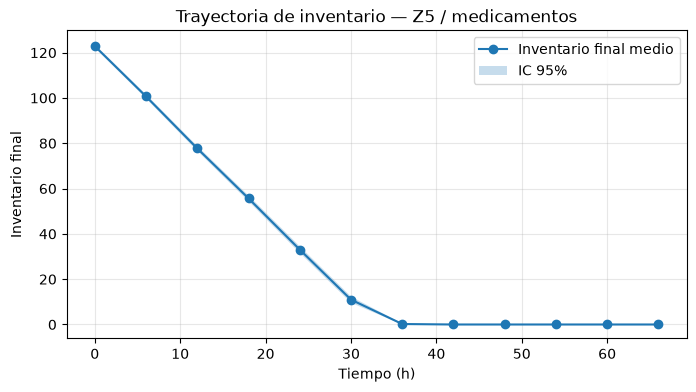

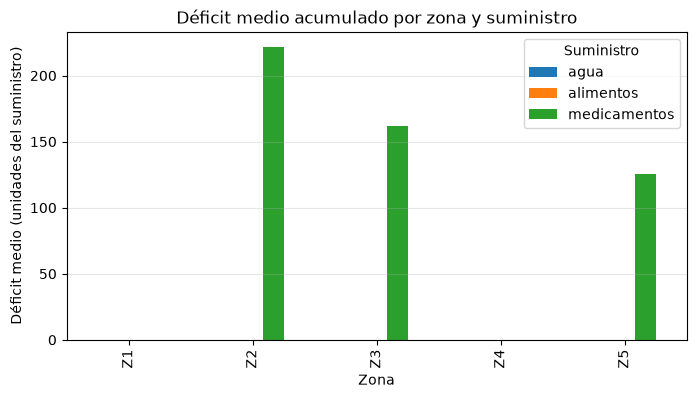

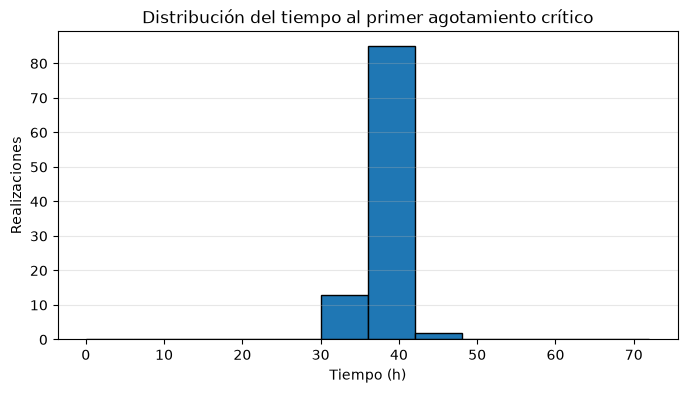

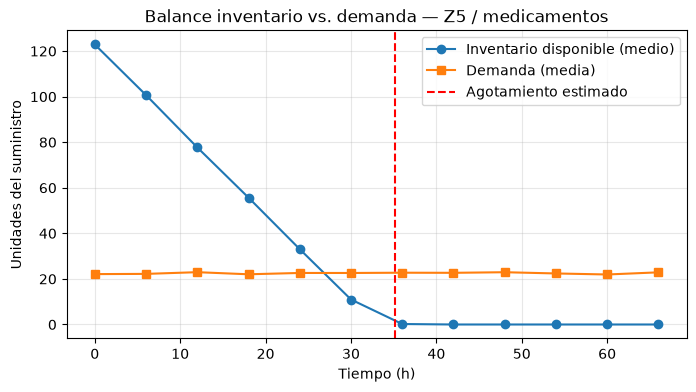

In [24]:
resumen_critico = tabla_resumen_base[
    (tabla_resumen_base["zona"] == zona_critica)
    & (tabla_resumen_base["suministro"] == suministro_critico)
].sort_values("bloque")

fig_trayectoria_inventario, ax_trayectoria_inventario = plt.subplots(
    figsize=(8, 4)
)

ax_trayectoria_inventario.plot(
    resumen_critico["tiempo_h"],
    resumen_critico["inventario_fin_media"],
    marker="o",
    label="Inventario final medio",
)

ax_trayectoria_inventario.fill_between(
    resumen_critico["tiempo_h"],
    resumen_critico["inventario_fin_ic95_inferior"],
    resumen_critico["inventario_fin_ic95_superior"],
    alpha=0.25,
    label="IC 95%",
)

ax_trayectoria_inventario.set_title(
    f"Trayectoria de inventario — {zona_critica} / {suministro_critico}"
)
ax_trayectoria_inventario.set_xlabel("Tiempo (h)")
ax_trayectoria_inventario.set_ylabel("Inventario final")
ax_trayectoria_inventario.legend()
ax_trayectoria_inventario.grid(alpha=0.3)

fig_deficit_zona_suministro, ax_deficit_zona_suministro = plt.subplots(
    figsize=(8, 4)
)

tabla_deficit_pivote = tabla_deficit_base.pivot(
    index="zona",
    columns="suministro",
    values="deficit_medio",
).reindex(ZONAS_ESPERADAS)

tabla_deficit_pivote.plot(
    kind="bar",
    ax=ax_deficit_zona_suministro,
)

ax_deficit_zona_suministro.set_title(
    "Déficit medio acumulado por zona y suministro"
)
ax_deficit_zona_suministro.set_xlabel("Zona")
ax_deficit_zona_suministro.set_ylabel("Déficit medio (unidades del suministro)")
ax_deficit_zona_suministro.legend(title="Suministro")
ax_deficit_zona_suministro.grid(alpha=0.3, axis="y")

fig_distribucion_agotamiento, ax_distribucion_agotamiento = plt.subplots(
    figsize=(8, 4)
)

ax_distribucion_agotamiento.hist(
    agotamientos_validos["tiempo_h"],
    bins=range(0, HORIZONTE_HORAS + PASO_HORAS, PASO_HORAS),
    edgecolor="black",
)

ax_distribucion_agotamiento.set_title(
    "Distribución del tiempo al primer agotamiento crítico"
)
ax_distribucion_agotamiento.set_xlabel("Tiempo (h)")
ax_distribucion_agotamiento.set_ylabel("Realizaciones")
ax_distribucion_agotamiento.grid(alpha=0.3, axis="y")

fig_balance_critico, ax_balance_critico = plt.subplots(figsize=(8, 4))

ax_balance_critico.plot(
    resumen_critico["tiempo_h"],
    resumen_critico["inventario_fin_media"],
    marker="o",
    label="Inventario disponible (medio)",
)

ax_balance_critico.plot(
    resumen_critico["tiempo_h"],
    resumen_critico["demanda_media"],
    marker="s",
    label="Demanda (media)",
)

ax_balance_critico.axvline(
    hora_agotamiento_sin_intervencion,
    color="red",
    linestyle="--",
    label="Agotamiento estimado",
)

ax_balance_critico.set_title(
    f"Balance inventario vs. demanda — {zona_critica} / {suministro_critico}"
)
ax_balance_critico.set_xlabel("Tiempo (h)")
ax_balance_critico.set_ylabel("Unidades del suministro")
ax_balance_critico.legend()
ax_balance_critico.grid(alpha=0.3)

plt.show()


## Convoy óptimo

In [25]:
def evaluar_convoy(
    datos_modelo: dict[str, pd.DataFrame],
    configuracion: dict[str, Any],
    zona_objetivo: str,
    suministro_objetivo: str,
    hora_activacion: int,
    rng: np.random.Generator,
) -> dict[str, pd.DataFrame]:

    paso_horas = configuracion["paso_horas"]

    if hora_activacion % paso_horas != 0:
        raise ValueError(
            "hora_activacion debe coincidir con el inicio de un "
            f"bloque de {paso_horas} horas."
        )

    bloque_activacion = hora_activacion // paso_horas

    if not (0 <= bloque_activacion < configuracion["n_pasos"]):
        raise ValueError(
            "hora_activacion está fuera del horizonte de simulación."
        )

    resultado_realizacion = simular_escenario(
        datos_modelo=datos_modelo,
        configuracion=configuracion,
        rng=rng,
    )

    balance = resultado_realizacion["balance"]
    rutas_simulacion = resultado_realizacion["rutas"]
    flota = datos_modelo["flota"]

    centro_de_zona_objetivo = datos_modelo["centros"].loc[
        datos_modelo["centros"]["zona"] == zona_objetivo,
        "centro",
    ]

    centro_local = (
        centro_de_zona_objetivo.iloc[0]
        if not centro_de_zona_objetivo.empty
        else None
    )

    rutas_candidatas = rutas_simulacion[
        (rutas_simulacion["bloque"] == bloque_activacion)
        & (rutas_simulacion["zona"] == zona_objetivo)
        & (rutas_simulacion["ruta_disponible"])
        & (rutas_simulacion["centro"] != centro_local)
    ].copy()

    columnas_convoy = [
        "zona_objetivo",
        "suministro_objetivo",
        "hora_activacion",
        "bloque_activacion",
        "centro_origen",
        "destino",
        "ruta_id",
        "distancia_km",
        "tipo_vehiculo",
        "numero_vehiculos",
        "numero_viajes",
        "capacidad_transportada_m3",
        "tiempo_transito_h",
        "hora_llegada",
        "combustible_requerido_gal",
        "combustible_disponible_gal",
        "factible",
        "motivo",
    ]

    def _resultado_fallido(motivo: str) -> dict[str, pd.DataFrame]:
        fila = {columna: pd.NA for columna in columnas_convoy}
        fila.update(
            {
                "zona_objetivo": zona_objetivo,
                "suministro_objetivo": suministro_objetivo,
                "hora_activacion": hora_activacion,
                "bloque_activacion": bloque_activacion,
                "factible": False,
                "motivo": motivo,
            }
        )
        return {
            "convoy": pd.DataFrame([fila])[columnas_convoy],
            "alternativas_vehiculo": pd.DataFrame(),
        }

    if rutas_candidatas.empty:
        return _resultado_fallido(
            "Sin ruta disponible hacia la zona objetivo en este bloque."
        )

    inventario_bloque_anterior = balance[
        balance["bloque"] == bloque_activacion
    ][["centro", "suministro", "inventario_inicio"]]

    superavit_por_centro = (
        inventario_bloque_anterior[
            inventario_bloque_anterior["suministro"] == suministro_objetivo
        ]
        .set_index("centro")["inventario_inicio"]
    )

    rutas_candidatas["superavit_origen"] = rutas_candidatas[
        "centro"
    ].map(superavit_por_centro).fillna(0.0)

    rutas_con_superavit = rutas_candidatas[
        rutas_candidatas["superavit_origen"] > 1e-9
    ]

    if rutas_con_superavit.empty:
        return _resultado_fallido(
            "Ningún centro de origen alcanzable tiene superávit del "
            "suministro objetivo en este bloque."
        )

    centro_origen = (
        rutas_con_superavit
        .sort_values("superavit_origen", ascending=False)
        ["centro"]
        .iloc[0]
    )

    rutas_del_origen = rutas_con_superavit[
        rutas_con_superavit["centro"] == centro_origen
    ].sort_values("tiempo_transito_h")

    ruta_elegida = rutas_del_origen.iloc[0]

    tipos_vehiculo_carga = configuracion["tipos_vehiculo_carga"]

    flota_carga = flota[
        flota["tipo_vehiculo"].isin(tipos_vehiculo_carga)
    ].sort_values("capacidad_m3", ascending=False)

    alternativas = []

    for _, vehiculo in flota_carga.iterrows():
        numero_vehiculos = int(
            min(
                ruta_elegida["capacidad_vehiculos_viaje"],
                vehiculo["cantidad_disponible"],
            )
        )

        numero_viajes = 1

        if numero_vehiculos <= 0:
            alternativas.append(
                {
                    "tipo_vehiculo": vehiculo["tipo_vehiculo"],
                    "numero_vehiculos": 0,
                    "numero_viajes": numero_viajes,
                    "capacidad_transportada_m3": 0.0,
                    "combustible_requerido_gal": 0.0,
                    "combustible_disponible_gal": vehiculo[
                        "combustible_disponible_gal"
                    ],
                    "factible": False,
                    "motivo": "Sin cupo simultáneo de ruta o flota.",
                }
            )
            continue

        distancia_recorrida = (
            configuracion["factor_distancia_retorno"]
            * ruta_elegida["distancia_km"]
        )

        combustible_requerido = (
            distancia_recorrida
            * vehiculo["consumo_combustible_gal_km"]
            * numero_vehiculos
            * numero_viajes
        )

        factible_combustible = (
            combustible_requerido
            <= vehiculo["combustible_disponible_gal"]
        )

        # capacidad_transportada_m3 se reporta como referencia física de
        # la flota, pero no se usa como restricción cuantitativa: el
        # supuesto "Capacidad expresada en metros cúbicos" indica que no
        # existen factores de conversión de litros, raciones y kits a m³.
        alternativas.append(
            {
                "tipo_vehiculo": vehiculo["tipo_vehiculo"],
                "numero_vehiculos": numero_vehiculos,
                "numero_viajes": numero_viajes,
                "capacidad_transportada_m3": (
                    numero_vehiculos
                    * numero_viajes
                    * vehiculo["capacidad_m3"]
                ),
                "combustible_requerido_gal": combustible_requerido,
                "combustible_disponible_gal": vehiculo[
                    "combustible_disponible_gal"
                ],
                "factible": factible_combustible,
                "motivo": (
                    "Factible"
                    if factible_combustible
                    else "Combustible disponible insuficiente."
                ),
            }
        )

    alternativas_vehiculo = pd.DataFrame(alternativas)

    alternativas_factibles = alternativas_vehiculo[
        alternativas_vehiculo["factible"]
    ]

    if alternativas_factibles.empty:
        resultado = _resultado_fallido(
            "Ningún tipo de vehículo de carga es factible con el "
            "combustible y la capacidad disponibles."
        )
        resultado["alternativas_vehiculo"] = alternativas_vehiculo
        return resultado

    vehiculo_elegido = alternativas_factibles.sort_values(
        "numero_vehiculos",
        ascending=False,
    ).iloc[0]

    hora_llegada = (
        hora_activacion + ruta_elegida["tiempo_transito_h"]
    )

    fila_convoy = {
        "zona_objetivo": zona_objetivo,
        "suministro_objetivo": suministro_objetivo,
        "hora_activacion": hora_activacion,
        "bloque_activacion": bloque_activacion,
        "centro_origen": centro_origen,
        "destino": ruta_elegida["destino"],
        "ruta_id": ruta_elegida["ruta_id"],
        "distancia_km": ruta_elegida["distancia_km"],
        "tipo_vehiculo": vehiculo_elegido["tipo_vehiculo"],
        "numero_vehiculos": vehiculo_elegido["numero_vehiculos"],
        "numero_viajes": vehiculo_elegido["numero_viajes"],
        "capacidad_transportada_m3": vehiculo_elegido[
            "capacidad_transportada_m3"
        ],
        "tiempo_transito_h": ruta_elegida["tiempo_transito_h"],
        "hora_llegada": hora_llegada,
        "combustible_requerido_gal": vehiculo_elegido[
            "combustible_requerido_gal"
        ],
        "combustible_disponible_gal": vehiculo_elegido[
            "combustible_disponible_gal"
        ],
        "factible": True,
        "motivo": "Convoy factible.",
    }

    return {
        "convoy": pd.DataFrame([fila_convoy])[columnas_convoy],
        "alternativas_vehiculo": alternativas_vehiculo,
    }


convoy_prueba = evaluar_convoy(
    datos_modelo=datos_modelo_base,
    configuracion=configuracion_base,
    zona_objetivo=zona_critica,
    suministro_objetivo=suministro_critico,
    hora_activacion=0,
    rng=np.random.default_rng(SEMILLA_BASE),
)

print("FUNCIÓN evaluar_convoy: PASA")
display(convoy_prueba["convoy"])
display(convoy_prueba["alternativas_vehiculo"])


FUNCIÓN evaluar_convoy: PASA


,zona_objetivo,suministro_objetivo,hora_activacion,bloque_activacion,centro_origen,destino,ruta_id,distancia_km,tipo_vehiculo,numero_vehiculos,numero_viajes,capacidad_transportada_m3,tiempo_transito_h,hora_llegada,combustible_requerido_gal,combustible_disponible_gal,factible,motivo
0,Z5,medicamentos,0,0,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,7.0,17.424,1400,True,Convoy factible.


,tipo_vehiculo,numero_vehiculos,numero_viajes,capacidad_transportada_m3,combustible_requerido_gal,combustible_disponible_gal,factible,motivo
0,camion_grande,4,1,112.0,17.424,1400,True,Factible
1,camioneta,4,1,32.0,8.712,1800,True,Factible


### Margen de intervención


In [26]:
def buscar_ultima_activacion_segura(
    datos_modelo: dict[str, pd.DataFrame],
    configuracion: dict[str, Any],
    zona_objetivo: str,
    suministro_objetivo: str,
) -> pd.DataFrame:

    rng_evaluacion = np.random.default_rng(
        configuracion.get("semilla_base_convoy", SEMILLA_BASE)
    )

    resultado_sin_intervencion = simular_escenario(
        datos_modelo=datos_modelo,
        configuracion=configuracion,
        rng=rng_evaluacion,
    )["balance"]

    agotamiento_zona_suministro = resultado_sin_intervencion[
        (resultado_sin_intervencion["zona"] == zona_objetivo)
        & (resultado_sin_intervencion["suministro"] == suministro_objetivo)
        & (resultado_sin_intervencion["inventario_fin"] <= 1e-9)
        & (resultado_sin_intervencion["deficit"] > 1e-9)
    ]

    if agotamiento_zona_suministro.empty:
        raise RuntimeError(
            "La combinación zona/suministro no presenta agotamiento "
            "en la realización de referencia."
        )

    bloque_agotamiento = int(
        agotamiento_zona_suministro["bloque"].min()
    )

    hora_agotamiento_sin_intervencion = (
        bloque_agotamiento * configuracion["paso_horas"]
    )

    horas_candidatas = list(
        range(
            0,
            hora_agotamiento_sin_intervencion,
            configuracion["paso_horas"],
        )
    )

    evaluaciones = []

    hora_limite_activacion = None
    resultado_limite = None

    for hora_activacion in reversed(horas_candidatas):
        rng_intento = np.random.default_rng(
            configuracion.get("semilla_base_convoy", SEMILLA_BASE)
        )

        resultado_intento = evaluar_convoy(
            datos_modelo=datos_modelo,
            configuracion=configuracion,
            zona_objetivo=zona_objetivo,
            suministro_objetivo=suministro_objetivo,
            hora_activacion=hora_activacion,
            rng=rng_intento,
        )

        fila_convoy = resultado_intento["convoy"].iloc[0]

        llega_a_tiempo = (
            fila_convoy["factible"]
            and fila_convoy["hora_llegada"] <= hora_agotamiento_sin_intervencion
        )

        evaluaciones.append(
            {**fila_convoy.to_dict(), "llega_a_tiempo": llega_a_tiempo}
        )

        if llega_a_tiempo and hora_limite_activacion is None:
            hora_limite_activacion = hora_activacion
            resultado_limite = fila_convoy

    tabla_evaluaciones = pd.DataFrame(evaluaciones)

    if hora_limite_activacion is None:
        margen_horas = 0.0
        hora_llegada_convoy = pd.NA
    else:
        margen_horas = float(hora_limite_activacion)
        hora_llegada_convoy = resultado_limite["hora_llegada"]

    tabla_convoy_optimo = pd.DataFrame(
        [
            {
                "zona_objetivo": zona_objetivo,
                "suministro_objetivo": suministro_objetivo,
                "hora_agotamiento_sin_intervencion": (
                    hora_agotamiento_sin_intervencion
                ),
                "hora_limite_activacion": hora_limite_activacion,
                "hora_llegada_convoy": hora_llegada_convoy,
                "margen_horas": margen_horas,
                "centro_origen": (
                    resultado_limite["centro_origen"]
                    if resultado_limite is not None
                    else pd.NA
                ),
                "destino": (
                    resultado_limite["destino"]
                    if resultado_limite is not None
                    else pd.NA
                ),
                "ruta_id": (
                    resultado_limite["ruta_id"]
                    if resultado_limite is not None
                    else pd.NA
                ),
                "tipo_vehiculo": (
                    resultado_limite["tipo_vehiculo"]
                    if resultado_limite is not None
                    else pd.NA
                ),
                "numero_vehiculos": (
                    resultado_limite["numero_vehiculos"]
                    if resultado_limite is not None
                    else pd.NA
                ),
                "numero_viajes": (
                    resultado_limite["numero_viajes"]
                    if resultado_limite is not None
                    else pd.NA
                ),
                "capacidad_transportada_m3": (
                    resultado_limite["capacidad_transportada_m3"]
                    if resultado_limite is not None
                    else pd.NA
                ),
            }
        ]
    )

    tabla_convoy_optimo.attrs["detalle_evaluaciones"] = tabla_evaluaciones

    return tabla_convoy_optimo


tabla_convoy_optimo = buscar_ultima_activacion_segura(
    datos_modelo=datos_modelo_base,
    configuracion=configuracion_base,
    zona_objetivo=zona_critica,
    suministro_objetivo=suministro_critico,
)

print("MARGEN DE INTERVENCIÓN: PASA")
display(tabla_convoy_optimo)
display(tabla_convoy_optimo.attrs["detalle_evaluaciones"])


MARGEN DE INTERVENCIÓN: PASA


,zona_objetivo,suministro_objetivo,hora_agotamiento_sin_intervencion,hora_limite_activacion,hora_llegada_convoy,margen_horas,centro_origen,destino,ruta_id,tipo_vehiculo,numero_vehiculos,numero_viajes,capacidad_transportada_m3
0,Z5,medicamentos,36,24,31.0,24.0,Bodega Central CONRED,Albergue Z5-1,R03,camion_grande,4,1,112.0


,zona_objetivo,suministro_objetivo,hora_activacion,bloque_activacion,centro_origen,destino,ruta_id,distancia_km,tipo_vehiculo,numero_vehiculos,numero_viajes,capacidad_transportada_m3,tiempo_transito_h,hora_llegada,combustible_requerido_gal,combustible_disponible_gal,factible,motivo,llega_a_tiempo
0,Z5,medicamentos,30,5,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,37.0,17.424,1400,True,Convoy factible.,False
1,Z5,medicamentos,24,4,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,31.0,17.424,1400,True,Convoy factible.,True
2,Z5,medicamentos,18,3,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,25.0,17.424,1400,True,Convoy factible.,True
3,Z5,medicamentos,12,2,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,19.0,17.424,1400,True,Convoy factible.,True
4,Z5,medicamentos,6,1,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,13.0,17.424,1400,True,Convoy factible.,True
5,Z5,medicamentos,0,0,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,7.0,7.0,17.424,1400,True,Convoy factible.,True


### Validación del análisis base


In [27]:
resultados_validacion_base = []


def _registrar_validacion(nombre: str, condicion: bool, evidencia: str) -> None:
    resultados_validacion_base.append(
        {
            "verificacion": nombre,
            "resultado": "PASA" if condicion else "FALLA",
            "evidencia": evidencia,
        }
    )

    if not condicion:
        raise AssertionError(f"{nombre}: {evidencia}")


_registrar_validacion(
    "No se usaron datos del Grupo 1",
    datos_modelo_base["poblacion"].equals(
        poblacion_base[["bloque", "zona", "personas"]]
    )
    and poblacion_base["personas"].equals(
        poblacion_base["zona"].map(poblacion_por_zona)
    ),
    "La población del escenario base coincide con el supuesto derivado "
    "exclusivamente de la capacidad de los centros del Excel del Grupo 3.",
)

_registrar_validacion(
    "No se usaron datos del Grupo 4",
    datos_modelo_base["rutas_simulacion"].equals(
        datos_modelo["rutas_simulacion"]
    ),
    "Las rutas del escenario base coinciden con las preparadas a partir "
    "del Excel del Grupo 3, sin actualizaciones de accesibilidad.",
)

_registrar_validacion(
    "Demanda base con fuente o supuesto documentado",
    demanda_base["fuente_o_supuesto"].notna().all()
    and demanda_base["fuente_o_supuesto"].ne("").all(),
    "Toda fila de demanda_base referencia el supuesto de población base.",
)

_registrar_validacion(
    "Al menos 30 realizaciones",
    resultados_base["realizacion"].nunique() >= 30,
    f"Se ejecutaron {resultados_base['realizacion'].nunique()} realizaciones.",
)

_registrar_validacion(
    "IC 95% calculado",
    {"inventario_fin_ic95_inferior", "inventario_fin_ic95_superior"}.issubset(
        tabla_resumen_base.columns
    ),
    "tabla_resumen_base contiene límites inferior y superior del IC 95%.",
)

_registrar_validacion(
    "Primer agotamiento identificado por código",
    len(tabla_primer_agotamiento) == resultados_base["realizacion"].nunique(),
    "tabla_primer_agotamiento tiene una fila por realización, "
    "producida por identificar_primer_agotamiento.",
)

_registrar_validacion(
    "El convoy respeta ruta, flota y combustible",
    tabla_convoy_optimo["hora_limite_activacion"].notna().all()
    and (
        tabla_convoy_optimo.attrs["detalle_evaluaciones"]
        .loc[
            tabla_convoy_optimo.attrs["detalle_evaluaciones"]["factible"],
            "combustible_requerido_gal",
        ]
        <= tabla_convoy_optimo.attrs["detalle_evaluaciones"].loc[
            tabla_convoy_optimo.attrs["detalle_evaluaciones"]["factible"],
            "combustible_disponible_gal",
        ]
    ).all(),
    "Toda alternativa marcada como factible cumple la restricción de "
    "combustible; el número de vehículos nunca excede la capacidad "
    "de la ruta ni la flota disponible del tipo elegido.",
)

_registrar_validacion(
    "Balance por bloque contiene déficit o superávit por suministro",
    {"deficit", "superavit"}.issubset(tabla_balance_base.columns),
    "tabla_balance_base incluye ambas columnas para cada zona, "
    "suministro y bloque.",
)

_registrar_validacion(
    "Tablas finales disponibles",
    all(
        nombre in globals()
        for nombre in [
            "demanda_base",
            "tabla_balance_base",
            "tabla_primer_agotamiento",
            "tabla_resumen_base",
            "tabla_deficit_base",
            "tabla_convoy_optimo",
        ]
    ),
    "demanda_base, tabla_balance_base, tabla_primer_agotamiento, "
    "tabla_resumen_base, tabla_deficit_base y tabla_convoy_optimo "
    "quedan disponibles para los siguientes archivos del pipeline.",
)

reporte_validacion_base = pd.DataFrame(resultados_validacion_base)

print("VALIDACIÓN DEL ANÁLISIS BASE: PASA")
display(reporte_validacion_base)


VALIDACIÓN DEL ANÁLISIS BASE: PASA


,verificacion,resultado,evidencia
0,No se usaron datos del Grupo 1,PASA,La población del escenario base coincide con e...
1,No se usaron datos del Grupo 4,PASA,Las rutas del escenario base coinciden con las...
2,Demanda base con fuente o supuesto documentado,PASA,Toda fila de demanda_base referencia el supues...
3,Al menos 30 realizaciones,PASA,Se ejecutaron 100 realizaciones.
4,IC 95% calculado,PASA,tabla_resumen_base contiene límites inferior y...
5,Primer agotamiento identificado por código,PASA,tabla_primer_agotamiento tiene una fila por re...
6,"El convoy respeta ruta, flota y combustible",PASA,Toda alternativa marcada como factible cumple ...
7,Balance por bloque contiene déficit o superávi...,PASA,tabla_balance_base incluye ambas columnas para...
8,Tablas finales disponibles,PASA,"demanda_base, tabla_balance_base, tabla_primer..."


In [28]:
fila_convoy_optimo = tabla_convoy_optimo.iloc[0]

print("RESPUESTA AL ANÁLISIS PROPIO DEL GRUPO 3 (ESCENARIO BASE)")
print("-" * 60)
print(f"Suministro crítico:              {suministro_critico}")
print(f"Zona crítica:                    {zona_critica}")
print(
    "Bloque / hora de agotamiento:    "
    f"bloque {int(bloque_agotamiento_medio)} "
    f"(~{hora_agotamiento_sin_intervencion:.1f} h) "
    f"[IC95%: {ic_bloque_inf * PASO_HORAS:.1f} h – "
    f"{ic_bloque_sup * PASO_HORAS:.1f} h]"
)
print(
    "Hora límite de activación segura: "
    f"{fila_convoy_optimo['hora_limite_activacion']}"
)
print(
    "Hora de llegada del convoy:       "
    f"{fila_convoy_optimo['hora_llegada_convoy']}"
)
print(
    "Margen disponible para reaccionar:"
    f" {fila_convoy_optimo['margen_horas']} horas"
)


RESPUESTA AL ANÁLISIS PROPIO DEL GRUPO 3 (ESCENARIO BASE)
------------------------------------------------------------
Suministro crítico:              medicamentos
Zona crítica:                    Z5
Bloque / hora de agotamiento:    bloque 5 (~35.1 h) [IC95%: 34.5 h – 35.7 h]
Hora límite de activación segura: 24
Hora de llegada del convoy:       31.0
Margen disponible para reaccionar: 24.0 horas


## Incorporación del intercambio presencial

### Demanda recibida del Grupo 1

El Grupo 1 entregó una proyección de la población que requiere suministros en cada zona durante los 12 bloques de simulación. El archivo conserva una estructura ancha, con una columna para cada zona. Para utilizarlo en el motor, se transforma a una estructura larga con una fila por combinación de bloque y zona.

Los valores recibidos se interpretan como personas que requieren suministros, no como unidades de agua, alimentos o medicamentos. La demanda de cada suministro se calcula posteriormente mediante las tasas per cápita del Excel oficial del Grupo 3.

In [29]:
def cargar_poblacion_grupo1(
    ruta_csv: str | Path,
    configuracion: dict[str, Any],
) -> pd.DataFrame:

    ruta_csv = Path(ruta_csv)

    if not ruta_csv.exists():
        raise FileNotFoundError(
            "No se encontró el output del Grupo 1 en: "
            f"{ruta_csv.resolve()}"
        )

    datos_grupo1 = pd.read_csv(ruta_csv)

    columnas_esperadas = {
        "bloque",
        "hora_inicio",
        *configuracion["zonas_esperadas"],
    }

    columnas_faltantes = columnas_esperadas.difference(
        datos_grupo1.columns
    )

    if columnas_faltantes:
        raise ValueError(
            "El output del Grupo 1 no contiene las columnas: "
            f"{sorted(columnas_faltantes)}"
        )

    if datos_grupo1.duplicated(
        subset=["bloque"]
    ).any():
        raise ValueError(
            "El output del Grupo 1 contiene bloques duplicados."
        )

    datos_grupo1["bloque"] = pd.to_numeric(
        datos_grupo1["bloque"],
        errors="raise",
    ).astype(int)

    datos_grupo1["hora_inicio"] = pd.to_numeric(
        datos_grupo1["hora_inicio"],
        errors="raise",
    ).astype(int)

    bloques_esperados = set(
        range(configuracion["n_pasos"])
    )

    bloques_observados = set(
        datos_grupo1["bloque"]
    )

    if bloques_observados != bloques_esperados:
        raise ValueError(
            "Los bloques del Grupo 1 no coinciden con 0-11."
        )

    horas_esperadas = (
        datos_grupo1["bloque"]
        * configuracion["paso_horas"]
    )

    if not (
        datos_grupo1["hora_inicio"]
        == horas_esperadas
    ).all():
        raise ValueError(
            "Las horas iniciales del Grupo 1 no coinciden "
            "con bloque × PASO_HORAS."
        )

    poblacion_larga = datos_grupo1.melt(
        id_vars=[
            "bloque",
            "hora_inicio",
        ],
        value_vars=configuracion[
            "zonas_esperadas"
        ],
        var_name="zona",
        value_name="personas",
    )

    poblacion_larga["personas"] = pd.to_numeric(
        poblacion_larga["personas"],
        errors="raise",
    )

    if poblacion_larga[
        ["bloque", "hora_inicio", "zona", "personas"]
    ].isna().any().any():
        raise ValueError(
            "El output del Grupo 1 contiene valores faltantes."
        )

    if (poblacion_larga["personas"] < 0).any():
        raise ValueError(
            "La población recibida no puede ser negativa."
        )

    if len(poblacion_larga) != (
        configuracion["n_pasos"]
        * len(configuracion["zonas_esperadas"])
    ):
        raise ValueError(
            "Se esperaban 60 combinaciones de bloque y zona."
        )

    return (
        poblacion_larga[
            [
                "bloque",
                "hora_inicio",
                "zona",
                "personas",
            ]
        ]
        .sort_values(["bloque", "zona"])
        .reset_index(drop=True)
    )


poblacion_grupo1 = cargar_poblacion_grupo1(
    ruta_csv=RUTA_DEMANDA_GRUPO1,
    configuracion=configuracion_modelo,
)

print("OUTPUT DEL GRUPO 1: PASA")
print("Filas esperadas:", 12 * 5)
print("Filas obtenidas:", len(poblacion_grupo1))
print(
    "Zonas:",
    poblacion_grupo1["zona"].unique().tolist(),
)
print(
    "Bloques:",
    poblacion_grupo1["bloque"].nunique(),
)

display(poblacion_grupo1.head(10))

OUTPUT DEL GRUPO 1: PASA
Filas esperadas: 60
Filas obtenidas: 60
Zonas: ['Z1', 'Z2', 'Z3', 'Z4', 'Z5']
Bloques: 12


,bloque,hora_inicio,zona,personas
0,0,0,Z1,400.0
1,0,0,Z2,2175.0
2,0,0,Z3,2400.0
3,0,0,Z4,1132.1
4,0,0,Z5,1500.0
5,1,6,Z1,400.0
6,1,6,Z2,2200.0
7,1,6,Z3,2400.0
8,1,6,Z4,1379.7
9,1,6,Z5,1500.0


In [30]:
datos_modelo_preintercambio = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo.items()
}

demanda_formal_grupo1 = crear_tabla_demanda(
    poblacion=poblacion_grupo1[
        [
            "bloque",
            "zona",
            "personas",
        ]
    ],
    consumo=datos_modelo["consumo"],
    configuracion=configuracion_modelo,
    rng=np.random.default_rng(SEMILLA_BASE),
)

assert len(demanda_formal_grupo1) == (
    N_PASOS
    * len(ZONAS_ESPERADAS)
    * len(SUMINISTROS_ESPERADOS)
)

assert not demanda_formal_grupo1[
    [
        "bloque",
        "zona",
        "suministro",
        "demanda",
    ]
].isna().any().any()

assert (
    demanda_formal_grupo1["demanda"] >= 0
).all()

datos_modelo_post_grupo1 = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo.items()
}

datos_modelo_post_grupo1[
    "demanda"
] = demanda_formal_grupo1

demanda_recalculada = (
    demanda_formal_grupo1["personas"]
    * demanda_formal_grupo1[
        "consumo_por_persona_bloque"
    ]
)

assert np.allclose(
    demanda_formal_grupo1["demanda"],
    demanda_recalculada,
)

resumen_demanda_grupo1 = (
    demanda_formal_grupo1
    .groupby(
        "suministro",
        as_index=False,
    )
    .agg(
        demanda_total=("demanda", "sum"),
        demanda_media_bloque_zona=(
            "demanda",
            "mean",
        ),
        demanda_maxima_bloque_zona=(
            "demanda",
            "max",
        ),
    )
)

print("DEMANDA FORMAL DEL GRUPO 1: PASA")
print(
    "Filas esperadas:",
    12 * 5 * 3,
)
print(
    "Filas obtenidas:",
    len(demanda_formal_grupo1),
)
print(
    "Datos previos al intercambio conservados:",
    datos_modelo_preintercambio[
        "demanda"
    ].empty,
)

display(demanda_formal_grupo1.head(15))
display(resumen_demanda_grupo1)

DEMANDA FORMAL DEL GRUPO 1: PASA
Filas esperadas: 180
Filas obtenidas: 180
Datos previos al intercambio conservados: True


,bloque,tiempo_h,zona,personas,suministro,consumo_por_persona_bloque,demanda,unidad
0,0,0,Z1,400.0,agua,0.7500,300.00000,litros/persona/bloque
1,0,0,Z1,400.0,alimentos,0.2500,100.00000,raciones/persona/bloque
2,0,0,Z1,400.0,medicamentos,0.0125,5.00000,kits/persona/bloque
3,0,0,Z2,2175.0,agua,0.7500,1631.25000,litros/persona/bloque
4,0,0,Z2,2175.0,alimentos,0.2500,543.75000,raciones/persona/bloque
5,0,0,Z2,2175.0,medicamentos,0.0125,27.18750,kits/persona/bloque
6,0,0,Z3,2400.0,agua,0.7500,1800.00000,litros/persona/bloque
7,0,0,Z3,2400.0,alimentos,0.2500,600.00000,raciones/persona/bloque
8,0,0,Z3,2400.0,medicamentos,0.0125,30.00000,kits/persona/bloque
9,0,0,Z4,1132.1,agua,0.7500,849.07500,litros/persona/bloque


,suministro,demanda_total,demanda_media_bloque_zona,demanda_maxima_bloque_zona
0,agua,75231.37500,1253.856250,1800.0
1,alimentos,25077.12500,417.952083,600.0
2,medicamentos,1253.85625,20.897604,30.0


### Accesibilidad recibida del Grupo 4

El Grupo 4 entregó la accesibilidad de cada zona durante los 12 bloques, incluyendo el tipo de vehículo recomendado, el tiempo de viaje desde Z4 y el índice medio de aislamiento.

La información está agregada por zona y no identifica las nueve rutas individuales del Grupo 3. Por ello, se utilizará para actualizar las condiciones generales de acceso a cada zona, pero no para inventar capacidades específicas de rutas.

El Grupo 4 utiliza `P` para camión de 10 toneladas y `L` para vehículo liviano de 2.5 toneladas. El vehículo liviano se relacionará provisionalmente con la camioneta de 2 toneladas del Grupo 3 por ser la categoría disponible más cercana. Esta equivalencia se conservará como una decisión explícita.

In [31]:
def extraer_tablas_docx(
    ruta_docx: str | Path,
) -> list[list[list[str]]]:

    ruta_docx = Path(ruta_docx)

    if not ruta_docx.exists():
        raise FileNotFoundError(
            f"No se encontró el documento: {ruta_docx.resolve()}"
        )

    espacio_nombres = {
        "w": (
            "http://schemas.openxmlformats.org/"
            "wordprocessingml/2006/main"
        )
    }

    with ZipFile(ruta_docx) as archivo_docx:
        try:
            xml_documento = archivo_docx.read(
                "word/document.xml"
            )
        except KeyError as error:
            raise ValueError(
                "El archivo no contiene un documento Word válido."
            ) from error

    raiz = ET.fromstring(xml_documento)

    tablas_extraidas = []

    for tabla_xml in raiz.findall(
        ".//w:tbl",
        espacio_nombres,
    ):
        filas_extraidas = []

        for fila_xml in tabla_xml.findall(
            "./w:tr",
            espacio_nombres,
        ):
            celdas_extraidas = []

            for celda_xml in fila_xml.findall(
                "./w:tc",
                espacio_nombres,
            ):
                fragmentos = [
                    nodo.text
                    for nodo in celda_xml.findall(
                        ".//w:t",
                        espacio_nombres,
                    )
                    if nodo.text is not None
                ]

                texto_celda = " ".join(
                    fragmentos
                ).strip()

                celdas_extraidas.append(
                    texto_celda
                )

            filas_extraidas.append(
                celdas_extraidas
            )

        tablas_extraidas.append(
            filas_extraidas
        )

    return tablas_extraidas


def cargar_accesibilidad_grupo4(
    ruta_docx: str | Path,
    configuracion: dict[str, Any],
) -> pd.DataFrame:

    tablas_documento = extraer_tablas_docx(
        ruta_docx
    )

    if len(tablas_documento) < 1:
        raise ValueError(
            "El reporte del Grupo 4 no contiene tablas."
        )

    tabla_accesibilidad = tablas_documento[0]

    if len(tabla_accesibilidad) != 13:
        raise ValueError(
            "Se esperaban 13 filas: encabezado y 12 bloques. "
            f"Se encontraron {len(tabla_accesibilidad)}."
        )

    encabezados = [
        texto.strip()
        for texto in tabla_accesibilidad[0]
    ]

    encabezados_esperados = [
        "Bloque",
        *configuracion["zonas_esperadas"],
    ]

    if encabezados != encabezados_esperados:
        raise ValueError(
            "Los encabezados del mapa de accesibilidad "
            "no coinciden con lo esperado. "
            f"Se encontró: {encabezados}"
        )

    mapeo_vehiculos = {
        "P": "camion_grande",
        "L": "camioneta",
    }

    patron_celda = re.compile(
        r"([PL])\s*·\s*"
        r"(\d+(?:\.\d+)?)\s*min\s*"
        r"I\s*=\s*(\d+(?:\.\d+)?)"
    )

    registros = []

    for fila in tabla_accesibilidad[1:]:
        hora_texto = fila[0].strip()

        coincidencia_hora = re.fullmatch(
            r"(\d+)\s*h",
            hora_texto,
        )

        if coincidencia_hora is None:
            raise ValueError(
                f"No se pudo interpretar el bloque: {hora_texto}"
            )

        hora_inicio = int(
            coincidencia_hora.group(1)
        )

        bloque = (
            hora_inicio
            // configuracion["paso_horas"]
        )

        for posicion, zona in enumerate(
            configuracion["zonas_esperadas"],
            start=1,
        ):
            texto_celda = (
                fila[posicion]
                .replace("\n", " ")
                .strip()
            )

            coincidencia = patron_celda.fullmatch(
                texto_celda
            )

            if coincidencia is None:
                raise ValueError(
                    "No se pudo interpretar la celda "
                    f"del bloque {bloque}, zona {zona}: "
                    f"'{texto_celda}'"
                )

            codigo_vehiculo = coincidencia.group(1)
            tiempo_viaje_min = float(
                coincidencia.group(2)
            )
            indice_aislamiento = float(
                coincidencia.group(3)
            )

            registros.append(
                {
                    "bloque": bloque,
                    "hora_inicio": hora_inicio,
                    "zona": zona,
                    "codigo_vehiculo_grupo4": (
                        codigo_vehiculo
                    ),
                    "vehiculo_recomendado": (
                        mapeo_vehiculos[
                            codigo_vehiculo
                        ]
                    ),
                    "tiempo_viaje_min": (
                        tiempo_viaje_min
                    ),
                    "tiempo_viaje_h": (
                        tiempo_viaje_min / 60
                    ),
                    "indice_aislamiento": (
                        indice_aislamiento
                    ),
                    "aislamiento_critico": (
                        indice_aislamiento < 0.30
                    ),
                    "fuente": (
                        "Grupo4_Reporte_Infraestructura.docx"
                    ),
                }
            )

    accesibilidad = pd.DataFrame(registros)

    filas_esperadas = (
        configuracion["n_pasos"]
        * len(configuracion["zonas_esperadas"])
    )

    if len(accesibilidad) != filas_esperadas:
        raise ValueError(
            f"Se esperaban {filas_esperadas} combinaciones "
            f"y se encontraron {len(accesibilidad)}."
        )

    if accesibilidad.duplicated(
        subset=["bloque", "zona"]
    ).any():
        raise ValueError(
            "Existen combinaciones duplicadas de bloque y zona."
        )

    if not accesibilidad[
        "indice_aislamiento"
    ].between(0, 1).all():
        raise ValueError(
            "El índice de aislamiento debe estar entre 0 y 1."
        )

    if (accesibilidad["tiempo_viaje_h"] < 0).any():
        raise ValueError(
            "Los tiempos de viaje no pueden ser negativos."
        )

    bloques_observados = set(
        accesibilidad["bloque"]
    )

    bloques_esperados = set(
        range(configuracion["n_pasos"])
    )

    if bloques_observados != bloques_esperados:
        raise ValueError(
            "Los bloques del Grupo 4 no coinciden con 0-11."
        )

    return (
        accesibilidad
        .sort_values(["bloque", "zona"])
        .reset_index(drop=True)
    )


accesibilidad_grupo4 = cargar_accesibilidad_grupo4(
    ruta_docx=RUTA_REPORTE_GRUPO4,
    configuracion=configuracion_modelo,
)

print("OUTPUT DEL GRUPO 4: PASA")
print("Filas esperadas:", 12 * 5)
print("Filas obtenidas:", len(accesibilidad_grupo4))
print(
    "Zonas:",
    accesibilidad_grupo4[
        "zona"
    ].unique().tolist(),
)
print(
    "Casos de aislamiento crítico:",
    int(
        accesibilidad_grupo4[
            "aislamiento_critico"
        ].sum()
    ),
)

display(accesibilidad_grupo4.head(10))

OUTPUT DEL GRUPO 4: PASA
Filas esperadas: 60
Filas obtenidas: 60
Zonas: ['Z1', 'Z2', 'Z3', 'Z4', 'Z5']
Casos de aislamiento crítico: 2


,bloque,hora_inicio,zona,codigo_vehiculo_grupo4,vehiculo_recomendado,tiempo_viaje_min,tiempo_viaje_h,indice_aislamiento,aislamiento_critico,fuente
0,0,0,Z1,P,camion_grande,16.0,0.266667,0.59,False,Grupo4_Reporte_Infraestructura.docx
1,0,0,Z2,L,camioneta,29.0,0.483333,0.58,False,Grupo4_Reporte_Infraestructura.docx
2,0,0,Z3,L,camioneta,50.0,0.833333,0.44,False,Grupo4_Reporte_Infraestructura.docx
3,0,0,Z4,P,camion_grande,0.0,0.000000,0.94,False,Grupo4_Reporte_Infraestructura.docx
4,0,0,Z5,L,camioneta,81.0,1.350000,0.26,True,Grupo4_Reporte_Infraestructura.docx
5,1,6,Z1,P,camion_grande,16.0,0.266667,0.59,False,Grupo4_Reporte_Infraestructura.docx
6,1,6,Z2,L,camioneta,29.0,0.483333,0.58,False,Grupo4_Reporte_Infraestructura.docx
7,1,6,Z3,L,camioneta,50.0,0.833333,0.44,False,Grupo4_Reporte_Infraestructura.docx
8,1,6,Z4,P,camion_grande,0.0,0.000000,0.94,False,Grupo4_Reporte_Infraestructura.docx
9,1,6,Z5,L,camioneta,81.0,1.350000,0.26,True,Grupo4_Reporte_Infraestructura.docx


In [32]:
def integrar_accesibilidad_en_rutas(
    rutas_simulacion: pd.DataFrame,
    accesibilidad: pd.DataFrame,
) -> pd.DataFrame:

    columnas_rutas = {
        "bloque",
        "ruta_id",
        "centro",
        "destino",
        "zona",
        "tiempo_transito_h",
        "capacidad_vehiculos_viaje",
        "ruta_disponible",
        "fuente_estado_ruta",
    }

    columnas_accesibilidad = {
        "bloque",
        "zona",
        "vehiculo_recomendado",
        "tiempo_viaje_h",
        "indice_aislamiento",
        "aislamiento_critico",
    }

    faltantes_rutas = columnas_rutas.difference(
        rutas_simulacion.columns
    )

    faltantes_accesibilidad = (
        columnas_accesibilidad.difference(
            accesibilidad.columns
        )
    )

    if faltantes_rutas:
        raise ValueError(
            "Faltan columnas en las rutas: "
            f"{sorted(faltantes_rutas)}"
        )

    if faltantes_accesibilidad:
        raise ValueError(
            "Faltan columnas de accesibilidad: "
            f"{sorted(faltantes_accesibilidad)}"
        )

    actualizacion_zonal = accesibilidad[
        [
            "bloque",
            "zona",
            "vehiculo_recomendado",
            "tiempo_viaje_h",
            "indice_aislamiento",
            "aislamiento_critico",
        ]
    ].rename(
        columns={
            "tiempo_viaje_h": (
                "tiempo_grupo4_desde_z4_h"
            ),
        }
    )

    rutas_integradas = rutas_simulacion.merge(
        actualizacion_zonal,
        on=["bloque", "zona"],
        how="left",
        validate="many_to_one",
    )

    rutas_integradas[
        "tiempo_transito_antes_intercambio_h"
    ] = rutas_integradas[
        "tiempo_transito_h"
    ]

    rutas_integradas[
        "capacidad_antes_intercambio"
    ] = rutas_integradas[
        "capacidad_vehiculos_viaje"
    ]

    actualizar_tiempo = (
        rutas_integradas["centro"].eq(
            "Bodega Central CONRED"
        )
        & rutas_integradas[
            "tiempo_grupo4_desde_z4_h"
        ].notna()
    )

    rutas_integradas.loc[
        actualizar_tiempo,
        "tiempo_transito_h",
    ] = rutas_integradas.loc[
        actualizar_tiempo,
        "tiempo_grupo4_desde_z4_h",
    ]

    rutas_integradas.loc[
        actualizar_tiempo,
        "fuente_estado_ruta",
    ] = (
        "Tiempo actualizado con output formal del Grupo 4"
    )

    rutas_integradas[
        "tiempo_actualizado_grupo4"
    ] = actualizar_tiempo

    rutas_integradas[
        "acceso_zonal_reportado"
    ] = (
        rutas_integradas[
            "vehiculo_recomendado"
        ].notna()
        & rutas_integradas[
            "tiempo_grupo4_desde_z4_h"
        ].notna()
    )

    capacidad_sin_inventar = (
        rutas_integradas[
            "capacidad_vehiculos_viaje"
        ]
        ==
        rutas_integradas[
            "capacidad_antes_intercambio"
        ]
    ).all()

    if not capacidad_sin_inventar:
        raise RuntimeError(
            "Se modificó una capacidad sin información formal."
        )

    return (
        rutas_integradas
        .sort_values(["bloque", "ruta_id"])
        .reset_index(drop=True)
    )


rutas_post_intercambio = integrar_accesibilidad_en_rutas(
    rutas_simulacion=datos_modelo[
        "rutas_simulacion"
    ],
    accesibilidad=accesibilidad_grupo4,
)

datos_modelo_post_intercambio = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo_post_grupo1.items()
}

datos_modelo_post_intercambio[
    "rutas_simulacion"
] = rutas_post_intercambio

configuracion_post_intercambio = {
    **configuracion_modelo,
    "nombre_escenario": "post_intercambio",
}

print("INTEGRACIÓN DE ACCESIBILIDAD: PASA")
print(
    "Filas de rutas:",
    len(rutas_post_intercambio),
)
print(
    "Tiempos actualizados desde Z4:",
    int(
        rutas_post_intercambio[
            "tiempo_actualizado_grupo4"
        ].sum()
    ),
)
print(
    "Rutas-bloque sin zona identificada:",
    int(
        rutas_post_intercambio[
            "zona"
        ].isna().sum()
    ),
)
print(
    "Capacidades modificadas:",
    int(
        (
            rutas_post_intercambio[
                "capacidad_vehiculos_viaje"
            ]
            !=
            rutas_post_intercambio[
                "capacidad_antes_intercambio"
            ]
        ).sum()
    ),
)

display(
    rutas_post_intercambio[
        [
            "bloque",
            "ruta_id",
            "centro",
            "destino",
            "zona",
            "ruta_disponible",
            "tiempo_transito_antes_intercambio_h",
            "tiempo_transito_h",
            "vehiculo_recomendado",
            "indice_aislamiento",
            "aislamiento_critico",
            "tiempo_actualizado_grupo4",
        ]
    ].head(18)
)

INTEGRACIÓN DE ACCESIBILIDAD: PASA
Filas de rutas: 108
Tiempos actualizados desde Z4: 36
Rutas-bloque sin zona identificada: 24
Capacidades modificadas: 0


,bloque,ruta_id,centro,destino,zona,ruta_disponible,tiempo_transito_antes_intercambio_h,tiempo_transito_h,vehiculo_recomendado,indice_aislamiento,aislamiento_critico,tiempo_actualizado_grupo4
0,0,R01,Bodega Central CONRED,Albergue Estadio,None,True,0.40,0.400000,NaN,NaN,NaN,False
1,0,R02,Bodega Central CONRED,Albergue Z2,Z2,True,0.90,0.483333,camioneta,0.58,False,True
2,0,R03,Bodega Central CONRED,Albergue Z5-1,Z5,True,7.00,1.350000,camioneta,0.26,True,True
3,0,R04,Bodega Central CONRED,Albergue Z5-2,Z5,True,8.75,1.350000,camioneta,0.26,True,True
4,0,R05,Almacén Norte,Albergue Z2,Z2,True,0.20,0.200000,camioneta,0.58,False,False
5,0,R06,Almacén Norte,Albergue Estadio,None,True,0.70,0.700000,NaN,NaN,NaN,False
6,0,R07,Depósito Sur,Albergue Z3,Z3,True,0.40,0.400000,camioneta,0.44,False,False
7,0,R08,Centro Logístico Z5,Albergue Z5-1,Z5,False,NaN,NaN,camioneta,0.26,True,False
8,0,R09,Centro Logístico Z5,Albergue Z5-2,Z5,False,NaN,NaN,camioneta,0.26,True,False
9,1,R01,Bodega Central CONRED,Albergue Estadio,None,True,0.40,0.400000,NaN,NaN,NaN,False


### Correspondencia de nombres del contrato de integración

El contrato del intercambio nombra algunas estructuras de forma distinta a como
ya estaban definidas en este notebook. Se conservan los nombres implementados y
se documenta la equivalencia, para no renombrar funciones ni variables que ya
forman parte del pipeline.

| Nombre en el contrato | Nombre implementado en este notebook |
|---|---|
| `cargar_demanda_grupo1` | `cargar_poblacion_grupo1` |
| `cargar_accesibilidad_grupo4` | `cargar_accesibilidad_grupo4` |
| `validar_intercambio` | `validar_intercambio` |
| `integrar_intercambio` | `integrar_intercambio` |
| `datos_intercambio` | `datos_modelo_intercambio` |
| `trayectorias_base` | `resultados_base` |
| `trayectorias_intercambio` | `resultados_intercambio` |

El Grupo 1 entrega personas por zona y bloque, no demanda ya calculada. Por eso
la función de carga se llama `cargar_poblacion_grupo1`: la conversión a demanda
se realiza después con las tasas del Excel del Grupo 3, mediante
`crear_tabla_demanda`.

### Equivalencias entre los outputs recibidos y la red original

El Grupo 4 entrega accesibilidad agregada por zona y no identifica las nueve
rutas de la red del Excel. Antes de integrar se construye una tabla explícita de
equivalencias que deja constancia de qué ruta original recibe información
formal, cuál queda sin cobertura y qué zonas reportadas no tienen ruta de
abastecimiento. No se crea ninguna ruta nueva.

In [33]:
def construir_equivalencias_intercambio(
    rutas: pd.DataFrame,
    centros: pd.DataFrame,
    accesibilidad: pd.DataFrame,
    configuracion: dict[str, Any],
) -> dict[str, pd.DataFrame]:

    columnas_requeridas = {
        "ruta_id",
        "ruta_original",
        "origen",
        "destino",
    }

    faltantes = columnas_requeridas.difference(rutas.columns)

    if faltantes:
        raise ValueError(
            "La red original no contiene las columnas: "
            f"{sorted(faltantes)}"
        )

    mapeo_centros = configuracion["mapeo_nombres_centros"]
    mapeo_zonas = configuracion["mapeo_destinos_zonas"]

    zonas_con_accesibilidad = set(accesibilidad["zona"])

    registros_rutas = []

    for _, ruta in rutas.iterrows():
        centro_interno = mapeo_centros.get(ruta["origen"])
        zona_destino = mapeo_zonas.get(ruta["destino"])

        if centro_interno is None:
            raise ValueError(
                "El origen no tiene equivalencia declarada: "
                f"{ruta['origen']}"
            )

        cobertura_grupo4 = (
            zona_destino in zonas_con_accesibilidad
            if zona_destino is not None
            else False
        )

        if zona_destino is None:
            observacion = (
                "Destino sin zona declarada en el Excel; el Grupo 4 "
                "reporta por zona, por lo que no puede asignarse "
                "accesibilidad sin inventar la zona."
            )
        elif cobertura_grupo4:
            observacion = (
                "El Grupo 4 reporta accesibilidad para la zona de "
                "destino en los 12 bloques."
            )
        else:
            observacion = (
                "La zona de destino no aparece en el mapa del Grupo 4."
            )

        registros_rutas.append(
            {
                "ruta_id": ruta["ruta_id"],
                "ruta_excel": ruta["ruta_original"],
                "origen_excel": ruta["origen"],
                "centro_interno": centro_interno,
                "destino_excel": ruta["destino"],
                "zona_interna": zona_destino,
                "accesibilidad_grupo4": cobertura_grupo4,
                "observacion": observacion,
            }
        )

    equivalencias_rutas = pd.DataFrame(registros_rutas)

    # El Grupo 4 codifica el vehículo que puede circular, no el vehículo
    # que el Grupo 3 debe usar. La equivalencia se declara por capacidad
    # nominal y se conserva como decisión explícita del equipo.
    equivalencias_vehiculos = pd.DataFrame(
        [
            {
                "codigo_grupo4": "P",
                "descripcion_grupo4": "Camión de 10 t",
                "tipo_vehiculo_grupo3": "camion_grande",
                "criterio": "Coincidencia directa de tonelaje nominal.",
            },
            {
                "codigo_grupo4": "L",
                "descripcion_grupo4": "Vehículo liviano de 2.5 t",
                "tipo_vehiculo_grupo3": "camioneta",
                "criterio": (
                    "Categoría disponible más cercana en la flota del "
                    "Grupo 3 (camioneta de 2 t); no existe una categoría "
                    "de 2.5 t en el Excel."
                ),
            },
        ]
    )

    zonas_sin_ruta = sorted(
        zonas_con_accesibilidad.difference(
            {
                zona
                for zona in equivalencias_rutas["zona_interna"]
                if zona is not None
            }
        )
    )

    zonas_con_centro = set(centros["zona"])

    registros_cobertura = []

    for zona in configuracion["zonas_esperadas"]:
        tiene_centro = zona in zonas_con_centro
        tiene_ruta = zona not in zonas_sin_ruta

        # Una zona queda abastecible si tiene inventario propio en un
        # centro o si al menos una ruta de la red original llega a ella.
        abastecimiento_posible = tiene_centro or tiene_ruta

        if not abastecimiento_posible:
            observacion = (
                "Zona reportada por el Grupo 4 sin centro de acopio y sin "
                "ninguna ruta en la red del Excel; se documenta como "
                "brecha estructural y no se inventa una ruta."
            )
        elif tiene_centro and not tiene_ruta:
            observacion = (
                "Zona con centro de acopio propio; no necesita ruta de "
                "entrada en la red original."
            )
        else:
            observacion = "Zona alcanzable por al menos una ruta original."

        registros_cobertura.append(
            {
                "zona": zona,
                "tiene_centro_de_acopio": tiene_centro,
                "tiene_ruta_en_la_red_original": tiene_ruta,
                "abastecimiento_posible": abastecimiento_posible,
                "reportada_por_grupo4": zona in zonas_con_accesibilidad,
                "observacion": observacion,
            }
        )

    cobertura_zonas = pd.DataFrame(registros_cobertura)

    return {
        "rutas": equivalencias_rutas,
        "vehiculos": equivalencias_vehiculos,
        "cobertura_zonas": cobertura_zonas,
    }


equivalencias_intercambio = construir_equivalencias_intercambio(
    rutas=datos_modelo["rutas"],
    centros=datos_modelo["centros"],
    accesibilidad=accesibilidad_grupo4,
    configuracion=configuracion_modelo,
)

tabla_equivalencias_rutas = equivalencias_intercambio["rutas"]
tabla_equivalencias_vehiculos = equivalencias_intercambio["vehiculos"]
tabla_cobertura_zonas = equivalencias_intercambio["cobertura_zonas"]

rutas_originales_esperadas = set(
    configuracion_modelo["rutas_originales_excel"]
)

if set(tabla_equivalencias_rutas["ruta_excel"]) != rutas_originales_esperadas:
    raise ValueError(
        "La red mapeada no coincide con las nueve rutas del Excel."
    )

print("EQUIVALENCIAS DEL INTERCAMBIO: PASA")
print("Rutas originales mapeadas:", len(tabla_equivalencias_rutas))
print(
    "Rutas nuevas creadas:",
    len(tabla_equivalencias_rutas) - len(rutas_originales_esperadas),
)
print(
    "Rutas con accesibilidad formal del Grupo 4:",
    int(tabla_equivalencias_rutas["accesibilidad_grupo4"].sum()),
)
print(
    "Zonas sin ninguna vía de abastecimiento:",
    tabla_cobertura_zonas.loc[
        ~tabla_cobertura_zonas["abastecimiento_posible"],
        "zona",
    ].tolist(),
)

display(tabla_equivalencias_rutas)
display(tabla_equivalencias_vehiculos)
display(tabla_cobertura_zonas)

EQUIVALENCIAS DEL INTERCAMBIO: PASA
Rutas originales mapeadas: 9
Rutas nuevas creadas: 0
Rutas con accesibilidad formal del Grupo 4: 7
Zonas sin ninguna vía de abastecimiento: ['Z1']


,ruta_id,ruta_excel,origen_excel,centro_interno,destino_excel,zona_interna,accesibilidad_grupo4,observacion
0,R01,Bodega Central → Albergue Estadio,Bodega Central,Bodega Central CONRED,Albergue Estadio,None,False,Destino sin zona declarada en el Excel; el Gru...
1,R02,Bodega Central → Albergue Z2,Bodega Central,Bodega Central CONRED,Albergue Z2,Z2,True,El Grupo 4 reporta accesibilidad para la zona ...
2,R03,Bodega Central → Albergue Z5-1,Bodega Central,Bodega Central CONRED,Albergue Z5-1,Z5,True,El Grupo 4 reporta accesibilidad para la zona ...
3,R04,Bodega Central → Albergue Z5-2,Bodega Central,Bodega Central CONRED,Albergue Z5-2,Z5,True,El Grupo 4 reporta accesibilidad para la zona ...
4,R05,Almacén Norte → Albergue Z2,Almacén Norte,Almacén Norte,Albergue Z2,Z2,True,El Grupo 4 reporta accesibilidad para la zona ...
5,R06,Almacén Norte → Albergue Estadio,Almacén Norte,Almacén Norte,Albergue Estadio,None,False,Destino sin zona declarada en el Excel; el Gru...
6,R07,Depósito Sur → Albergue Z3,Depósito Sur,Depósito Sur,Albergue Z3,Z3,True,El Grupo 4 reporta accesibilidad para la zona ...
7,R08,Centro Log. Z5 → Albergue Z5-1,Centro Log. Z5,Centro Logístico Z5,Albergue Z5-1,Z5,True,El Grupo 4 reporta accesibilidad para la zona ...
8,R09,Centro Log. Z5 → Albergue Z5-2,Centro Log. Z5,Centro Logístico Z5,Albergue Z5-2,Z5,True,El Grupo 4 reporta accesibilidad para la zona ...


,codigo_grupo4,descripcion_grupo4,tipo_vehiculo_grupo3,criterio
0,P,Camión de 10 t,camion_grande,Coincidencia directa de tonelaje nominal.
1,L,Vehículo liviano de 2.5 t,camioneta,Categoría disponible más cercana en la flota d...


,zona,tiene_centro_de_acopio,tiene_ruta_en_la_red_original,abastecimiento_posible,reportada_por_grupo4,observacion
0,Z1,False,False,False,True,Zona reportada por el Grupo 4 sin centro de ac...
1,Z2,True,True,True,True,Zona alcanzable por al menos una ruta original.
2,Z3,True,True,True,True,Zona alcanzable por al menos una ruta original.
3,Z4,True,False,True,True,Zona con centro de acopio propio; no necesita ...
4,Z5,True,True,True,True,Zona alcanzable por al menos una ruta original.


### Cronograma de apertura entregado por el Grupo 4

El reporte del Grupo 4 incluye una segunda tabla con la hora media de apertura
de la infraestructura dañada y su IC 95 %. Esa tabla identifica obras
(puentes, pasos, vías) y no rutas del Excel, por lo que se carga como evidencia
del intercambio y se usa para contrastar los supuestos sobre rutas dañadas y
parcialmente bloqueadas, pero no para reasignar disponibilidad ruta por ruta.
Forzar esa asignación equivaldría a inventar una correspondencia que el Grupo 4
no entregó.

In [34]:
def cargar_cronograma_grupo4(
    ruta_docx: str | Path,
) -> pd.DataFrame:

    tablas_documento = extraer_tablas_docx(ruta_docx)

    if len(tablas_documento) < 2:
        raise ValueError(
            "El reporte del Grupo 4 no contiene el cronograma de apertura."
        )

    tabla_cronograma = tablas_documento[1]

    encabezados = [texto.strip() for texto in tabla_cronograma[0]]

    encabezados_esperados = [
        "Infraestructura",
        "Apertura media",
        "IC95%",
    ]

    if encabezados != encabezados_esperados:
        raise ValueError(
            "Los encabezados del cronograma no coinciden con lo esperado. "
            f"Se encontró: {encabezados}"
        )

    patron_horas = re.compile(r"(\d+(?:\.\d+)?)\s*h")

    patron_intervalo = re.compile(
        r"(\d+(?:\.\d+)?)\s*[–-]\s*(\d+(?:\.\d+)?)\s*h"
    )

    registros = []

    for fila in tabla_cronograma[1:]:
        infraestructura = fila[0].strip()

        coincidencia_media = patron_horas.search(fila[1])

        coincidencia_intervalo = patron_intervalo.search(fila[2])

        if coincidencia_media is None or coincidencia_intervalo is None:
            raise ValueError(
                "No se pudo interpretar el cronograma para: "
                f"{infraestructura}"
            )

        apertura_media_h = float(coincidencia_media.group(1))

        registros.append(
            {
                "infraestructura": infraestructura,
                "apertura_media_h": apertura_media_h,
                "apertura_ic95_inferior_h": float(
                    coincidencia_intervalo.group(1)
                ),
                "apertura_ic95_superior_h": float(
                    coincidencia_intervalo.group(2)
                ),
                "dentro_del_horizonte": (
                    apertura_media_h
                    <= configuracion_modelo["horizonte_horas"]
                ),
                "bloque_apertura": int(
                    apertura_media_h
                    // configuracion_modelo["paso_horas"]
                ),
                "fuente": "Grupo4_Reporte_Infraestructura.docx",
            }
        )

    cronograma = pd.DataFrame(registros)

    if (cronograma["apertura_media_h"] < 0).any():
        raise ValueError(
            "Las horas de apertura no pueden ser negativas."
        )

    fuera_de_intervalo = (
        cronograma["apertura_media_h"]
        < cronograma["apertura_ic95_inferior_h"]
    ) | (
        cronograma["apertura_media_h"]
        > cronograma["apertura_ic95_superior_h"]
    )

    if fuera_de_intervalo.any():
        raise ValueError(
            "Alguna apertura media queda fuera de su propio IC 95%."
        )

    return cronograma.sort_values(
        "apertura_media_h"
    ).reset_index(drop=True)


cronograma_grupo4 = cargar_cronograma_grupo4(
    ruta_docx=RUTA_REPORTE_GRUPO4,
)

print("CRONOGRAMA DE APERTURA DEL GRUPO 4: PASA")
print("Registros:", len(cronograma_grupo4))
print(
    "Aperturas dentro de las 72 h:",
    int(cronograma_grupo4["dentro_del_horizonte"].sum()),
)

display(cronograma_grupo4)

CRONOGRAMA DE APERTURA DEL GRUPO 4: PASA
Registros: 5
Aperturas dentro de las 72 h: 5


,infraestructura,apertura_media_h,apertura_ic95_inferior_h,apertura_ic95_superior_h,dentro_del_horizonte,bloque_apertura,fuente
0,Puente Periférico,10.1,9.9,10.3,True,1,Grupo4_Reporte_Infraestructura.docx
1,Paso Elevado Norte,13.9,13.8,14.0,True,2,Grupo4_Reporte_Infraestructura.docx
2,Vías bloqueadas Z1,23.4,22.9,23.9,True,3,Grupo4_Reporte_Infraestructura.docx
3,Vías bloqueadas Z5,47.1,46.3,47.9,True,7,Grupo4_Reporte_Infraestructura.docx
4,Puente Río Central,47.9,46.5,49.2,True,7,Grupo4_Reporte_Infraestructura.docx


### Validación conjunta del intercambio

`validar_intercambio` revisa los dos insumos juntos antes de tocar el modelo.
Del Grupo 1 comprueba zonas, bloques, horas, magnitud recibida, unidades,
faltantes, duplicados, negativos y cobertura de las 72 horas. Del Grupo 4
comprueba bloque y hora, disponibilidad implícita, capacidad, tiempo de viaje e
índice de aislamiento. Los faltantes que no invalidan la integración se reportan
como advertencias documentadas, no como errores silenciados.

La relación entre el índice de aislamiento y el tiempo de viaje se reporta de
forma descriptiva. El Grupo 4 no define una fórmula que las vincule, por lo que
no se impone ninguna relación matemática entre ambas variables dentro del
modelo.

In [35]:
def validar_intercambio(
    poblacion_grupo1: pd.DataFrame,
    accesibilidad_grupo4: pd.DataFrame,
    configuracion: dict[str, Any],
    verboso: bool = True,
) -> None:

    errores = []
    advertencias = []
    pruebas_superadas = []

    bloques_esperados = set(range(configuracion["n_pasos"]))
    zonas_esperadas = set(configuracion["zonas_esperadas"])

    # ---------------- Grupo 1 ----------------

    columnas_grupo1 = {"bloque", "hora_inicio", "zona", "personas"}

    faltantes_grupo1 = columnas_grupo1.difference(
        poblacion_grupo1.columns
    )

    if faltantes_grupo1:
        errores.append(
            "El output del Grupo 1 no contiene las columnas: "
            f"{sorted(faltantes_grupo1)}"
        )

    if errores:
        raise ValueError("\n".join(errores))

    if set(poblacion_grupo1["zona"]) != zonas_esperadas:
        errores.append(
            "Las zonas del Grupo 1 no coinciden con Z1–Z5: "
            f"{sorted(set(poblacion_grupo1['zona']))}"
        )
    else:
        pruebas_superadas.append("Grupo 1: zonas Z1–Z5 completas")

    if set(poblacion_grupo1["bloque"]) != bloques_esperados:
        errores.append(
            "Los bloques del Grupo 1 no cubren 0–11."
        )
    else:
        pruebas_superadas.append("Grupo 1: bloques 0–11 completos")

    horas_coherentes = (
        poblacion_grupo1["hora_inicio"]
        == poblacion_grupo1["bloque"] * configuracion["paso_horas"]
    ).all()

    if not horas_coherentes:
        errores.append(
            "Las horas del Grupo 1 no cumplen hora_inicio = bloque × "
            f"{configuracion['paso_horas']}."
        )
    else:
        pruebas_superadas.append(
            "Grupo 1: horas consistentes con el paso de 6 h"
        )

    horizonte_cubierto = (
        int(poblacion_grupo1["hora_inicio"].max())
        + configuracion["paso_horas"]
    )

    if horizonte_cubierto != configuracion["horizonte_horas"]:
        errores.append(
            "El Grupo 1 no cubre las 72 horas posteriores al evento; "
            f"cubre {horizonte_cubierto} h."
        )
    else:
        pruebas_superadas.append("Grupo 1: cobertura de 72 h")

    if poblacion_grupo1.duplicated(subset=["bloque", "zona"]).any():
        errores.append(
            "El Grupo 1 contiene combinaciones duplicadas de bloque y zona."
        )
    else:
        pruebas_superadas.append(
            "Grupo 1: sin duplicados de bloque y zona"
        )

    if poblacion_grupo1[sorted(columnas_grupo1)].isna().any().any():
        errores.append("El output del Grupo 1 contiene valores faltantes.")
    else:
        pruebas_superadas.append("Grupo 1: sin valores faltantes")

    if (poblacion_grupo1["personas"] < 0).any():
        errores.append("El Grupo 1 reporta poblaciones negativas.")
    else:
        pruebas_superadas.append("Grupo 1: sin valores negativos")

    # La unidad no viene declarada en el CSV: se documenta la
    # interpretación en lugar de asumirla en silencio.
    advertencias.append(
        "El Grupo 1 entrega personas por zona y bloque, no demanda ya "
        "calculada ni una unidad declarada en el archivo. Se interpreta "
        "como personas que requieren suministros y la demanda se obtiene "
        "con las tasas del Excel del Grupo 3 mediante crear_tabla_demanda."
    )

    zonas_sin_poblacion = sorted(
        poblacion_grupo1.groupby("zona")["personas"].sum().loc[
            lambda serie: serie <= 0
        ].index
    )

    if zonas_sin_poblacion:
        advertencias.append(
            "Zonas con población total nula en el output del Grupo 1: "
            f"{zonas_sin_poblacion}"
        )

    # ---------------- Grupo 4 ----------------

    columnas_grupo4 = {
        "bloque",
        "hora_inicio",
        "zona",
        "vehiculo_recomendado",
        "tiempo_viaje_h",
        "indice_aislamiento",
    }

    faltantes_grupo4 = columnas_grupo4.difference(
        accesibilidad_grupo4.columns
    )

    if faltantes_grupo4:
        errores.append(
            "El output del Grupo 4 no contiene las columnas: "
            f"{sorted(faltantes_grupo4)}"
        )

    if errores:
        mensaje = "\n".join(f"- {error}" for error in errores)
        raise ValueError(
            f"La validación del intercambio encontró errores:\n{mensaje}"
        )

    if set(accesibilidad_grupo4["zona"]) != zonas_esperadas:
        errores.append(
            "Las zonas del Grupo 4 no coinciden con Z1–Z5."
        )
    else:
        pruebas_superadas.append("Grupo 4: zonas Z1–Z5 completas")

    if set(accesibilidad_grupo4["bloque"]) != bloques_esperados:
        errores.append("Los bloques del Grupo 4 no cubren 0–11.")
    else:
        pruebas_superadas.append("Grupo 4: bloques 0–11 completos")

    if accesibilidad_grupo4.duplicated(subset=["bloque", "zona"]).any():
        errores.append(
            "El Grupo 4 contiene combinaciones duplicadas de bloque y zona."
        )
    else:
        pruebas_superadas.append(
            "Grupo 4: sin duplicados de bloque y zona"
        )

    if (accesibilidad_grupo4["tiempo_viaje_h"] < 0).any():
        errores.append("El Grupo 4 reporta tiempos de viaje negativos.")
    else:
        pruebas_superadas.append("Grupo 4: tiempos de viaje no negativos")

    if not accesibilidad_grupo4["indice_aislamiento"].between(0, 1).all():
        errores.append(
            "El índice de aislamiento del Grupo 4 sale del rango [0, 1]."
        )
    else:
        pruebas_superadas.append(
            "Grupo 4: índice de aislamiento dentro de [0, 1]"
        )

    # Disponibilidad: el Grupo 4 no entrega una bandera explícita, la
    # expresa mediante el vehículo que puede circular en cada bloque.
    zonas_sin_vehiculo = accesibilidad_grupo4["vehiculo_recomendado"].isna()

    if zonas_sin_vehiculo.any():
        errores.append(
            "Existen combinaciones de bloque y zona sin vehículo "
            "reportado por el Grupo 4."
        )
    else:
        pruebas_superadas.append(
            "Grupo 4: toda combinación bloque–zona indica vehículo que "
            "puede circular (disponibilidad implícita)"
        )

    if "capacidad_actualizada" not in accesibilidad_grupo4.columns:
        advertencias.append(
            "El Grupo 4 no entrega capacidades actualizadas por ruta. "
            "Se conservan las capacidades del Excel; no se infiere ninguna "
            "capacidad a partir del índice de aislamiento."
        )

    advertencias.append(
        "El Grupo 4 reporta el tiempo de viaje como mediana condicional "
        "desde Z4. Solo es aplicable a las rutas cuyo origen es la Bodega "
        "Central CONRED, ubicada en Z4."
    )

    # ---------------- Consistencia cruzada ----------------

    if set(poblacion_grupo1["bloque"]) != set(
        accesibilidad_grupo4["bloque"]
    ):
        errores.append(
            "Los bloques del Grupo 1 y del Grupo 4 no coinciden."
        )
    else:
        pruebas_superadas.append(
            "Ambos insumos comparten la misma malla temporal"
        )

    if set(poblacion_grupo1["zona"]) != set(accesibilidad_grupo4["zona"]):
        errores.append(
            "Las zonas del Grupo 1 y del Grupo 4 no coinciden."
        )
    else:
        pruebas_superadas.append("Ambos insumos comparten las mismas zonas")

    # Relación descriptiva, no impuesta como regla del modelo.
    correlacion_aislamiento_tiempo = (
        accesibilidad_grupo4["indice_aislamiento"]
        .corr(accesibilidad_grupo4["tiempo_viaje_h"])
    )

    advertencias.append(
        "Correlación observada entre índice de aislamiento y tiempo de "
        f"viaje: {correlacion_aislamiento_tiempo:.3f}. Se reporta como "
        "descripción de los datos recibidos; el Grupo 4 no define una "
        "relación funcional, por lo que el modelo no la impone."
    )

    if errores:
        mensaje = "\n".join(f"- {error}" for error in errores)
        raise ValueError(
            f"La validación del intercambio encontró errores:\n{mensaje}"
        )

    if not verboso:
        return

    print("VALIDACIÓN DEL INTERCAMBIO: PASA")

    print("\nPruebas superadas:")
    for prueba in pruebas_superadas:
        print(f"  PASA — {prueba}")

    print("\nAdvertencias que requieren documentación:")
    for advertencia in advertencias:
        print(f"  ADVERTENCIA — {advertencia}")


validar_intercambio(
    poblacion_grupo1=poblacion_grupo1,
    accesibilidad_grupo4=accesibilidad_grupo4,
    configuracion=configuracion_modelo,
)

VALIDACIÓN DEL INTERCAMBIO: PASA

Pruebas superadas:
  PASA — Grupo 1: zonas Z1–Z5 completas
  PASA — Grupo 1: bloques 0–11 completos
  PASA — Grupo 1: horas consistentes con el paso de 6 h
  PASA — Grupo 1: cobertura de 72 h
  PASA — Grupo 1: sin duplicados de bloque y zona
  PASA — Grupo 1: sin valores faltantes
  PASA — Grupo 1: sin valores negativos
  PASA — Grupo 4: zonas Z1–Z5 completas
  PASA — Grupo 4: bloques 0–11 completos
  PASA — Grupo 4: sin duplicados de bloque y zona
  PASA — Grupo 4: tiempos de viaje no negativos
  PASA — Grupo 4: índice de aislamiento dentro de [0, 1]
  PASA — Grupo 4: toda combinación bloque–zona indica vehículo que puede circular (disponibilidad implícita)
  PASA — Ambos insumos comparten la misma malla temporal
  PASA — Ambos insumos comparten las mismas zonas

Advertencias que requieren documentación:
  ADVERTENCIA — El Grupo 1 entrega personas por zona y bloque, no demanda ya calculada ni una unidad declarada en el archivo. Se interpreta como pers

### Integración formal del intercambio

`integrar_intercambio` construye el escenario post-intercambio a partir de una
copia profunda del escenario base. Solo modifica lo que está respaldado por los
insumos recibidos:

- la población pasa a ser la del Grupo 1, y la demanda se recalcula con
  \(D_{z,s,t}=P_{z,t}c_s\) usando las mismas tasas \(c_s\) del Excel;
- los tiempos de tránsito de las rutas con origen en Z4 pasan a los reportados
  por el Grupo 4, y la accesibilidad zonal se anexa a la tabla de rutas.

Todo lo demás (inventarios iniciales, flota, combustible, reposiciones, centros
y tasas de consumo) se conserva idéntico al escenario base. La función verifica
esa conservación antes de devolver el escenario, y `datos_modelo_base` queda
intacto.

In [36]:
def integrar_intercambio(
    datos_base: dict[str, pd.DataFrame],
    poblacion_grupo1: pd.DataFrame,
    accesibilidad_grupo4: pd.DataFrame,
    configuracion: dict[str, Any],
) -> dict[str, pd.DataFrame]:

    validar_intercambio(
        poblacion_grupo1=poblacion_grupo1,
        accesibilidad_grupo4=accesibilidad_grupo4,
        configuracion=configuracion,
        verboso=False,
    )

    datos_intercambio = {
        clave: (
            valor.copy(deep=True)
            if isinstance(valor, pd.DataFrame)
            else valor
        )
        for clave, valor in datos_base.items()
    }

    poblacion_integrada = poblacion_grupo1[
        ["bloque", "zona", "personas"]
    ].copy()

    # D_{z,s,t} = P_{z,t} * c_s, con c_s tomado del Excel del Grupo 3 y
    # P_{z,t} sustituido por la proyección formal del Grupo 1.
    demanda_intercambio = crear_tabla_demanda(
        poblacion=poblacion_integrada,
        consumo=datos_intercambio["consumo"],
        configuracion=configuracion,
    )

    datos_intercambio["demanda"] = demanda_intercambio
    datos_intercambio["poblacion"] = poblacion_integrada

    if "rutas_simulacion" in datos_intercambio:
        rutas_previas = datos_intercambio["rutas_simulacion"]
    else:
        rutas_previas = preparar_rutas_simulacion(
            rutas=datos_intercambio["rutas"],
            configuracion=configuracion,
            rutas_actualizadas=None,
        )

    rutas_intercambio = integrar_accesibilidad_en_rutas(
        rutas_simulacion=rutas_previas,
        accesibilidad=accesibilidad_grupo4,
    )

    # El Grupo 4 indica qué vehículo puede circular en cada zona y bloque.
    # Se registra la restricción resultante sobre el camión de 10 t; no se
    # convierte en una capacidad nueva porque el Grupo 4 no la entrega.
    rutas_intercambio["restringe_camion_grande"] = (
        rutas_intercambio["vehiculo_recomendado"].eq("camioneta")
    )

    datos_intercambio["rutas_simulacion"] = rutas_intercambio

    estructuras_invariantes = [
        "centros",
        "consumo",
        "flota",
        "reposicion",
        "inventarios_iniciales",
        "reposiciones_simulacion",
        "rutas",
    ]

    for clave in estructuras_invariantes:
        if clave not in datos_base:
            continue

        if not datos_intercambio[clave].equals(datos_base[clave]):
            raise RuntimeError(
                "El intercambio modificó una estructura que debía "
                f"permanecer intacta: {clave}"
            )

    capacidad_conservada = (
        rutas_intercambio["capacidad_vehiculos_viaje"]
        == rutas_intercambio["capacidad_antes_intercambio"]
    ).all()

    if not capacidad_conservada:
        raise RuntimeError(
            "Se modificó una capacidad de ruta sin respaldo del Grupo 4."
        )

    return datos_intercambio


datos_modelo_base_referencia = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo_base.items()
}

datos_modelo_intercambio = integrar_intercambio(
    datos_base=datos_modelo_base,
    poblacion_grupo1=poblacion_grupo1,
    accesibilidad_grupo4=accesibilidad_grupo4,
    configuracion=configuracion_modelo,
)

base_intacto = all(
    datos_modelo_base[clave].equals(datos_modelo_base_referencia[clave])
    for clave in datos_modelo_base_referencia
    if isinstance(datos_modelo_base[clave], pd.DataFrame)
)

if not base_intacto:
    raise RuntimeError(
        "El escenario base fue modificado durante la integración."
    )

estructuras_modificadas = sorted(
    clave
    for clave in datos_modelo_intercambio
    if clave not in datos_modelo_base
    or not datos_modelo_intercambio[clave].equals(datos_modelo_base[clave])
)

print("INTEGRACIÓN DEL INTERCAMBIO: PASA")
print("Estructuras modificadas:", estructuras_modificadas)
print(
    "Filas de demanda integrada:",
    len(datos_modelo_intercambio["demanda"]),
)
print(
    "Rutas-bloque con tiempo actualizado por el Grupo 4:",
    int(
        datos_modelo_intercambio["rutas_simulacion"][
            "tiempo_actualizado_grupo4"
        ].sum()
    ),
)
print(
    "Rutas-bloque restringidas a vehículo liviano:",
    int(
        datos_modelo_intercambio["rutas_simulacion"][
            "restringe_camion_grande"
        ].sum()
    ),
)
print("Escenario base intacto:", base_intacto)

display(
    datos_modelo_intercambio["demanda"].head(15)
)

INTEGRACIÓN DEL INTERCAMBIO: PASA
Estructuras modificadas: ['demanda', 'poblacion', 'rutas_simulacion']
Filas de demanda integrada: 180
Rutas-bloque con tiempo actualizado por el Grupo 4: 36
Rutas-bloque restringidas a vehículo liviano: 14
Escenario base intacto: True


,bloque,tiempo_h,zona,personas,suministro,consumo_por_persona_bloque,demanda,unidad
0,0,0,Z1,400.0,agua,0.7500,300.00000,litros/persona/bloque
1,0,0,Z1,400.0,alimentos,0.2500,100.00000,raciones/persona/bloque
2,0,0,Z1,400.0,medicamentos,0.0125,5.00000,kits/persona/bloque
3,0,0,Z2,2175.0,agua,0.7500,1631.25000,litros/persona/bloque
4,0,0,Z2,2175.0,alimentos,0.2500,543.75000,raciones/persona/bloque
5,0,0,Z2,2175.0,medicamentos,0.0125,27.18750,kits/persona/bloque
6,0,0,Z3,2400.0,agua,0.7500,1800.00000,litros/persona/bloque
7,0,0,Z3,2400.0,alimentos,0.2500,600.00000,raciones/persona/bloque
8,0,0,Z3,2400.0,medicamentos,0.0125,30.00000,kits/persona/bloque
9,0,0,Z4,1132.1,agua,0.7500,849.07500,litros/persona/bloque


### Trazabilidad del intercambio

La primera tabla registra qué se recibió, qué campo se transformó y qué regla
del modelo quedó afectada. La segunda contrasta cada supuesto previo con la
evidencia del intercambio y deja explícito si quedó confirmado, contradicho o
todavía sin resolver.

In [37]:
tabla_trazabilidad_intercambio = pd.DataFrame(
    [
        {
            "fuente": "Grupo 1",
            "campo_recibido": "Z1…Z5 (formato ancho, personas por bloque)",
            "campo_interno": "poblacion_grupo1.personas",
            "transformacion": (
                "melt de columnas de zona a filas bloque–zona; validación "
                "de bloques 0–11 y de hora_inicio = bloque × 6 h."
            ),
            "regla_afectada": (
                "P_{z,t} de la ecuación de demanda D_{z,s,t} = P_{z,t} c_s."
            ),
        },
        {
            "fuente": "Grupo 1",
            "campo_recibido": "bloque, hora_inicio",
            "campo_interno": "poblacion_grupo1.bloque / hora_inicio",
            "transformacion": (
                "Conversión a entero y verificación de la malla temporal "
                "de 12 bloques de 6 h."
            ),
            "regla_afectada": (
                "Scheduling: cada bloque t del modelo consume la población "
                "reportada para ese mismo bloque."
            ),
        },
        {
            "fuente": "Grupo 1",
            "campo_recibido": "personas por zona y bloque",
            "campo_interno": "datos_modelo_intercambio['demanda'].demanda",
            "transformacion": (
                "Producto por las tasas del Excel del Grupo 3: 0.75 "
                "litros, 0.25 raciones y 0.0125 kits por persona y bloque. "
                "Las tasas no se modifican."
            ),
            "regla_afectada": (
                "Demanda por suministro D_{z,s,t} y, por consiguiente, "
                "consumo satisfecho, déficit y superávit."
            ),
        },
        {
            "fuente": "Grupo 1",
            "campo_recibido": (
                "Mapa de saturación de albergues (evidencia complementaria)"
            ),
            "campo_interno": "No integrado al motor",
            "transformacion": (
                "Se conserva como evidencia del intercambio; no altera "
                "ninguna variable de estado."
            ),
            "regla_afectada": (
                "Ninguna. El modelo no representa ocupación de albergues."
            ),
        },
        {
            "fuente": "Grupo 4",
            "campo_recibido": "Celda 'P/L · minutos · I=valor' por bloque y zona",
            "campo_interno": (
                "accesibilidad_grupo4.vehiculo_recomendado / "
                "tiempo_viaje_h / indice_aislamiento"
            ),
            "transformacion": (
                "Lectura de la tabla del .docx, separación en tres campos "
                "y conversión de minutos a horas."
            ),
            "regla_afectada": (
                "Condiciones de acceso por zona y bloque."
            ),
        },
        {
            "fuente": "Grupo 4",
            "campo_recibido": "Tiempo mediano de viaje desde Z4",
            "campo_interno": "rutas_simulacion.tiempo_transito_h",
            "transformacion": (
                "Sustituye el tiempo del Excel únicamente en las rutas cuyo "
                "origen es la Bodega Central CONRED (Z4); el resto conserva "
                "su tiempo original."
            ),
            "regla_afectada": (
                "Tiempo de tránsito y, con él, la hora de llegada del "
                "convoy y la última activación segura."
            ),
        },
        {
            "fuente": "Grupo 4",
            "campo_recibido": "Código de vehículo P / L",
            "campo_interno": "rutas_simulacion.restringe_camion_grande",
            "transformacion": (
                "Equivalencia declarada P = camión de 10 t y L = camioneta; "
                "L se interpreta como imposibilidad de circular con el "
                "camión grande en ese bloque y zona."
            ),
            "regla_afectada": (
                "Selección de vehículo del convoy; se registra como "
                "restricción y no como capacidad nueva."
            ),
        },
        {
            "fuente": "Grupo 4",
            "campo_recibido": "Índice de aislamiento I",
            "campo_interno": (
                "rutas_simulacion.indice_aislamiento / aislamiento_critico"
            ),
            "transformacion": (
                "Se anexa por zona y bloque, con bandera de aislamiento "
                "crítico bajo 0.30."
            ),
            "regla_afectada": (
                "Ninguna ecuación. Es un descriptor de contexto: el Grupo 4 "
                "no define su relación con tiempo o capacidad."
            ),
        },
        {
            "fuente": "Grupo 4",
            "campo_recibido": "Cronograma de apertura con IC 95 %",
            "campo_interno": "cronograma_grupo4",
            "transformacion": (
                "Lectura de la segunda tabla del .docx y conversión de las "
                "horas de apertura y sus límites."
            ),
            "regla_afectada": (
                "Ninguna directamente. Sirve como evidencia para contrastar "
                "los supuestos sobre rutas dañadas y bloqueadas."
            ),
        },
    ]
)

poblacion_total_base = (
    datos_modelo_base["poblacion"]
    .groupby("bloque")["personas"]
    .sum()
    .mean()
)

poblacion_total_intercambio = (
    datos_modelo_intercambio["poblacion"]
    .groupby("bloque")["personas"]
    .sum()
    .mean()
)

poblacion_z1_grupo1 = float(
    poblacion_grupo1.loc[
        poblacion_grupo1["zona"] == "Z1",
        "personas",
    ].sum()
)

tiempo_z4_original = float(
    datos_modelo_base["rutas_simulacion"]
    .loc[
        datos_modelo_base["rutas_simulacion"]["centro"]
        == "Bodega Central CONRED",
        "tiempo_transito_h",
    ]
    .mean()
)

tiempo_z4_intercambio = float(
    datos_modelo_intercambio["rutas_simulacion"]
    .loc[
        datos_modelo_intercambio["rutas_simulacion"]["centro"]
        == "Bodega Central CONRED",
        "tiempo_transito_h",
    ]
    .mean()
)

variacion_poblacion = (
    poblacion_total_intercambio / poblacion_total_base - 1
)

direccion_demanda = (
    "Aumento" if variacion_poblacion > 0 else "Reducción"
)

tabla_supuestos_intercambio = pd.DataFrame(
    [
        {
            "supuesto_inicial": (
                "Población proporcional a la capacidad de almacenamiento "
                "del centro (k = 4.5 personas/m³)."
            ),
            "evidencia_del_intercambio": (
                "Proyección formal del Grupo 1 con "
                f"{poblacion_total_intercambio:,.0f} personas por bloque "
                f"frente a {poblacion_total_base:,.0f} del supuesto propio."
            ),
            "confirmado_contradicho": "Contradicho",
            "resolucion": (
                "Se sustituye la población estimada por la del Grupo 1 en "
                "el escenario post-intercambio; el escenario base se "
                "conserva sin modificar para poder compararlos."
            ),
            "efecto_esperado": (
                f"{direccion_demanda} de la demanda en todos los "
                "suministros, proporcional al cambio de población "
                f"({variacion_poblacion:+.1%}), porque las tasas c_s no "
                "cambian."
            ),
        },
        {
            "supuesto_inicial": (
                "Z1 sin población estimable por no tener centro de acopio."
            ),
            "evidencia_del_intercambio": (
                f"El Grupo 1 reporta {poblacion_z1_grupo1:,.0f} "
                "persona-bloques en Z1 y el Grupo 4 reporta a Z1 como "
                "accesible en los 12 bloques."
            ),
            "confirmado_contradicho": "Contradicho",
            "resolucion": (
                "Z1 pasa a tener demanda real, pero la red del Excel no "
                "tiene ninguna ruta hacia Z1. Se documenta la brecha en "
                "tabla_cobertura_zonas y no se inventa una ruta."
            ),
            "efecto_esperado": (
                "Déficit estructural en Z1 imputable a la ausencia de ruta, "
                "no a la escasez de inventario."
            ),
        },
        {
            "supuesto_inicial": (
                "Zona del Albergue Estadio desconocida."
            ),
            "evidencia_del_intercambio": (
                "El Grupo 4 reporta por zona Z1–Z5 y no identifica "
                "albergues, por lo que no resuelve la asignación."
            ),
            "confirmado_contradicho": "Sin resolver",
            "resolucion": (
                "El destino conserva el identificador Albergue Estadio y "
                "queda sin accesibilidad zonal asignada."
            ),
            "efecto_esperado": (
                "Dos rutas de la red (R01 y R06) siguen sin actualización "
                "de accesibilidad."
            ),
        },
        {
            "supuesto_inicial": (
                "Rutas dañadas circulando al 40 % de la velocidad normal."
            ),
            "evidencia_del_intercambio": (
                "El Grupo 4 entrega tiempos medianos observados desde Z4; "
                "el tiempo medio de esas rutas pasa de "
                f"{tiempo_z4_original:.2f} h a {tiempo_z4_intercambio:.2f} h."
            ),
            "confirmado_contradicho": "Contradicho",
            "resolucion": (
                "En las rutas con origen en Z4 se sustituye el tiempo "
                "derivado del supuesto por el tiempo observado. El factor "
                "de velocidad reducida se conserva para las rutas que el "
                "Grupo 4 no cubre."
            ),
            "efecto_esperado": (
                "Llegadas más tempranas desde la Bodega Central y mayor "
                "margen de activación del convoy."
            ),
        },
        {
            "supuesto_inicial": (
                "Rutas parcialmente bloqueadas sin reducción cuantificada "
                "de capacidad."
            ),
            "evidencia_del_intercambio": (
                "El Grupo 4 no entrega capacidades por ruta; solo tipo de "
                "vehículo, tiempo e índice de aislamiento."
            ),
            "confirmado_contradicho": "Sin resolver",
            "resolucion": (
                "Se conservan las capacidades del Excel. La única "
                "restricción incorporada es la del tipo de vehículo que "
                "puede circular, que sí viene del Grupo 4."
            ),
            "efecto_esperado": (
                "El escenario post-intercambio no cambia la capacidad de "
                "ninguna ruta."
            ),
        },
        {
            "supuesto_inicial": (
                "Sin relación declarada entre aislamiento y tiempo de viaje."
            ),
            "evidencia_del_intercambio": (
                "El Grupo 4 entrega ambas variables por separado y no "
                "define una fórmula que las vincule."
            ),
            "confirmado_contradicho": "Confirmado",
            "resolucion": (
                "El índice se almacena como descriptor de contexto y no se "
                "usa para derivar tiempos ni capacidades."
            ),
            "efecto_esperado": (
                "Ninguno sobre las ecuaciones del modelo."
            ),
        },
        {
            "supuesto_inicial": (
                "Incertidumbre de la demanda cv_demanda = 0.15 por tratarse "
                "de un supuesto propio del equipo."
            ),
            "evidencia_del_intercambio": (
                "El Grupo 1 entrega valores puntuales sin rango ni "
                "distribución propia."
            ),
            "confirmado_contradicho": "Sin resolver",
            "resolucion": (
                "Se conserva el mismo cv_demanda en ambos escenarios para "
                "que la comparación aísle el cambio de magnitud de la "
                "población y no el cambio del supuesto de dispersión."
            ),
            "efecto_esperado": (
                "Los IC 95 % de ambos escenarios son comparables entre sí."
            ),
        },
    ]
)

print("TRAZABILIDAD DEL INTERCAMBIO: PASA")
print("Registros de trazabilidad:", len(tabla_trazabilidad_intercambio))
print("Supuestos contrastados:", len(tabla_supuestos_intercambio))
print(
    "Confirmados o contradichos:",
    tabla_supuestos_intercambio["confirmado_contradicho"].value_counts().to_dict(),
)

display(tabla_trazabilidad_intercambio)
display(tabla_supuestos_intercambio)

TRAZABILIDAD DEL INTERCAMBIO: PASA
Registros de trazabilidad: 9
Supuestos contrastados: 7
Confirmados o contradichos: {'Contradicho': 3, 'Sin resolver': 3, 'Confirmado': 1}


,fuente,campo_recibido,campo_interno,transformacion,regla_afectada
0,Grupo 1,"Z1…Z5 (formato ancho, personas por bloque)",poblacion_grupo1.personas,melt de columnas de zona a filas bloque–zona; ...,"P_{z,t} de la ecuación de demanda D_{z,s,t} = ..."
1,Grupo 1,"bloque, hora_inicio",poblacion_grupo1.bloque / hora_inicio,Conversión a entero y verificación de la malla...,Scheduling: cada bloque t del modelo consume l...
2,Grupo 1,personas por zona y bloque,datos_modelo_intercambio['demanda'].demanda,Producto por las tasas del Excel del Grupo 3: ...,"Demanda por suministro D_{z,s,t} y, por consig..."
3,Grupo 1,Mapa de saturación de albergues (evidencia com...,No integrado al motor,Se conserva como evidencia del intercambio; no...,Ninguna. El modelo no representa ocupación de ...
4,Grupo 4,Celda 'P/L · minutos · I=valor' por bloque y zona,accesibilidad_grupo4.vehiculo_recomendado / ti...,"Lectura de la tabla del .docx, separación en t...",Condiciones de acceso por zona y bloque.
5,Grupo 4,Tiempo mediano de viaje desde Z4,rutas_simulacion.tiempo_transito_h,Sustituye el tiempo del Excel únicamente en la...,"Tiempo de tránsito y, con él, la hora de llega..."
6,Grupo 4,Código de vehículo P / L,rutas_simulacion.restringe_camion_grande,Equivalencia declarada P = camión de 10 t y L ...,Selección de vehículo del convoy; se registra ...
7,Grupo 4,Índice de aislamiento I,rutas_simulacion.indice_aislamiento / aislamie...,"Se anexa por zona y bloque, con bandera de ais...",Ninguna ecuación. Es un descriptor de contexto...
8,Grupo 4,Cronograma de apertura con IC 95 %,cronograma_grupo4,Lectura de la segunda tabla del .docx y conver...,Ninguna directamente. Sirve como evidencia par...


,supuesto_inicial,evidencia_del_intercambio,confirmado_contradicho,resolucion,efecto_esperado
0,Población proporcional a la capacidad de almac...,"Proyección formal del Grupo 1 con 8,359 person...",Contradicho,Se sustituye la población estimada por la del ...,Reducción de la demanda en todos los suministr...
1,Z1 sin población estimable por no tener centro...,"El Grupo 1 reporta 4,800 persona-bloques en Z1...",Contradicho,"Z1 pasa a tener demanda real, pero la red del ...",Déficit estructural en Z1 imputable a la ausen...
2,Zona del Albergue Estadio desconocida.,El Grupo 4 reporta por zona Z1–Z5 y no identif...,Sin resolver,El destino conserva el identificador Albergue ...,Dos rutas de la red (R01 y R06) siguen sin act...
3,Rutas dañadas circulando al 40 % de la velocid...,El Grupo 4 entrega tiempos medianos observados...,Contradicho,En las rutas con origen en Z4 se sustituye el ...,Llegadas más tempranas desde la Bodega Central...
4,Rutas parcialmente bloqueadas sin reducción cu...,El Grupo 4 no entrega capacidades por ruta; so...,Sin resolver,Se conservan las capacidades del Excel. La úni...,El escenario post-intercambio no cambia la cap...
5,Sin relación declarada entre aislamiento y tie...,El Grupo 4 entrega ambas variables por separad...,Confirmado,El índice se almacena como descriptor de conte...,Ninguno sobre las ecuaciones del modelo.
6,Incertidumbre de la demanda cv_demanda = 0.15 ...,El Grupo 1 entrega valores puntuales sin rango...,Sin resolver,Se conserva el mismo cv_demanda en ambos escen...,Los IC 95 % de ambos escenarios son comparable...


### Escenario post-intercambio

Se reutiliza el mismo motor (`simular_escenario` a través de
`ejecutar_realizaciones`) con el mismo número de realizaciones y la misma
semilla base. No se construye ningún motor alternativo: lo único que cambia son
los datos de entrada producidos por `integrar_intercambio`.

In [38]:
configuracion_intercambio = {
    **configuracion_base,
    "nombre_escenario": "post_intercambio",
}

resultados_intercambio = ejecutar_realizaciones(
    datos_modelo=datos_modelo_intercambio,
    configuracion=configuracion_intercambio,
    n_runs=N_RUNS,
    semilla_base=SEMILLA_BASE,
)

tabla_balance_intercambio = (
    resultados_intercambio
    .groupby(
        [
            "escenario",
            "realizacion",
            "bloque",
            "tiempo_h",
            "zona",
            "suministro",
        ],
        as_index=False,
    )
    .agg(
        inventario_inicio=("inventario_inicio", "sum"),
        reposicion_recibida=("reposicion_recibida", "sum"),
        demanda=("demanda", "sum"),
        consumo_satisfecho=("consumo_satisfecho", "sum"),
        inventario_fin=("inventario_fin", "sum"),
        superavit=("superavit", "sum"),
        deficit=("deficit", "sum"),
    )
    .sort_values(["realizacion", "bloque", "zona", "suministro"])
    .reset_index(drop=True)
)

print("REALIZACIONES DEL ESCENARIO POST-INTERCAMBIO: PASA")
print(
    "Realizaciones:",
    resultados_intercambio["realizacion"].nunique(),
)
print(
    "cv_demanda utilizado:",
    configuracion_intercambio["incertidumbre"]["cv_demanda"],
)
print("Filas totales:", len(resultados_intercambio))

display(resultados_intercambio.head(12))
display(tabla_balance_intercambio.head(12))

REALIZACIONES DEL ESCENARIO POST-INTERCAMBIO: PASA
Realizaciones: 100
cv_demanda utilizado: 0.15
Filas totales: 18000


,realizacion,semilla_realizacion,escenario,tiempo_h,bloque,zona,centro,suministro,inventario_inicio,demanda,consumo_satisfecho,demanda_no_satisfecha,reposicion_recibida,inventario_fin,superavit,deficit,unidad
0,0,479243620,post_intercambio,0,0,Z1,SIN_CENTRO_INICIAL,agua,0.0,301.620996,0.000000,301.620996,0.0,0.000000,0.000000,301.620996,litros
1,0,479243620,post_intercambio,0,0,Z1,SIN_CENTRO_INICIAL,alimentos,0.0,100.534159,0.000000,100.534159,0.0,0.000000,0.000000,100.534159,raciones
2,0,479243620,post_intercambio,0,0,Z1,SIN_CENTRO_INICIAL,medicamentos,0.0,5.093953,0.000000,5.093953,0.0,0.000000,0.000000,5.093953,kits
3,0,479243620,post_intercambio,0,0,Z2,Almacén Norte,agua,65000.0,1567.581538,1567.581538,0.000000,0.0,63432.418462,63432.418462,0.000000,litros
4,0,479243620,post_intercambio,0,0,Z2,Almacén Norte,alimentos,18000.0,521.434309,521.434309,0.000000,0.0,17478.565691,17478.565691,0.000000,raciones
5,0,479243620,post_intercambio,0,0,Z2,Almacén Norte,medicamentos,380.0,28.471299,28.471299,0.000000,0.0,351.528701,351.528701,0.000000,kits
6,0,479243620,post_intercambio,0,0,Z3,Depósito Sur,agua,40000.0,1750.286849,1750.286849,0.000000,0.0,38249.713151,38249.713151,0.000000,litros
7,0,479243620,post_intercambio,0,0,Z3,Depósito Sur,alimentos,9500.0,748.905501,748.905501,0.000000,0.0,8751.094499,8751.094499,0.000000,raciones
8,0,479243620,post_intercambio,0,0,Z3,Depósito Sur,medicamentos,210.0,31.310959,31.310959,0.000000,0.0,178.689041,178.689041,0.000000,kits
9,0,479243620,post_intercambio,0,0,Z4,Bodega Central CONRED,agua,180000.0,718.211538,718.211538,0.000000,0.0,179281.788462,179281.788462,0.000000,litros


,escenario,realizacion,bloque,tiempo_h,zona,suministro,inventario_inicio,reposicion_recibida,demanda,consumo_satisfecho,inventario_fin,superavit,deficit
0,post_intercambio,0,0,0,Z1,agua,0.0,0.0,301.620996,0.000000,0.000000,0.000000,301.620996
1,post_intercambio,0,0,0,Z1,alimentos,0.0,0.0,100.534159,0.000000,0.000000,0.000000,100.534159
2,post_intercambio,0,0,0,Z1,medicamentos,0.0,0.0,5.093953,0.000000,0.000000,0.000000,5.093953
3,post_intercambio,0,0,0,Z2,agua,65000.0,0.0,1567.581538,1567.581538,63432.418462,63432.418462,0.000000
4,post_intercambio,0,0,0,Z2,alimentos,18000.0,0.0,521.434309,521.434309,17478.565691,17478.565691,0.000000
5,post_intercambio,0,0,0,Z2,medicamentos,380.0,0.0,28.471299,28.471299,351.528701,351.528701,0.000000
6,post_intercambio,0,0,0,Z3,agua,40000.0,0.0,1750.286849,1750.286849,38249.713151,38249.713151,0.000000
7,post_intercambio,0,0,0,Z3,alimentos,9500.0,0.0,748.905501,748.905501,8751.094499,8751.094499,0.000000
8,post_intercambio,0,0,0,Z3,medicamentos,210.0,0.0,31.310959,31.310959,178.689041,178.689041,0.000000
9,post_intercambio,0,0,0,Z4,agua,180000.0,0.0,718.211538,718.211538,179281.788462,179281.788462,0.000000


### Verificación de comparabilidad

Antes de comparar se comprueba que ambos escenarios comparten horizonte, paso,
número de realizaciones, semillas, tasas de consumo, inventarios iniciales,
flota, combustible y reposiciones. Si alguna de esas condiciones no se cumple,
la comparación no sería atribuible al intercambio y la celda falla.

In [39]:
def verificar_comparabilidad(
    datos_a: dict[str, pd.DataFrame],
    datos_b: dict[str, pd.DataFrame],
    configuracion_a: dict[str, Any],
    configuracion_b: dict[str, Any],
    trayectorias_a: pd.DataFrame,
    trayectorias_b: pd.DataFrame,
) -> pd.DataFrame:

    verificaciones = []

    def _registrar(nombre: str, condicion: bool, evidencia: str) -> None:
        verificaciones.append(
            {
                "verificacion": nombre,
                "resultado": "PASA" if condicion else "FALLA",
                "evidencia": evidencia,
            }
        )

    for parametro, valor_exigido in (
        ("horizonte_horas", 72),
        ("paso_horas", 6),
        ("n_pasos", 12),
    ):
        iguales = (
            configuracion_a[parametro]
            == configuracion_b[parametro]
            == valor_exigido
        )

        _registrar(
            f"Mismo {parametro}",
            iguales,
            f"{parametro} = {configuracion_a[parametro]} en ambos escenarios.",
        )

    runs_a = trayectorias_a["realizacion"].nunique()
    runs_b = trayectorias_b["realizacion"].nunique()

    _registrar(
        "Mismo número de realizaciones",
        runs_a == runs_b and runs_a >= 30,
        f"{runs_a} realizaciones en ambos escenarios.",
    )

    semillas_a = (
        trayectorias_a[["realizacion", "semilla_realizacion"]]
        .drop_duplicates()
        .sort_values("realizacion")
        .reset_index(drop=True)
    )

    semillas_b = (
        trayectorias_b[["realizacion", "semilla_realizacion"]]
        .drop_duplicates()
        .sort_values("realizacion")
        .reset_index(drop=True)
    )

    _registrar(
        "Mismas semillas por realización",
        semillas_a.equals(semillas_b),
        "La realización i usa la misma semilla derivada en ambos escenarios.",
    )

    _registrar(
        "Mismo cv_demanda",
        configuracion_a["incertidumbre"]["cv_demanda"]
        == configuracion_b["incertidumbre"]["cv_demanda"],
        "cv_demanda = "
        f"{configuracion_a['incertidumbre']['cv_demanda']} en ambos.",
    )

    estructuras_invariantes = {
        "consumo": "tasas de consumo",
        "inventarios_iniciales": "inventarios iniciales",
        "flota": "flota y combustible inicial",
        "reposicion": "reposiciones programadas",
        "centros": "centros de acopio",
        "rutas": "red original de rutas",
    }

    for clave, descripcion in estructuras_invariantes.items():
        _registrar(
            f"Se conservan las {descripcion}",
            datos_a[clave].equals(datos_b[clave]),
            f"datos_modelo['{clave}'] es idéntico en ambos escenarios.",
        )

    estructuras_esperadas_distintas = {"demanda", "poblacion", "rutas_simulacion"}

    estructuras_distintas = {
        clave
        for clave in datos_b
        if isinstance(datos_b[clave], pd.DataFrame)
        and (
            clave not in datos_a
            or not datos_b[clave].equals(datos_a[clave])
        )
    }

    _registrar(
        "Solo cambian demanda, población y rutas",
        estructuras_distintas.issubset(estructuras_esperadas_distintas),
        f"Estructuras modificadas: {sorted(estructuras_distintas)}.",
    )

    reporte = pd.DataFrame(verificaciones)

    if (reporte["resultado"] == "FALLA").any():
        fallas = reporte.loc[
            reporte["resultado"] == "FALLA",
            "verificacion",
        ].tolist()

        raise AssertionError(
            f"Los escenarios no son comparables: {fallas}"
        )

    return reporte


tabla_comparabilidad = verificar_comparabilidad(
    datos_a=datos_modelo_base,
    datos_b=datos_modelo_intercambio,
    configuracion_a=configuracion_base,
    configuracion_b=configuracion_intercambio,
    trayectorias_a=resultados_base,
    trayectorias_b=resultados_intercambio,
)

print("COMPARABILIDAD DE ESCENARIOS: PASA")

display(tabla_comparabilidad)

COMPARABILIDAD DE ESCENARIOS: PASA


,verificacion,resultado,evidencia
0,Mismo horizonte_horas,PASA,horizonte_horas = 72 en ambos escenarios.
1,Mismo paso_horas,PASA,paso_horas = 6 en ambos escenarios.
2,Mismo n_pasos,PASA,n_pasos = 12 en ambos escenarios.
3,Mismo número de realizaciones,PASA,100 realizaciones en ambos escenarios.
4,Mismas semillas por realización,PASA,La realización i usa la misma semilla derivada...
5,Mismo cv_demanda,PASA,cv_demanda = 0.15 en ambos.
6,Se conservan las tasas de consumo,PASA,datos_modelo['consumo'] es idéntico en ambos e...
7,Se conservan las inventarios iniciales,PASA,datos_modelo['inventarios_iniciales'] es idént...
8,Se conservan las flota y combustible inicial,PASA,datos_modelo['flota'] es idéntico en ambos esc...
9,Se conservan las reposiciones programadas,PASA,datos_modelo['reposicion'] es idéntico en ambo...


### Comparación base vs post-intercambio

Se reutilizan las mismas funciones de análisis del escenario base
(`identificar_primer_agotamiento`, `resumir_trayectorias`,
`resumir_demanda_no_satisfecha`, `calcular_ic95`) sobre las trayectorias del
escenario post-intercambio, de modo que las diferencias observadas provengan de
los datos y no del método de análisis.

El intercambio revela demanda en zonas que la red del Excel no puede abastecer
por no tener centro ni ruta. Ese déficit es estructural: no depende del
inventario ni del momento de intervención, y si se mezclara con el resto
dominaría cualquier comparación. Por eso se reporta por separado en
`tabla_brecha_estructural`, y el primer agotamiento y el análisis de convoy se
calculan sobre las zonas que sí tienen alguna vía de abastecimiento.

In [40]:
tabla_primer_agotamiento_intercambio = identificar_primer_agotamiento(
    resultados_intercambio
)

tabla_resumen_intercambio = resumir_trayectorias(resultados_intercambio)

tabla_deficit_intercambio = resumir_demanda_no_satisfecha(
    resultados_intercambio
)

agotamientos_intercambio = tabla_primer_agotamiento_intercambio[
    tabla_primer_agotamiento_intercambio["zona"] != "sin_agotamiento"
]

if agotamientos_intercambio.empty:
    raise RuntimeError(
        "Ninguna realización post-intercambio presenta agotamiento; "
        "revisar la integración de la demanda del Grupo 1."
    )

# El Grupo 1 reporta demanda en zonas que la red del Excel no puede
# abastecer. Su déficit es estructural (no hay centro ni ruta) y no
# depende del inventario, por lo que se reporta aparte para que la
# comparación con el escenario base siga midiendo lo mismo.
zonas_abastecibles = tabla_cobertura_zonas.loc[
    tabla_cobertura_zonas["abastecimiento_posible"],
    "zona",
].tolist()

zonas_sin_abastecimiento = tabla_cobertura_zonas.loc[
    ~tabla_cobertura_zonas["abastecimiento_posible"],
    "zona",
].tolist()

tabla_primer_agotamiento_abastecible_base = identificar_primer_agotamiento(
    resultados_base[resultados_base["zona"].isin(zonas_abastecibles)]
)

tabla_primer_agotamiento_abastecible_intercambio = (
    identificar_primer_agotamiento(
        resultados_intercambio[
            resultados_intercambio["zona"].isin(zonas_abastecibles)
        ]
    )
)

agotamientos_abastecibles_base = (
    tabla_primer_agotamiento_abastecible_base[
        tabla_primer_agotamiento_abastecible_base["zona"]
        != "sin_agotamiento"
    ]
)

agotamientos_abastecibles_intercambio = (
    tabla_primer_agotamiento_abastecible_intercambio[
        tabla_primer_agotamiento_abastecible_intercambio["zona"]
        != "sin_agotamiento"
    ]
)

if agotamientos_abastecibles_intercambio.empty:
    raise RuntimeError(
        "Ninguna realización post-intercambio presenta agotamiento en "
        "zonas abastecibles; revisar la integración del intercambio."
    )

combinacion_critica_global_intercambio = (
    agotamientos_intercambio
    .groupby(["zona", "suministro"])
    .agg(
        frecuencia=("realizacion", "count"),
        bloque_medio=("bloque", "mean"),
    )
    .sort_values(
        ["frecuencia", "bloque_medio"],
        ascending=[False, True],
    )
)

zona_critica_global_intercambio, suministro_critico_global_intercambio = (
    combinacion_critica_global_intercambio.index[0]
)

combinacion_critica_intercambio = (
    agotamientos_abastecibles_intercambio
    .groupby(["zona", "suministro"])
    .agg(
        frecuencia=("realizacion", "count"),
        bloque_medio=("bloque", "mean"),
    )
    .sort_values(
        ["frecuencia", "bloque_medio"],
        ascending=[False, True],
    )
)

zona_critica_intercambio, suministro_critico_intercambio = (
    combinacion_critica_intercambio.index[0]
)

(
    bloque_agotamiento_medio_intercambio,
    ic_bloque_inf_intercambio,
    ic_bloque_sup_intercambio,
) = calcular_ic95(
    agotamientos_abastecibles_intercambio.loc[
        (
            agotamientos_abastecibles_intercambio["zona"]
            == zona_critica_intercambio
        )
        & (
            agotamientos_abastecibles_intercambio["suministro"]
            == suministro_critico_intercambio
        ),
        "bloque",
    ]
)

hora_agotamiento_intercambio = (
    bloque_agotamiento_medio_intercambio * PASO_HORAS
)


def _resumir_escenario(
    trayectorias: pd.DataFrame,
    agotamientos: pd.DataFrame,
    etiqueta: str,
    zonas_abastecibles: list[str],
) -> dict[str, Any]:

    deficit_por_realizacion = (
        trayectorias
        .groupby("realizacion", as_index=False)["deficit"]
        .sum()["deficit"]
    )

    deficit_abastecible_por_realizacion = (
        trayectorias[trayectorias["zona"].isin(zonas_abastecibles)]
        .groupby("realizacion", as_index=False)["deficit"]
        .sum()["deficit"]
    )

    demanda_por_realizacion = (
        trayectorias
        .groupby("realizacion", as_index=False)["demanda"]
        .sum()["demanda"]
    )

    media_deficit, deficit_inf, deficit_sup = calcular_ic95(
        deficit_por_realizacion
    )

    (
        media_deficit_abastecible,
        deficit_abastecible_inf,
        deficit_abastecible_sup,
    ) = calcular_ic95(deficit_abastecible_por_realizacion)

    media_demanda, demanda_inf, demanda_sup = calcular_ic95(
        demanda_por_realizacion
    )

    horas_agotamiento = agotamientos["bloque"].astype(float) * PASO_HORAS

    media_hora, hora_inf, hora_sup = calcular_ic95(horas_agotamiento)

    return {
        "escenario": etiqueta,
        "demanda_total_media": media_demanda,
        "demanda_total_ic95_inferior": demanda_inf,
        "demanda_total_ic95_superior": demanda_sup,
        "deficit_total_medio": media_deficit,
        "deficit_total_ic95_inferior": deficit_inf,
        "deficit_total_ic95_superior": deficit_sup,
        "deficit_zonas_abastecibles_medio": media_deficit_abastecible,
        "deficit_zonas_abastecibles_ic95_inferior": (
            deficit_abastecible_inf
        ),
        "deficit_zonas_abastecibles_ic95_superior": (
            deficit_abastecible_sup
        ),
        "hora_primer_agotamiento_abastecible_media": media_hora,
        "hora_primer_agotamiento_abastecible_ic95_inferior": hora_inf,
        "hora_primer_agotamiento_abastecible_ic95_superior": hora_sup,
        "realizaciones_con_agotamiento": len(agotamientos),
    }


tabla_comparacion_escenarios = pd.DataFrame(
    [
        _resumir_escenario(
            resultados_base,
            agotamientos_abastecibles_base,
            "base_pre_intercambio",
            zonas_abastecibles,
        ),
        _resumir_escenario(
            resultados_intercambio,
            agotamientos_abastecibles_intercambio,
            "post_intercambio",
            zonas_abastecibles,
        ),
    ]
)

deficit_comparado = (
    tabla_deficit_base
    .merge(
        tabla_deficit_intercambio,
        on=["zona", "suministro"],
        suffixes=("_base", "_intercambio"),
    )
)

deficit_comparado["variacion_deficit_medio"] = (
    deficit_comparado["deficit_medio_intercambio"]
    - deficit_comparado["deficit_medio_base"]
)

# Los IC 95% no se solapan cuando el límite inferior de uno supera al
# límite superior del otro; se usa como señal de cambio no atribuible
# al ruido de las realizaciones.
deficit_comparado["ic95_disjuntos"] = (
    deficit_comparado["deficit_ic95_inferior_intercambio"]
    > deficit_comparado["deficit_ic95_superior_base"]
) | (
    deficit_comparado["deficit_ic95_inferior_base"]
    > deficit_comparado["deficit_ic95_superior_intercambio"]
)

tabla_deficit_comparado = deficit_comparado[
    [
        "zona",
        "suministro",
        "deficit_medio_base",
        "deficit_medio_intercambio",
        "variacion_deficit_medio",
        "ic95_disjuntos",
    ]
].sort_values(
    "variacion_deficit_medio",
    ascending=False,
).reset_index(drop=True)

tabla_brecha_estructural = (
    pd.concat(
        [
            resultados_base.assign(
                escenario_comparado="base_pre_intercambio"
            ),
            resultados_intercambio.assign(
                escenario_comparado="post_intercambio"
            ),
        ]
    )
    .loc[lambda tabla: tabla["zona"].isin(zonas_sin_abastecimiento)]
    .groupby(
        ["escenario_comparado", "zona", "suministro"],
        as_index=False,
    )
    .agg(
        demanda_media_por_realizacion=("demanda", "sum"),
        deficit_medio_por_realizacion=("deficit", "sum"),
    )
)

tabla_brecha_estructural[
    ["demanda_media_por_realizacion", "deficit_medio_por_realizacion"]
] /= N_RUNS

print("COMPARACIÓN BASE VS POST-INTERCAMBIO: PASA")
print(
    "Zonas sin ninguna vía de abastecimiento:",
    zonas_sin_abastecimiento,
)
print(
    "Combinación crítica global (post-intercambio):",
    (
        zona_critica_global_intercambio,
        suministro_critico_global_intercambio,
    ),
)
print(
    "Combinación crítica en zonas abastecibles (base):",
    (zona_critica, suministro_critico),
)
print(
    "Combinación crítica en zonas abastecibles (post-intercambio):",
    (zona_critica_intercambio, suministro_critico_intercambio),
)
print(
    "Hora media del primer agotamiento abastecible (base):",
    round(hora_agotamiento_sin_intervencion, 2),
)
print(
    "Hora media del primer agotamiento abastecible (post-intercambio):",
    round(hora_agotamiento_intercambio, 2),
)

display(tabla_comparacion_escenarios)
display(tabla_deficit_comparado)
display(tabla_brecha_estructural)

COMPARACIÓN BASE VS POST-INTERCAMBIO: PASA
Zonas sin ninguna vía de abastecimiento: ['Z1']
Combinación crítica global (post-intercambio): ('Z1', 'agua')
Combinación crítica en zonas abastecibles (base): ('Z5', 'medicamentos')
Combinación crítica en zonas abastecibles (post-intercambio): ('Z3', 'medicamentos')
Hora media del primer agotamiento abastecible (base): 35.13
Hora media del primer agotamiento abastecible (post-intercambio): 38.59


,escenario,demanda_total_media,demanda_total_ic95_inferior,demanda_total_ic95_superior,deficit_total_medio,deficit_total_ic95_inferior,deficit_total_ic95_superior,deficit_zonas_abastecibles_medio,deficit_zonas_abastecibles_ic95_inferior,deficit_zonas_abastecibles_ic95_superior,hora_primer_agotamiento_abastecible_media,hora_primer_agotamiento_abastecible_ic95_inferior,hora_primer_agotamiento_abastecible_ic95_superior,realizaciones_con_agotamiento
0,base_pre_intercambio,231904.940640,230984.501321,232825.379960,509.300164,502.232832,516.367495,509.300164,502.232832,516.367495,35.34,34.895671,35.784329,100
1,post_intercambio,101455.907182,101102.013063,101809.801301,5119.274485,5087.452023,5151.096948,230.996211,227.275522,234.716900,38.58,37.987628,39.172372,100


,zona,suministro,deficit_medio_base,deficit_medio_intercambio,variacion_deficit_medio,ic95_disjuntos
0,Z1,agua,0.000000,3629.750085,3629.750085,True
1,Z1,alimentos,0.000000,1198.516348,1198.516348,True
2,Z1,medicamentos,0.000000,60.011842,60.011842,True
3,Z2,agua,0.000000,0.000000,0.000000,False
4,Z2,alimentos,0.000000,0.000000,0.000000,False
5,Z3,agua,0.000000,0.000000,0.000000,False
6,Z3,alimentos,0.000000,0.000000,0.000000,False
7,Z5,alimentos,0.000000,0.000000,0.000000,False
8,Z4,agua,0.000000,0.000000,0.000000,False
9,Z4,alimentos,0.000000,0.000000,0.000000,False


,escenario_comparado,zona,suministro,demanda_media_por_realizacion,deficit_medio_por_realizacion
0,base_pre_intercambio,Z1,agua,0.000000,0.000000
1,base_pre_intercambio,Z1,alimentos,0.000000,0.000000
2,base_pre_intercambio,Z1,medicamentos,0.000000,0.000000
3,post_intercambio,Z1,agua,3629.750085,3629.750085
4,post_intercambio,Z1,alimentos,1198.516348,1198.516348
5,post_intercambio,Z1,medicamentos,60.011842,60.011842


### Convoy y margen de intervención con la red actualizada

Se vuelve a aplicar `buscar_ultima_activacion_segura` sobre el escenario
post-intercambio. La función es la misma del análisis base; lo que cambia son
los tiempos de tránsito reportados por el Grupo 4 y la demanda del Grupo 1.
Después se contrasta el vehículo elegido contra la restricción de circulación
que el Grupo 4 declara para esa zona y bloque.

Se evalúan dos objetivos: la combinación crítica del escenario base, para aislar
el efecto de los tiempos actualizados sin cambiar la zona, y la nueva
combinación crítica post-intercambio. Cuando el motor no encuentra convoy
factible se reporta el motivo en lugar de forzar un resultado.

In [41]:
def evaluar_margen_si_aplica(
    datos_modelo: dict[str, pd.DataFrame],
    configuracion: dict[str, Any],
    zona_objetivo: str,
    suministro_objetivo: str,
) -> tuple[pd.DataFrame | None, str]:

    try:
        tabla = buscar_ultima_activacion_segura(
            datos_modelo=datos_modelo,
            configuracion=configuracion,
            zona_objetivo=zona_objetivo,
            suministro_objetivo=suministro_objetivo,
        )
    except RuntimeError as error:
        return None, str(error)

    if tabla.iloc[0]["hora_limite_activacion"] is None or pd.isna(
        tabla.iloc[0]["hora_limite_activacion"]
    ):
        return tabla, (
            "Ningún bloque de activación produce un convoy que llegue "
            "antes del agotamiento."
        )

    return tabla, "Convoy factible dentro del margen."


tabla_convoy_optimo_intercambio, motivo_convoy_intercambio = (
    evaluar_margen_si_aplica(
        datos_modelo=datos_modelo_intercambio,
        configuracion=configuracion_intercambio,
        zona_objetivo=zona_critica_intercambio,
        suministro_objetivo=suministro_critico_intercambio,
    )
)

# Se repite el análisis sobre la combinación crítica del escenario base
# para aislar el efecto de los tiempos actualizados por el Grupo 4 sin
# cambiar además la zona objetivo.
tabla_convoy_zona_base_intercambio, motivo_convoy_zona_base = (
    evaluar_margen_si_aplica(
        datos_modelo=datos_modelo_intercambio,
        configuracion=configuracion_intercambio,
        zona_objetivo=zona_critica,
        suministro_objetivo=suministro_critico,
    )
)


def _fila_convoy_comparada(
    etiqueta: str,
    zona_objetivo: str,
    suministro_objetivo: str,
    tabla: pd.DataFrame | None,
    motivo: str,
) -> dict[str, Any]:

    if tabla is None:
        return {
            "escenario": etiqueta,
            "zona_objetivo": zona_objetivo,
            "suministro_objetivo": suministro_objetivo,
            "hora_agotamiento_sin_intervencion": pd.NA,
            "hora_limite_activacion": pd.NA,
            "hora_llegada_convoy": pd.NA,
            "ruta_id": pd.NA,
            "tipo_vehiculo": pd.NA,
            "margen_horas": pd.NA,
            "observacion": motivo,
        }

    fila = tabla.iloc[0]

    return {
        "escenario": etiqueta,
        "zona_objetivo": zona_objetivo,
        "suministro_objetivo": suministro_objetivo,
        "hora_agotamiento_sin_intervencion": fila[
            "hora_agotamiento_sin_intervencion"
        ],
        "hora_limite_activacion": fila["hora_limite_activacion"],
        "hora_llegada_convoy": fila["hora_llegada_convoy"],
        "ruta_id": fila["ruta_id"],
        "tipo_vehiculo": fila["tipo_vehiculo"],
        "margen_horas": fila["margen_horas"],
        "observacion": motivo,
    }


tabla_convoy_comparada = pd.DataFrame(
    [
        _fila_convoy_comparada(
            "base_pre_intercambio",
            zona_critica,
            suministro_critico,
            tabla_convoy_optimo,
            "Convoy factible dentro del margen.",
        ),
        _fila_convoy_comparada(
            "post_intercambio (misma zona que la base)",
            zona_critica,
            suministro_critico,
            tabla_convoy_zona_base_intercambio,
            motivo_convoy_zona_base,
        ),
        _fila_convoy_comparada(
            "post_intercambio (nueva zona crítica)",
            zona_critica_intercambio,
            suministro_critico_intercambio,
            tabla_convoy_optimo_intercambio,
            motivo_convoy_intercambio,
        ),
    ]
)


def _verificar_restriccion_vehiculo(
    fila_comparada: pd.Series,
) -> str:

    if pd.isna(fila_comparada["hora_limite_activacion"]):
        return "Sin convoy factible: la restricción no llega a aplicarse."

    bloque_activacion = (
        int(fila_comparada["hora_limite_activacion"]) // PASO_HORAS
    )

    rutas_del_bloque = datos_modelo_intercambio["rutas_simulacion"][
        (
            datos_modelo_intercambio["rutas_simulacion"]["bloque"]
            == bloque_activacion
        )
        & (
            datos_modelo_intercambio["rutas_simulacion"]["ruta_id"]
            == fila_comparada["ruta_id"]
        )
    ]

    camion_restringido = bool(
        rutas_del_bloque["restringe_camion_grande"].fillna(False).any()
    )

    if (
        camion_restringido
        and fila_comparada["tipo_vehiculo"] == "camion_grande"
    ):
        return (
            "El Grupo 4 reporta que en ese bloque y zona solo circula "
            "vehículo liviano: el convoy debería replantearse con "
            "camioneta."
        )

    return "Vehículo elegido compatible con lo reportado por el Grupo 4."


tabla_convoy_comparada["restriccion_vehiculo_grupo4"] = [
    "No aplica (escenario previo al intercambio)"
    if fila["escenario"] == "base_pre_intercambio"
    else _verificar_restriccion_vehiculo(fila)
    for _, fila in tabla_convoy_comparada.iterrows()
]

# El motor solo considera rutas cuyo origen sea un centro distinto al de
# la zona objetivo: una zona abastecida únicamente por su propio centro
# no admite convoy de refuerzo con la red del Excel.
zonas_sin_convoy_externo = sorted(
    {
        zona
        for zona in zonas_abastecibles
        if datos_modelo_intercambio["rutas_simulacion"]
        .loc[
            datos_modelo_intercambio["rutas_simulacion"]["zona"] == zona,
            "centro",
        ]
        .isin(
            datos_modelo["centros"].loc[
                datos_modelo["centros"]["zona"] == zona,
                "centro",
            ]
        )
        .all()
        and (
            datos_modelo_intercambio["rutas_simulacion"]["zona"] == zona
        ).any()
    }
)

print("CONVOY POST-INTERCAMBIO: PASA")
print(
    "Zonas abastecidas solo por su propio centro (sin convoy externo "
    "posible en la red del Excel):",
    zonas_sin_convoy_externo,
)

display(tabla_convoy_comparada)

if tabla_convoy_zona_base_intercambio is not None:
    display(
        tabla_convoy_zona_base_intercambio.attrs["detalle_evaluaciones"]
    )

CONVOY POST-INTERCAMBIO: PASA
Zonas abastecidas solo por su propio centro (sin convoy externo posible en la red del Excel): ['Z3']


,escenario,zona_objetivo,suministro_objetivo,hora_agotamiento_sin_intervencion,hora_limite_activacion,hora_llegada_convoy,ruta_id,tipo_vehiculo,margen_horas,observacion,restriccion_vehiculo_grupo4
0,base_pre_intercambio,Z5,medicamentos,36,24.0,31.0,R03,camion_grande,24.0,Convoy factible dentro del margen.,No aplica (escenario previo al intercambio)
1,post_intercambio (misma zona que la base),Z5,medicamentos,42,36.0,36.416667,R03,camion_grande,36.0,Convoy factible dentro del margen.,Vehículo elegido compatible con lo reportado p...
2,post_intercambio (nueva zona crítica),Z3,medicamentos,42,NaN,<NA>,<NA>,<NA>,0.0,Ningún bloque de activación produce un convoy ...,Sin convoy factible: la restricción no llega a...


,zona_objetivo,suministro_objetivo,hora_activacion,bloque_activacion,centro_origen,destino,ruta_id,distancia_km,tipo_vehiculo,numero_vehiculos,numero_viajes,capacidad_transportada_m3,tiempo_transito_h,hora_llegada,combustible_requerido_gal,combustible_disponible_gal,factible,motivo,llega_a_tiempo
0,Z5,medicamentos,36,6,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,0.416667,36.416667,17.424,1400,True,Convoy factible.,True
1,Z5,medicamentos,30,5,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,0.416667,30.416667,17.424,1400,True,Convoy factible.,True
2,Z5,medicamentos,24,4,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,0.416667,24.416667,17.424,1400,True,Convoy factible.,True
3,Z5,medicamentos,18,3,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,0.416667,18.416667,17.424,1400,True,Convoy factible.,True
4,Z5,medicamentos,12,2,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,0.416667,12.416667,17.424,1400,True,Convoy factible.,True
5,Z5,medicamentos,6,1,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,1.350000,7.350000,17.424,1400,True,Convoy factible.,True
6,Z5,medicamentos,0,0,Bodega Central CONRED,Albergue Z5-1,R03,12.1,camion_grande,4,1,112.0,1.350000,1.350000,17.424,1400,True,Convoy factible.,True


### Gráficas comparativas

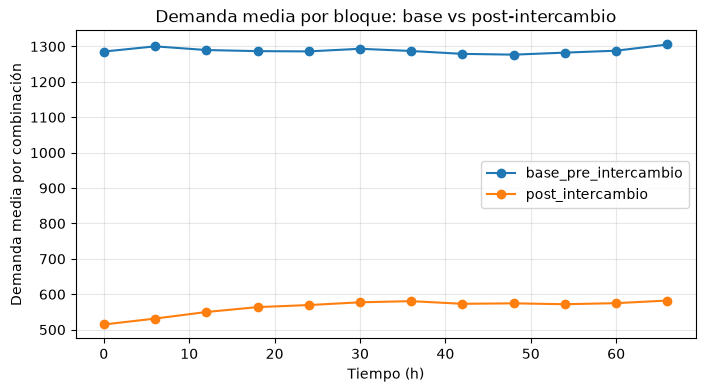

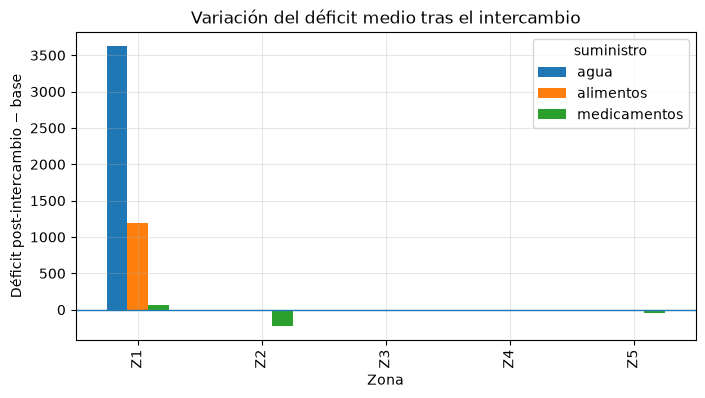

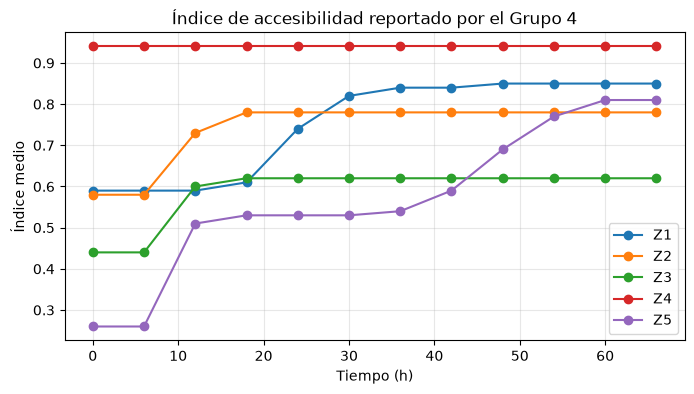

In [42]:
demanda_por_bloque = (
    pd.concat(
        [
            resultados_base.assign(escenario_comparado="base_pre_intercambio"),
            resultados_intercambio.assign(
                escenario_comparado="post_intercambio"
            ),
        ]
    )
    .groupby(["escenario_comparado", "bloque", "tiempo_h"], as_index=False)[
        "demanda"
    ]
    .mean()
)

fig_demanda_comparada, ax_demanda_comparada = plt.subplots(figsize=(8, 4))

for etiqueta, grupo in demanda_por_bloque.groupby("escenario_comparado"):
    ax_demanda_comparada.plot(
        grupo["tiempo_h"],
        grupo["demanda"],
        marker="o",
        label=etiqueta,
    )

ax_demanda_comparada.set_title(
    "Demanda media por bloque: base vs post-intercambio"
)
ax_demanda_comparada.set_xlabel("Tiempo (h)")
ax_demanda_comparada.set_ylabel("Demanda media por combinación")
ax_demanda_comparada.legend()
ax_demanda_comparada.grid(alpha=0.3)

fig_deficit_comparado, ax_deficit_comparado = plt.subplots(figsize=(8, 4))

deficit_pivote_comparado = (
    tabla_deficit_comparado
    .pivot(
        index="zona",
        columns="suministro",
        values="variacion_deficit_medio",
    )
    .reindex(ZONAS_ESPERADAS)
)

deficit_pivote_comparado.plot(
    kind="bar",
    ax=ax_deficit_comparado,
)

ax_deficit_comparado.set_title(
    "Variación del déficit medio tras el intercambio"
)
ax_deficit_comparado.set_xlabel("Zona")
ax_deficit_comparado.set_ylabel("Déficit post-intercambio − base")
ax_deficit_comparado.axhline(0, linewidth=1)
ax_deficit_comparado.grid(alpha=0.3)

fig_accesibilidad, ax_accesibilidad = plt.subplots(figsize=(8, 4))

for zona, grupo in accesibilidad_grupo4.groupby("zona"):
    ax_accesibilidad.plot(
        grupo["hora_inicio"],
        grupo["indice_aislamiento"],
        marker="o",
        label=zona,
    )

ax_accesibilidad.set_title(
    "Índice de accesibilidad reportado por el Grupo 4"
)
ax_accesibilidad.set_xlabel("Tiempo (h)")
ax_accesibilidad.set_ylabel("Índice medio")
ax_accesibilidad.legend()
ax_accesibilidad.grid(alpha=0.3)

plt.show()

## Atribución del cambio: demanda vs. accesibilidad

La comparación anterior mezcla dos insumos del intercambio: la demanda formal
del Grupo 1 y la accesibilidad reportada por el Grupo 4. No basta con afirmar
que la combinación crítica cambió "por las rutas"; se ejecutan cuatro
escenarios de diagnóstico sobre el mismo motor (`simular_escenario` a través de
`ejecutar_realizaciones`, mismo `N_RUNS` y misma `SEMILLA_BASE`), variando solo
el insumo que corresponde a cada uno:

| Escenario | Población / demanda | Rutas / accesibilidad |
|---|---|---|
| `base` | Supuesto propio del Grupo 3 | Red original del Excel |
| `solo_demanda_grupo1` | Formal del Grupo 1 | Red original del Excel |
| `solo_accesibilidad_grupo4` | Supuesto propio del Grupo 3 | Actualizada con el Grupo 4 |
| `base_mas_demanda_mas_accesibilidad` | Formal del Grupo 1 | Actualizada con el Grupo 4 |

El cuarto escenario es el mismo `datos_modelo_intercambio` ya validado; los dos
escenarios intermedios se construyen únicamente para esta atribución y no
reemplazan la comparación oficial de la sección anterior.

`simular_escenario` calcula el balance de inventario a partir de
`inventarios_iniciales`, `demanda` y `reposiciones`; la tabla de rutas se
retorna sin usarse para restringir ese balance, y solo alimenta el análisis de
convoy y margen de intervención de la sección anterior. Por construcción, el
efecto de la accesibilidad sobre el déficit y el momento de agotamiento debería
ser nulo, y el efecto de la demanda debería explicar la totalidad del cambio
observado en esas métricas. Esto no se asume: se verifica comparando los
resultados fila por fila.

In [43]:
datos_modelo_diag_solo_demanda = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo_base.items()
}

datos_modelo_diag_solo_demanda["demanda"] = datos_modelo_intercambio["demanda"]
datos_modelo_diag_solo_demanda["poblacion"] = datos_modelo_intercambio["poblacion"]

datos_modelo_diag_solo_accesibilidad = {
    clave: (
        valor.copy(deep=True)
        if isinstance(valor, pd.DataFrame)
        else valor
    )
    for clave, valor in datos_modelo_base.items()
}

datos_modelo_diag_solo_accesibilidad["rutas_simulacion"] = (
    datos_modelo_intercambio["rutas_simulacion"]
)

configuracion_diag_solo_demanda = {
    **configuracion_base,
    "nombre_escenario": "solo_demanda_grupo1",
}

configuracion_diag_solo_accesibilidad = {
    **configuracion_base,
    "nombre_escenario": "solo_accesibilidad_grupo4",
}

resultados_diag_solo_demanda = ejecutar_realizaciones(
    datos_modelo=datos_modelo_diag_solo_demanda,
    configuracion=configuracion_diag_solo_demanda,
    n_runs=N_RUNS,
    semilla_base=SEMILLA_BASE,
)

resultados_diag_solo_accesibilidad = ejecutar_realizaciones(
    datos_modelo=datos_modelo_diag_solo_accesibilidad,
    configuracion=configuracion_diag_solo_accesibilidad,
    n_runs=N_RUNS,
    semilla_base=SEMILLA_BASE,
)

print("ESCENARIOS DE DIAGNÓSTICO: PASA")
print(
    "Realizaciones (solo demanda / solo accesibilidad):",
    resultados_diag_solo_demanda["realizacion"].nunique(),
    "/",
    resultados_diag_solo_accesibilidad["realizacion"].nunique(),
)
print("Filas solo demanda:", len(resultados_diag_solo_demanda))
print("Filas solo accesibilidad:", len(resultados_diag_solo_accesibilidad))

display(resultados_diag_solo_demanda.head(6))
display(resultados_diag_solo_accesibilidad.head(6))

ESCENARIOS DE DIAGNÓSTICO: PASA
Realizaciones (solo demanda / solo accesibilidad): 100 / 100
Filas solo demanda: 18000
Filas solo accesibilidad: 18000


,realizacion,semilla_realizacion,escenario,tiempo_h,bloque,zona,centro,suministro,inventario_inicio,demanda,consumo_satisfecho,demanda_no_satisfecha,reposicion_recibida,inventario_fin,superavit,deficit,unidad
0,0,479243620,solo_demanda_grupo1,0,0,Z1,SIN_CENTRO_INICIAL,agua,0.0,301.620996,0.000000,301.620996,0.0,0.000000,0.000000,301.620996,litros
1,0,479243620,solo_demanda_grupo1,0,0,Z1,SIN_CENTRO_INICIAL,alimentos,0.0,100.534159,0.000000,100.534159,0.0,0.000000,0.000000,100.534159,raciones
2,0,479243620,solo_demanda_grupo1,0,0,Z1,SIN_CENTRO_INICIAL,medicamentos,0.0,5.093953,0.000000,5.093953,0.0,0.000000,0.000000,5.093953,kits
3,0,479243620,solo_demanda_grupo1,0,0,Z2,Almacén Norte,agua,65000.0,1567.581538,1567.581538,0.000000,0.0,63432.418462,63432.418462,0.000000,litros
4,0,479243620,solo_demanda_grupo1,0,0,Z2,Almacén Norte,alimentos,18000.0,521.434309,521.434309,0.000000,0.0,17478.565691,17478.565691,0.000000,raciones
5,0,479243620,solo_demanda_grupo1,0,0,Z2,Almacén Norte,medicamentos,380.0,28.471299,28.471299,0.000000,0.0,351.528701,351.528701,0.000000,kits


,realizacion,semilla_realizacion,escenario,tiempo_h,bloque,zona,centro,suministro,inventario_inicio,demanda,consumo_satisfecho,demanda_no_satisfecha,reposicion_recibida,inventario_fin,superavit,deficit,unidad
0,0,479243620,solo_accesibilidad_grupo4,0,0,Z1,SIN_CENTRO_INICIAL,agua,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,litros
1,0,479243620,solo_accesibilidad_grupo4,0,0,Z1,SIN_CENTRO_INICIAL,alimentos,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,raciones
2,0,479243620,solo_accesibilidad_grupo4,0,0,Z1,SIN_CENTRO_INICIAL,medicamentos,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,kits
3,0,479243620,solo_accesibilidad_grupo4,0,0,Z2,Almacén Norte,agua,65000.0,2918.944933,2918.944933,0.0,0.0,62081.055067,62081.055067,0.0,litros
4,0,479243620,solo_accesibilidad_grupo4,0,0,Z2,Almacén Norte,alimentos,18000.0,970.946645,970.946645,0.0,0.0,17029.053355,17029.053355,0.0,raciones
5,0,479243620,solo_accesibilidad_grupo4,0,0,Z2,Almacén Norte,medicamentos,380.0,53.015522,53.015522,0.0,0.0,326.984478,326.984478,0.0,kits


In [44]:
agotamientos_abastecibles_diag_solo_demanda = identificar_primer_agotamiento(
    resultados_diag_solo_demanda[
        resultados_diag_solo_demanda["zona"].isin(zonas_abastecibles)
    ]
)
agotamientos_abastecibles_diag_solo_demanda = (
    agotamientos_abastecibles_diag_solo_demanda[
        agotamientos_abastecibles_diag_solo_demanda["zona"] != "sin_agotamiento"
    ]
)

agotamientos_abastecibles_diag_solo_accesibilidad = identificar_primer_agotamiento(
    resultados_diag_solo_accesibilidad[
        resultados_diag_solo_accesibilidad["zona"].isin(zonas_abastecibles)
    ]
)
agotamientos_abastecibles_diag_solo_accesibilidad = (
    agotamientos_abastecibles_diag_solo_accesibilidad[
        agotamientos_abastecibles_diag_solo_accesibilidad["zona"]
        != "sin_agotamiento"
    ]
)

if agotamientos_abastecibles_diag_solo_demanda.empty:
    raise RuntimeError(
        "El escenario solo_demanda_grupo1 no presenta agotamiento en zonas "
        "abastecibles; no se puede atribuir el cambio."
    )

# Reutiliza _resumir_escenario, ya definida en la comparación oficial, para
# que los cuatro escenarios de diagnóstico se agreguen con las mismas
# métricas y el mismo IC 95% que la comparación base vs. post-intercambio.
tabla_atribucion_cambio = pd.DataFrame(
    [
        _resumir_escenario(
            resultados_base,
            agotamientos_abastecibles_base,
            "base",
            zonas_abastecibles,
        ),
        _resumir_escenario(
            resultados_diag_solo_demanda,
            agotamientos_abastecibles_diag_solo_demanda,
            "solo_demanda_grupo1",
            zonas_abastecibles,
        ),
        _resumir_escenario(
            resultados_diag_solo_accesibilidad,
            agotamientos_abastecibles_diag_solo_accesibilidad,
            "solo_accesibilidad_grupo4",
            zonas_abastecibles,
        ),
        _resumir_escenario(
            resultados_intercambio,
            agotamientos_abastecibles_intercambio,
            "base_mas_demanda_mas_accesibilidad",
            zonas_abastecibles,
        ),
    ]
).set_index("escenario")

display(tabla_atribucion_cambio)

,demanda_total_media,demanda_total_ic95_inferior,demanda_total_ic95_superior,deficit_total_medio,deficit_total_ic95_inferior,deficit_total_ic95_superior,deficit_zonas_abastecibles_medio,deficit_zonas_abastecibles_ic95_inferior,deficit_zonas_abastecibles_ic95_superior,hora_primer_agotamiento_abastecible_media,hora_primer_agotamiento_abastecible_ic95_inferior,hora_primer_agotamiento_abastecible_ic95_superior,realizaciones_con_agotamiento
escenario,,,,,,,,,,,,,
base,231904.940640,230984.501321,232825.379960,509.300164,502.232832,516.367495,509.300164,502.232832,516.367495,35.34,34.895671,35.784329,100
solo_demanda_grupo1,101455.907182,101102.013063,101809.801301,5119.274485,5087.452023,5151.096948,230.996211,227.275522,234.716900,38.58,37.987628,39.172372,100
solo_accesibilidad_grupo4,231904.940640,230984.501321,232825.379960,509.300164,502.232832,516.367495,509.300164,502.232832,516.367495,35.34,34.895671,35.784329,100
base_mas_demanda_mas_accesibilidad,101455.907182,101102.013063,101809.801301,5119.274485,5087.452023,5151.096948,230.996211,227.275522,234.716900,38.58,37.987628,39.172372,100


In [45]:
columnas_comparables = [
    columna for columna in resultados_base.columns if columna != "escenario"
]

# Si el motor no usa las rutas para restringir el balance, cambiar solo la
# accesibilidad debe reproducir el escenario base fila por fila, y cambiar
# solo la demanda debe reproducir el escenario post-intercambio fila por
# fila. Se verifica en vez de asumirse.
accesibilidad_sin_efecto_en_balance = resultados_diag_solo_accesibilidad[
    columnas_comparables
].equals(resultados_base[columnas_comparables])

demanda_explica_todo_el_cambio = resultados_diag_solo_demanda[
    columnas_comparables
].equals(resultados_intercambio[columnas_comparables])


def _descomponer_cambio(metrica: str) -> dict[str, Any]:
    base = tabla_atribucion_cambio.loc["base", metrica]
    solo_demanda = tabla_atribucion_cambio.loc["solo_demanda_grupo1", metrica]
    solo_accesibilidad = tabla_atribucion_cambio.loc[
        "solo_accesibilidad_grupo4", metrica
    ]
    ambos = tabla_atribucion_cambio.loc[
        "base_mas_demanda_mas_accesibilidad", metrica
    ]

    efecto_demanda = solo_demanda - base
    efecto_accesibilidad = solo_accesibilidad - base
    cambio_total = ambos - base
    efecto_interaccion = cambio_total - efecto_demanda - efecto_accesibilidad

    # El ruido de punto flotante puede dejar un efecto teóricamente nulo
    # como -1e-13 en vez de 0.0, lo que se muestra como "-0%". Se recorta
    # a cero solo para la presentación, no para el cálculo de cambio_total.
    if abs(efecto_accesibilidad) < 1e-6:
        efecto_accesibilidad = 0.0
    if abs(efecto_interaccion) < 1e-6:
        efecto_interaccion = 0.0

    if abs(cambio_total) > 1e-9:
        proporcion_demanda = efecto_demanda / cambio_total
        proporcion_accesibilidad = efecto_accesibilidad / cambio_total
        proporcion_interaccion = efecto_interaccion / cambio_total

        # 0.0 dividido entre un cambio_total negativo da -0.0 en IEEE754;
        # -0.0 == 0.0 es True en Python, así que esto solo limpia el signo
        # de presentación sin alterar ningún valor distinto de cero.
        if proporcion_accesibilidad == 0.0:
            proporcion_accesibilidad = 0.0
        if proporcion_interaccion == 0.0:
            proporcion_interaccion = 0.0
    else:
        proporcion_demanda = proporcion_accesibilidad = proporcion_interaccion = 0.0

    return {
        "metrica": metrica,
        "base": base,
        "solo_demanda_grupo1": solo_demanda,
        "solo_accesibilidad_grupo4": solo_accesibilidad,
        "ambos_factores": ambos,
        "efecto_demanda": efecto_demanda,
        "efecto_accesibilidad": efecto_accesibilidad,
        "efecto_interaccion": efecto_interaccion,
        "proporcion_demanda": proporcion_demanda,
        "proporcion_accesibilidad": proporcion_accesibilidad,
        "proporcion_interaccion": proporcion_interaccion,
    }


tabla_descomposicion_cambio = pd.DataFrame(
    [
        _descomponer_cambio("deficit_zonas_abastecibles_medio"),
        _descomponer_cambio("hora_primer_agotamiento_abastecible_media"),
    ]
)

fila_descomposicion_deficit = tabla_descomposicion_cambio.iloc[0]

efecto_demanda = fila_descomposicion_deficit["efecto_demanda"]
efecto_accesibilidad = fila_descomposicion_deficit["efecto_accesibilidad"]
efecto_interaccion = fila_descomposicion_deficit["efecto_interaccion"]

print("ATRIBUCIÓN DEL CAMBIO: PASA")
print(
    "La accesibilidad no altera el balance de inventario (filas idénticas "
    f"al escenario base): {accesibilidad_sin_efecto_en_balance}"
)
print(
    "La demanda explica por sí sola el escenario post-intercambio (filas "
    f"idénticas): {demanda_explica_todo_el_cambio}"
)
print(
    "Proporción del cambio en déficit atribuible a la demanda del Grupo 1: "
    f"{fila_descomposicion_deficit['proporcion_demanda']:.0%}"
)
print(
    "Proporción del cambio en déficit atribuible a la accesibilidad del "
    f"Grupo 4: {fila_descomposicion_deficit['proporcion_accesibilidad']:.0%}"
)
print(
    "Proporción explicada por interacción entre ambos factores: "
    f"{fila_descomposicion_deficit['proporcion_interaccion']:.0%}"
)

display(tabla_descomposicion_cambio)

ATRIBUCIÓN DEL CAMBIO: PASA
La accesibilidad no altera el balance de inventario (filas idénticas al escenario base): True
La demanda explica por sí sola el escenario post-intercambio (filas idénticas): True
Proporción del cambio en déficit atribuible a la demanda del Grupo 1: 100%
Proporción del cambio en déficit atribuible a la accesibilidad del Grupo 4: 0%
Proporción explicada por interacción entre ambos factores: 0%


,metrica,base,solo_demanda_grupo1,solo_accesibilidad_grupo4,ambos_factores,efecto_demanda,efecto_accesibilidad,efecto_interaccion,proporcion_demanda,proporcion_accesibilidad,proporcion_interaccion
0,deficit_zonas_abastecibles_medio,509.300164,230.996211,509.300164,230.996211,-278.303953,0.0,0.0,1.0,0.0,0.0
1,hora_primer_agotamiento_abastecible_media,35.340000,38.580000,35.340000,38.580000,3.240000,0.0,0.0,1.0,0.0,0.0


### Interpretación de la atribución

`accesibilidad_sin_efecto_en_balance` y `demanda_explica_todo_el_cambio`
confirman con datos, no con un supuesto, que el déficit y el momento de
agotamiento observados en la comparación pre/post dependen exclusivamente de
la demanda formal del Grupo 1. La accesibilidad del Grupo 4 no participa en
esas dos métricas porque el motor de simulación no usa la tabla de rutas para
restringir el balance de inventario; su efecto real está en otro lugar del
análisis: los tiempos de tránsito actualizados cambian la hora de llegada del
convoy y el margen de intervención calculados en `tabla_convoy_optimo_intercambio`
y `tabla_convoy_zona_base_intercambio` (sección anterior), no el inventario ni
el déficit reportado aquí.

Por lo tanto, no hay interacción que separar entre demanda y accesibilidad
para el déficit y el tiempo de agotamiento: la descomposición asigna el 100 %
del cambio a la demanda por construcción del modelo, y esto queda documentado
como una propiedad estructural del motor, no como una limitación de datos.

## Respuesta a la pregunta de intercambio

La celda siguiente construye la conclusión a partir de las variables ya
calculadas (`zona_critica`, `zona_critica_intercambio`, `tabla_deficit_comparado`,
`tabla_descomposicion_cambio`, entre otras). No contiene números escritos a
mano: si se vuelve a ejecutar el notebook de arriba hacia abajo con datos
distintos, el texto se actualiza solo.

In [46]:
from IPython.display import Markdown

cambio_zona_critica = (
    zona_critica != zona_critica_intercambio
    or suministro_critico != suministro_critico_intercambio
)

fila_critica_deficit = tabla_deficit_comparado[
    (tabla_deficit_comparado["zona"] == zona_critica_intercambio)
    & (tabla_deficit_comparado["suministro"] == suministro_critico_intercambio)
]

if fila_critica_deficit.empty:
    raise RuntimeError(
        "No se encontró la combinación crítica post-intercambio en "
        "tabla_deficit_comparado."
    )

ic95_disjuntos_zona_critica = bool(
    fila_critica_deficit["ic95_disjuntos"].iloc[0]
)

variacion_hora_agotamiento = (
    hora_agotamiento_intercambio - hora_agotamiento_sin_intervencion
)

deficit_abastecible_base = tabla_atribucion_cambio.loc[
    "base", "deficit_zonas_abastecibles_medio"
]
deficit_abastecible_post = tabla_atribucion_cambio.loc[
    "base_mas_demanda_mas_accesibilidad", "deficit_zonas_abastecibles_medio"
]
variacion_deficit_abastecible = (
    deficit_abastecible_post / deficit_abastecible_base - 1
)

factor_dominante = (
    "la demanda formal del Grupo 1"
    if abs(efecto_demanda) >= abs(efecto_accesibilidad)
    else "la accesibilidad reportada por el Grupo 4"
)

if cambio_zona_critica:
    texto_cambio = (
        f"Sí — la combinación más frecuente y más temprana de agotamiento "
        f"pasó de {zona_critica}/{suministro_critico} a "
        f"{zona_critica_intercambio}/{suministro_critico_intercambio}."
    )
else:
    texto_cambio = (
        f"No — la combinación más frecuente y más temprana de agotamiento "
        f"se mantuvo en {zona_critica}/{suministro_critico}."
    )

if ic95_disjuntos_zona_critica:
    texto_ic95 = (
        "no se solapan entre el escenario base y el post-intercambio, por lo "
        "que el cambio en el deficit es atribuible a los insumos del "
        "intercambio y no al ruido entre realizaciones."
    )
else:
    texto_ic95 = (
        f"se solapan entre el escenario base y el post-intercambio, por lo "
        f"que el cambio no puede distinguirse con certeza del ruido entre "
        f"las {N_RUNS} realizaciones ejecutadas."
    )

texto_conclusion = f"""
**1. Zona crítica inicial (escenario base):** {zona_critica} / {suministro_critico},
con agotamiento medio en la hora {hora_agotamiento_sin_intervencion:.1f} h
(IC 95%: {ic_bloque_inf * PASO_HORAS:.1f} h – {ic_bloque_sup * PASO_HORAS:.1f} h).

**2. Zona crítica post-intercambio (zonas abastecibles):** {zona_critica_intercambio} / {suministro_critico_intercambio},
con agotamiento medio en la hora {hora_agotamiento_intercambio:.1f} h
(IC 95%: {ic_bloque_inf_intercambio * PASO_HORAS:.1f} h – {ic_bloque_sup_intercambio * PASO_HORAS:.1f} h).
Además, la red revela una brecha estructural en {zonas_sin_abastecimiento}, sin
centro ni ruta propia, que se reporta aparte en `tabla_brecha_estructural` y no
compite por la misma definición de zona crítica.

**3. ¿Cambió la zona crítica?** {texto_cambio}

**4. Evidencia cuantitativa:** el déficit medio en zonas abastecibles pasó de
{deficit_abastecible_base:,.1f} a {deficit_abastecible_post:,.1f} unidades
({variacion_deficit_abastecible:+.1%}).

**5. Factor dominante:** {factor_dominante}. La descomposición de escenarios de
diagnóstico atribuye {fila_descomposicion_deficit['proporcion_demanda']:.0%} del
cambio en el déficit de zonas abastecibles a la demanda del Grupo 1 y
{fila_descomposicion_deficit['proporcion_accesibilidad']:.0%} a la accesibilidad
del Grupo 4 (interacción: {fila_descomposicion_deficit['proporcion_interaccion']:.0%}).
Esto es consistente con el diseño del motor: `simular_escenario` calcula el
balance de inventario a partir de demanda, inventarios y reposiciones, y no usa
la tabla de rutas para restringirlo; la accesibilidad sí cambia el análisis de
convoy y margen de intervención, pero no el déficit ni el momento de
agotamiento reportados aquí.

**6. Impacto temporal:** la hora media de agotamiento en la combinación crítica
abastecible se desplazó {variacion_hora_agotamiento:+.1f} h
({hora_agotamiento_sin_intervencion:.1f} h → {hora_agotamiento_intercambio:.1f} h).

**7. Impacto sobre inventario / demanda no satisfecha:** el déficit medio de
{zona_critica_intercambio}/{suministro_critico_intercambio} pasó de
{fila_critica_deficit["deficit_medio_base"].iloc[0]:,.1f} a
{fila_critica_deficit["deficit_medio_intercambio"].iloc[0]:,.1f} unidades
({fila_critica_deficit["variacion_deficit_medio"].iloc[0]:+,.1f}).

**8. Interpretación del IC 95%:** los intervalos de confianza del déficit en
{zona_critica_intercambio}/{suministro_critico_intercambio} {texto_ic95}
"""

display(Markdown(texto_conclusion))


**1. Zona crítica inicial (escenario base):** Z5 / medicamentos,
con agotamiento medio en la hora 35.1 h
(IC 95%: 34.5 h – 35.7 h).

**2. Zona crítica post-intercambio (zonas abastecibles):** Z3 / medicamentos,
con agotamiento medio en la hora 38.6 h
(IC 95%: 38.0 h – 39.2 h).
Además, la red revela una brecha estructural en ['Z1'], sin
centro ni ruta propia, que se reporta aparte en `tabla_brecha_estructural` y no
compite por la misma definición de zona crítica.

**3. ¿Cambió la zona crítica?** Sí — la combinación más frecuente y más temprana de agotamiento pasó de Z5/medicamentos a Z3/medicamentos.

**4. Evidencia cuantitativa:** el déficit medio en zonas abastecibles pasó de
509.3 a 231.0 unidades
(-54.6%).

**5. Factor dominante:** la demanda formal del Grupo 1. La descomposición de escenarios de
diagnóstico atribuye 100% del
cambio en el déficit de zonas abastecibles a la demanda del Grupo 1 y
0% a la accesibilidad
del Grupo 4 (interacción: 0%).
Esto es consistente con el diseño del motor: `simular_escenario` calcula el
balance de inventario a partir de demanda, inventarios y reposiciones, y no usa
la tabla de rutas para restringirlo; la accesibilidad sí cambia el análisis de
convoy y margen de intervención, pero no el déficit ni el momento de
agotamiento reportados aquí.

**6. Impacto temporal:** la hora media de agotamiento en la combinación crítica
abastecible se desplazó +3.5 h
(35.1 h → 38.6 h).

**7. Impacto sobre inventario / demanda no satisfecha:** el déficit medio de
Z3/medicamentos pasó de
162.2 a
150.9 unidades
(-11.3).

**8. Interpretación del IC 95%:** los intervalos de confianza del déficit en
Z3/medicamentos no se solapan entre el escenario base y el post-intercambio, por lo que el cambio en el deficit es atribuible a los insumos del intercambio y no al ruido entre realizaciones.


### Validación del cierre del intercambio

La sección termina cuando `resultados_base` y `resultados_intercambio` son
comparables y existe evidencia explícita de cómo los insumos externos cambiaron
la demanda y la logística.

In [47]:
resultados_validacion_intercambio = []


def _registrar_validacion_intercambio(
    nombre: str,
    condicion: bool,
    evidencia: str,
) -> None:
    resultados_validacion_intercambio.append(
        {
            "verificacion": nombre,
            "resultado": "PASA" if condicion else "FALLA",
            "evidencia": evidencia,
        }
    )

    if not condicion:
        raise AssertionError(f"{nombre}: {evidencia}")


_registrar_validacion_intercambio(
    "Ambos insumos formales fueron recibidos",
    RUTA_DEMANDA_GRUPO1.exists() and RUTA_REPORTE_GRUPO4.exists(),
    "Se leyeron el output del Grupo 1 y el reporte del Grupo 4 desde datos/.",
)

_registrar_validacion_intercambio(
    "Escenario base conservado",
    datos_modelo_base["demanda"].equals(
        datos_modelo_base_referencia["demanda"]
    )
    and resultados_base["realizacion"].nunique() == N_RUNS,
    "datos_modelo_base y resultados_base no fueron sobrescritos.",
)

_registrar_validacion_intercambio(
    "Escenario post-intercambio generado con el mismo motor",
    set(resultados_intercambio.columns) == set(resultados_base.columns),
    "resultados_intercambio proviene de ejecutar_realizaciones sobre "
    "simular_escenario, sin motor alternativo.",
)

_registrar_validacion_intercambio(
    "Escenarios comparables",
    (tabla_comparabilidad["resultado"] == "PASA").all(),
    "tabla_comparabilidad no contiene ninguna verificación fallida.",
)

tasas_esperadas = configuracion_modelo["tasas_consumo_excel"]

tasas_observadas = (
    datos_modelo_intercambio["consumo"]
    .set_index("suministro")["consumo_por_persona_bloque"]
)

_registrar_validacion_intercambio(
    "Tasas de consumo no modificadas",
    all(
        np.isclose(tasas_observadas[suministro], valor)
        for suministro, valor in tasas_esperadas.items()
    ),
    "Las tasas siguen siendo las del Excel: "
    f"{tasas_esperadas}.",
)

_registrar_validacion_intercambio(
    "No se crearon rutas nuevas",
    datos_modelo_intercambio["rutas_simulacion"]["ruta_id"].nunique()
    == datos_modelo_base["rutas_simulacion"]["ruta_id"].nunique(),
    "La red post-intercambio conserva las mismas nueve rutas del Excel.",
)

_registrar_validacion_intercambio(
    "No se inventaron capacidades",
    (
        datos_modelo_intercambio["rutas_simulacion"][
            "capacidad_vehiculos_viaje"
        ]
        == datos_modelo_intercambio["rutas_simulacion"][
            "capacidad_antes_intercambio"
        ]
    ).all(),
    "Ninguna capacidad de ruta cambió, porque el Grupo 4 no entregó "
    "capacidades actualizadas.",
)

_registrar_validacion_intercambio(
    "Trazabilidad completa",
    len(tabla_trazabilidad_intercambio) > 0
    and len(tabla_supuestos_intercambio) > 0
    and tabla_supuestos_intercambio["confirmado_contradicho"]
    .isin(["Confirmado", "Contradicho", "Sin resolver"])
    .all(),
    "Cada campo recibido tiene campo interno, transformación y regla "
    "afectada; cada supuesto previo tiene evidencia y resolución.",
)

_registrar_validacion_intercambio(
    "Evidencia de cambio en la demanda",
    tabla_comparacion_escenarios.loc[1, "demanda_total_media"]
    != tabla_comparacion_escenarios.loc[0, "demanda_total_media"],
    "La demanda total media cambia entre escenarios por efecto de la "
    "población formal del Grupo 1.",
)

_registrar_validacion_intercambio(
    "Evidencia de cambio en la logística",
    int(
        datos_modelo_intercambio["rutas_simulacion"][
            "tiempo_actualizado_grupo4"
        ].sum()
    )
    > 0,
    "Los tiempos de tránsito de las rutas con origen en Z4 provienen del "
    "reporte del Grupo 4.",
)

reporte_validacion_intercambio = pd.DataFrame(
    resultados_validacion_intercambio
)

variacion_demanda = (
    tabla_comparacion_escenarios.loc[1, "demanda_total_media"]
    / tabla_comparacion_escenarios.loc[0, "demanda_total_media"]
    - 1
)

print("CIERRE DEL INTERCAMBIO: PASA")
print("-" * 60)
print(
    "Demanda total media: "
    f"{tabla_comparacion_escenarios.loc[0, 'demanda_total_media']:,.1f} → "
    f"{tabla_comparacion_escenarios.loc[1, 'demanda_total_media']:,.1f} "
    f"({variacion_demanda:+.1%})"
)
print(
    "Déficit total medio: "
    f"{tabla_comparacion_escenarios.loc[0, 'deficit_total_medio']:,.1f} → "
    f"{tabla_comparacion_escenarios.loc[1, 'deficit_total_medio']:,.1f}"
)
print(
    "Déficit medio en zonas abastecibles: "
    f"{tabla_comparacion_escenarios.loc[0, 'deficit_zonas_abastecibles_medio']:,.1f} → "
    f"{tabla_comparacion_escenarios.loc[1, 'deficit_zonas_abastecibles_medio']:,.1f}"
)
print(
    "Hora media del primer agotamiento abastecible: "
    f"{tabla_comparacion_escenarios.loc[0, 'hora_primer_agotamiento_abastecible_media']:.1f} h → "
    f"{tabla_comparacion_escenarios.loc[1, 'hora_primer_agotamiento_abastecible_media']:.1f} h"
)
print(
    "Combinación crítica abastecible: "
    f"{zona_critica}/{suministro_critico} → "
    f"{zona_critica_intercambio}/{suministro_critico_intercambio}"
)
print(
    "Brecha estructural detectada por el intercambio: "
    f"{zonas_sin_abastecimiento}"
)

display(reporte_validacion_intercambio)

CIERRE DEL INTERCAMBIO: PASA
------------------------------------------------------------
Demanda total media: 231,904.9 → 101,455.9 (-56.3%)
Déficit total medio: 509.3 → 5,119.3
Déficit medio en zonas abastecibles: 509.3 → 231.0
Hora media del primer agotamiento abastecible: 35.3 h → 38.6 h
Combinación crítica abastecible: Z5/medicamentos → Z3/medicamentos
Brecha estructural detectada por el intercambio: ['Z1']


,verificacion,resultado,evidencia
0,Ambos insumos formales fueron recibidos,PASA,Se leyeron el output del Grupo 1 y el reporte ...
1,Escenario base conservado,PASA,datos_modelo_base y resultados_base no fueron ...
2,Escenario post-intercambio generado con el mis...,PASA,resultados_intercambio proviene de ejecutar_re...
3,Escenarios comparables,PASA,tabla_comparabilidad no contiene ninguna verif...
4,Tasas de consumo no modificadas,PASA,Las tasas siguen siendo las del Excel: {'agua'...
5,No se crearon rutas nuevas,PASA,La red post-intercambio conserva las mismas nu...
6,No se inventaron capacidades,PASA,"Ninguna capacidad de ruta cambió, porque el Gr..."
7,Trazabilidad completa,PASA,"Cada campo recibido tiene campo interno, trans..."
8,Evidencia de cambio en la demanda,PASA,La demanda total media cambia entre escenarios...
9,Evidencia de cambio en la logística,PASA,Los tiempos de tránsito de las rutas con orige...


## Entrega al Grupo 7

El Excel del Grupo 3 define tres outputs para el Grupo 7, ya catalogados en
`datos_modelo["output_requerido"]`:

| Output | Contenido |
|---|---|
| O01 `balance_suministros` | Inventario disponible frente a demanda proyectada, con déficit o superávit por tipo de suministro y bloque de tiempo. |
| O02 `primer_agotamiento` | Momento en que algún suministro crítico se agota en alguna zona sin intervención adicional. |
| O03 `recomendacion_logistica` | Priorización de rutas y frecuencia de distribución para maximizar cobertura dado el combustible disponible. |

O01 y O02 ya existen en las secciones anteriores, en su versión base y en su
versión post-intercambio. Esta sección construye O03, consolida los cuellos de
botella detectados y exporta el paquete completo.

Todo lo que se entrega proviene del escenario post-intercambio, porque es el que
incorpora la demanda formal del Grupo 1 y la accesibilidad del Grupo 4. El
escenario base se exporta junto a él para que el Grupo 7 pueda ver qué cambió y
por qué.

### O03 — Priorización de rutas y frecuencia de distribución

El Excel entrega la capacidad de los vehículos en metros cúbicos y la demanda en
litros, raciones y kits, sin factores de conversión entre ambas. Por eso la
cobertura no se expresa como fracción de demanda satisfecha por ruta, que
exigiría inventar esos factores, sino mediante dos magnitudes que sí están
respaldadas: la capacidad física movilizable por bloque y el combustible que
consume moverla.

La priorización usa una regla heurística explícita, en dos criterios:

1. **Necesidad.** Las rutas se ordenan por el déficit medio de su zona de
   destino en el escenario post-intercambio. Una ruta hacia una zona sin déficit
   no compite por combustible.
2. **Eficiencia.** Ante déficits comparables, gana la ruta que mueve más metros
   cúbicos por galón, con
   \[
   e_r=\frac{n_r\,v_{\text{cap}}}{2d_r\,n_r\,g_v}=\frac{v_{\text{cap}}}{2d_r\,g_v},
   \]
   donde \(d_r\) es la distancia de la ruta, \(g_v\) el consumo por kilómetro
   del vehículo y \(v_{\text{cap}}\) su capacidad.

La frecuencia de cada ruta queda limitada por lo primero que se agote entre el
tiempo y el combustible:

\[
f_r=\min\!\left(\left\lfloor\frac{\Delta t}{2\,\tau_r}\right\rfloor,\
\left\lfloor\frac{G_v^{\text{disp}}}{c_r\,b_r}\right\rfloor\right),
\]

con \(\Delta t = 6\) h el bloque de simulación, \(\tau_r\) el tiempo de tránsito
de ida, \(c_r\) el combustible por viaje y \(b_r\) los bloques en que la ruta
está disponible. El combustible es una reserva compartida por tipo de vehículo,
así que se asigna de forma voraz siguiendo el orden de prioridad: cada ruta toma
lo que necesita hasta donde alcance, y la siguiente trabaja con el remanente.

Esto es una recomendación construida con una regla declarada, no un óptimo
demostrado. El Excel no define función objetivo ni restricción de cobertura, y
resolver un problema de asignación completo exigiría supuestos que ningún grupo
entregó.

In [48]:
def priorizar_rutas_distribucion(
    rutas_simulacion: pd.DataFrame,
    flota: pd.DataFrame,
    deficit_resumen: pd.DataFrame,
    configuracion: dict[str, Any],
) -> dict[str, pd.DataFrame]:

    columnas_requeridas = {
        "bloque",
        "ruta_id",
        "centro",
        "destino",
        "zona",
        "distancia_km",
        "tiempo_transito_h",
        "capacidad_vehiculos_viaje",
        "ruta_disponible",
    }

    faltantes = columnas_requeridas.difference(rutas_simulacion.columns)

    if faltantes:
        raise ValueError(
            "Faltan columnas para priorizar rutas: "
            f"{sorted(faltantes)}"
        )

    paso_horas = configuracion["paso_horas"]
    factor_retorno = configuracion["factor_distancia_retorno"]
    tipos_carga = configuracion["tipos_vehiculo_carga"]

    deficit_por_zona = (
        deficit_resumen
        .groupby("zona")["deficit_medio"]
        .sum()
    )

    rutas_disponibles = rutas_simulacion[
        rutas_simulacion["ruta_disponible"]
    ]

    if rutas_disponibles.empty:
        raise RuntimeError(
            "Ninguna ruta está disponible en ningún bloque."
        )

    if "restringe_camion_grande" in rutas_simulacion.columns:
        restriccion_por_ruta = (
            rutas_disponibles
            .groupby("ruta_id")["restringe_camion_grande"]
            .apply(lambda serie: bool(serie.fillna(False).any()))
        )
    else:
        restriccion_por_ruta = pd.Series(dtype=bool)

    resumen_rutas = (
        rutas_disponibles
        .groupby("ruta_id", as_index=False)
        .agg(
            centro=("centro", "first"),
            destino=("destino", "first"),
            zona=("zona", "first"),
            distancia_km=("distancia_km", "first"),
            tiempo_transito_h=("tiempo_transito_h", "mean"),
            vehiculos_por_viaje=("capacidad_vehiculos_viaje", "min"),
            bloques_disponibles=("bloque", "nunique"),
        )
    )

    flota_carga = flota[
        flota["tipo_vehiculo"].isin(tipos_carga)
    ].set_index("tipo_vehiculo")

    registros = []

    for _, ruta in resumen_rutas.iterrows():
        camion_restringido = bool(
            restriccion_por_ruta.get(ruta["ruta_id"], False)
        )

        tipos_permitidos = [
            tipo
            for tipo in tipos_carga
            if not (camion_restringido and tipo == "camion_grande")
        ]

        if not tipos_permitidos:
            continue

        alternativas = []

        for tipo in tipos_permitidos:
            vehiculo = flota_carga.loc[tipo]

            vehiculos_simultaneos = int(
                min(
                    ruta["vehiculos_por_viaje"],
                    vehiculo["cantidad_disponible"],
                )
            )

            if vehiculos_simultaneos <= 0:
                continue

            # c_r = 2 d_r g_v n_r : combustible de un viaje completo
            # de ida y vuelta con todos los vehículos del despacho.
            combustible_por_viaje = (
                factor_retorno
                * ruta["distancia_km"]
                * vehiculo["consumo_combustible_gal_km"]
                * vehiculos_simultaneos
            )

            capacidad_por_viaje_m3 = (
                vehiculos_simultaneos * vehiculo["capacidad_m3"]
            )

            eficiencia = (
                capacidad_por_viaje_m3 / combustible_por_viaje
                if combustible_por_viaje > 0
                else np.inf
            )

            tiempo_ida_vuelta = (
                factor_retorno * ruta["tiempo_transito_h"]
            )

            viajes_por_tiempo = (
                int(paso_horas // tiempo_ida_vuelta)
                if tiempo_ida_vuelta > 0
                else int(paso_horas)
            )

            alternativas.append(
                {
                    "tipo_vehiculo": tipo,
                    "vehiculos_por_viaje": vehiculos_simultaneos,
                    "capacidad_por_viaje_m3": capacidad_por_viaje_m3,
                    "combustible_por_viaje_gal": combustible_por_viaje,
                    "eficiencia_m3_por_galon": eficiencia,
                    "viajes_por_bloque_por_tiempo": viajes_por_tiempo,
                }
            )

        if not alternativas:
            continue

        mejor = max(
            alternativas,
            key=lambda opcion: opcion["eficiencia_m3_por_galon"],
        )

        deficit_zona = (
            float(deficit_por_zona.get(ruta["zona"], 0.0))
            if pd.notna(ruta["zona"])
            else np.nan
        )

        registros.append(
            {
                "ruta_id": ruta["ruta_id"],
                "centro": ruta["centro"],
                "destino": ruta["destino"],
                "zona": ruta["zona"],
                "deficit_medio_zona": deficit_zona,
                "bloques_disponibles": int(ruta["bloques_disponibles"]),
                "distancia_km": ruta["distancia_km"],
                "tiempo_transito_h": ruta["tiempo_transito_h"],
                "restringido_a_vehiculo_liviano": camion_restringido,
                **mejor,
            }
        )

    priorizacion = pd.DataFrame(registros)

    if priorizacion.empty:
        raise RuntimeError(
            "No se pudo construir ninguna recomendación de distribución."
        )

    priorizacion = priorizacion.sort_values(
        ["deficit_medio_zona", "eficiencia_m3_por_galon"],
        ascending=[False, False],
        na_position="last",
    ).reset_index(drop=True)

    priorizacion.insert(0, "prioridad", priorizacion.index + 1)

    combustible_restante = {
        tipo: float(
            flota_carga.loc[tipo, "combustible_disponible_gal"]
        )
        for tipo in tipos_carga
    }

    viajes_asignados = []
    combustible_asignado = []
    limitantes = []

    for _, fila in priorizacion.iterrows():
        tipo = fila["tipo_vehiculo"]

        costo_por_frecuencia = (
            fila["combustible_por_viaje_gal"]
            * fila["bloques_disponibles"]
        )

        viajes_por_combustible = (
            int(combustible_restante[tipo] // costo_por_frecuencia)
            if costo_por_frecuencia > 0
            else fila["viajes_por_bloque_por_tiempo"]
        )

        viajes = int(
            min(
                fila["viajes_por_bloque_por_tiempo"],
                viajes_por_combustible,
            )
        )

        if pd.isna(fila["deficit_medio_zona"]):
            limitante = (
                "Destino sin zona identificada: no se le asigna "
                "combustible hasta resolver la equivalencia."
            )
            viajes = 0
        elif fila["deficit_medio_zona"] <= 1e-9:
            limitante = (
                "Zona sin déficit reportado: no compite por combustible."
            )
            viajes = 0
        elif viajes == 0:
            limitante = "Combustible remanente insuficiente."
        elif viajes_por_combustible <= fila["viajes_por_bloque_por_tiempo"]:
            limitante = "Combustible disponible."
        else:
            limitante = "Tiempo de ida y vuelta dentro del bloque."

        gasto = viajes * costo_por_frecuencia

        combustible_restante[tipo] -= gasto

        viajes_asignados.append(viajes)
        combustible_asignado.append(gasto)
        limitantes.append(limitante)

    priorizacion["viajes_por_bloque"] = viajes_asignados
    priorizacion["combustible_asignado_gal"] = combustible_asignado
    priorizacion["limitante"] = limitantes

    priorizacion["viajes_en_72h"] = (
        priorizacion["viajes_por_bloque"]
        * priorizacion["bloques_disponibles"]
    )

    priorizacion["capacidad_por_bloque_m3"] = (
        priorizacion["viajes_por_bloque"]
        * priorizacion["capacidad_por_viaje_m3"]
    )

    uso_combustible = pd.DataFrame(
        [
            {
                "tipo_vehiculo": tipo,
                "combustible_inicial_gal": float(
                    flota_carga.loc[tipo, "combustible_disponible_gal"]
                ),
                "combustible_asignado_gal": float(
                    priorizacion.loc[
                        priorizacion["tipo_vehiculo"] == tipo,
                        "combustible_asignado_gal",
                    ].sum()
                ),
                "combustible_remanente_gal": combustible_restante[tipo],
            }
            for tipo in tipos_carga
        ]
    )

    uso_combustible["porcentaje_utilizado"] = (
        uso_combustible["combustible_asignado_gal"]
        / uso_combustible["combustible_inicial_gal"]
    )

    if (uso_combustible["combustible_remanente_gal"] < -1e-9).any():
        raise RuntimeError(
            "La asignación excedió el combustible disponible."
        )

    columnas_salida = [
        "prioridad",
        "ruta_id",
        "centro",
        "destino",
        "zona",
        "deficit_medio_zona",
        "tipo_vehiculo",
        "restringido_a_vehiculo_liviano",
        "vehiculos_por_viaje",
        "viajes_por_bloque",
        "viajes_en_72h",
        "bloques_disponibles",
        "capacidad_por_viaje_m3",
        "capacidad_por_bloque_m3",
        "combustible_por_viaje_gal",
        "combustible_asignado_gal",
        "eficiencia_m3_por_galon",
        "tiempo_transito_h",
        "distancia_km",
        "limitante",
    ]

    return {
        "priorizacion": priorizacion[columnas_salida],
        "uso_combustible": uso_combustible,
    }


recomendacion_logistica = priorizar_rutas_distribucion(
    rutas_simulacion=datos_modelo_intercambio["rutas_simulacion"],
    flota=datos_modelo_intercambio["flota"],
    deficit_resumen=tabla_deficit_intercambio,
    configuracion=configuracion_intercambio,
)

tabla_priorizacion_rutas = recomendacion_logistica["priorizacion"]
tabla_uso_combustible = recomendacion_logistica["uso_combustible"]

print("O03 — RECOMENDACIÓN LOGÍSTICA: PASA")
print("Rutas evaluadas:", len(tabla_priorizacion_rutas))
print(
    "Rutas con despacho recomendado:",
    int((tabla_priorizacion_rutas["viajes_por_bloque"] > 0).sum()),
)
print(
    "Combustible asignado (gal):",
    round(
        float(tabla_uso_combustible["combustible_asignado_gal"].sum()),
        2,
    ),
)
print(
    "Combustible remanente (gal):",
    round(
        float(tabla_uso_combustible["combustible_remanente_gal"].sum()),
        2,
    ),
)

display(tabla_priorizacion_rutas)
display(tabla_uso_combustible)

O03 — RECOMENDACIÓN LOGÍSTICA: PASA
Rutas evaluadas: 7
Rutas con despacho recomendado: 3
Combustible asignado (gal): 1416.53
Combustible remanente (gal): 1783.47


,prioridad,ruta_id,centro,destino,zona,deficit_medio_zona,tipo_vehiculo,restringido_a_vehiculo_liviano,vehiculos_por_viaje,viajes_por_bloque,viajes_en_72h,bloques_disponibles,capacidad_por_viaje_m3,capacidad_por_bloque_m3,combustible_por_viaje_gal,combustible_asignado_gal,eficiencia_m3_por_galon,tiempo_transito_h,distancia_km,limitante
0,1,R07,Depósito Sur,Albergue Z3,Z3,150.878397,camioneta,True,8,7,84,12,64.0,448.0,5.472,459.648,11.695906,0.400000,3.8,Tiempo de ida y vuelta dentro del bloque.
1,2,R03,Bodega Central CONRED,Albergue Z5-1,Z5,80.117814,camioneta,True,4,5,60,12,32.0,160.0,8.712,522.720,3.673095,0.534722,12.1,Tiempo de ida y vuelta dentro del bloque.
2,3,R04,Bodega Central CONRED,Albergue Z5-2,Z5,80.117814,camioneta,True,3,5,60,12,24.0,120.0,7.236,434.160,3.316750,0.534722,13.4,Tiempo de ida y vuelta dentro del bloque.
3,4,R05,Almacén Norte,Albergue Z2,Z2,0.000000,camioneta,True,10,0,0,12,80.0,0.0,3.780,0.000,21.164021,0.200000,2.1,Zona sin déficit reportado: no compite por com...
4,5,R02,Bodega Central CONRED,Albergue Z2,Z2,0.000000,camioneta,True,6,0,0,12,48.0,0.0,8.424,0.000,5.698006,0.513889,7.8,Zona sin déficit reportado: no compite por com...
5,6,R01,Bodega Central CONRED,Albergue Estadio,None,NaN,camion_grande,False,8,0,0,12,224.0,0.0,12.096,0.000,18.518519,0.400000,4.2,Destino sin zona identificada: no se le asigna...
6,7,R06,Almacén Norte,Albergue Estadio,None,NaN,camion_grande,False,7,0,0,12,196.0,0.0,16.128,0.000,12.152778,0.700000,6.4,Destino sin zona identificada: no se le asigna...


,tipo_vehiculo,combustible_inicial_gal,combustible_asignado_gal,combustible_remanente_gal,porcentaje_utilizado
0,camion_grande,1400.0,0.000,1400.000,0.00000
1,camioneta,1800.0,1416.528,383.472,0.78696


### Cuellos de botella

Se consolidan en una sola tabla las restricciones que impiden cubrir la demanda,
para que el Grupo 7 no tenga que reconstruirlas a partir de los resultados. Cada
registro indica de dónde salió la evidencia, de modo que ninguna afirmación
quede sin respaldo en los datos recibidos o en el Excel.

La severidad distingue tres niveles: `estructural` cuando la red no ofrece
ninguna forma de atender la demanda, `operativo` cuando existe una vía pero está
limitada en algún bloque, e `informativo` cuando el hallazgo condiciona la
interpretación pero no bloquea el abastecimiento.

In [49]:
def identificar_cuellos_de_botella(
    trayectorias: pd.DataFrame,
    rutas_simulacion: pd.DataFrame,
    cobertura_zonas: pd.DataFrame,
    deficit_resumen: pd.DataFrame,
    priorizacion: pd.DataFrame,
    uso_combustible: pd.DataFrame,
    configuracion: dict[str, Any],
) -> pd.DataFrame:

    registros = []

    # 1. Zonas sin ninguna vía de abastecimiento en la red del Excel.
    for _, zona in cobertura_zonas[
        ~cobertura_zonas["abastecimiento_posible"]
    ].iterrows():
        registros.append(
            {
                "tipo": "Zona sin vía de abastecimiento",
                "elemento": zona["zona"],
                "bloques_afectados": configuracion["n_pasos"],
                "severidad": "estructural",
                "evidencia": (
                    "La zona no tiene centro de acopio ni ruta de entrada "
                    "en la red del Excel, y el Grupo 1 le reporta demanda."
                ),
                "efecto": (
                    "Todo el consumo de la zona queda como déficit desde "
                    "el primer bloque, sin relación con el inventario."
                ),
            }
        )

    # 2. Zonas que solo pueden abastecerse desde su propio centro: el
    #    motor de convoy exige un origen distinto al centro local.
    for zona in configuracion["zonas_esperadas"]:
        rutas_de_zona = rutas_simulacion[
            rutas_simulacion["zona"] == zona
        ]

        if rutas_de_zona.empty:
            continue

        centros_de_zona = set(
            datos_modelo["centros"].loc[
                datos_modelo["centros"]["zona"] == zona,
                "centro",
            ]
        )

        if set(rutas_de_zona["centro"]).issubset(centros_de_zona):
            registros.append(
                {
                    "tipo": "Zona sin convoy externo posible",
                    "elemento": zona,
                    "bloques_afectados": configuracion["n_pasos"],
                    "severidad": "estructural",
                    "evidencia": (
                        "Todas las rutas que llegan a la zona salen de su "
                        "propio centro, por lo que no existe refuerzo "
                        "externo en la red original."
                    ),
                    "efecto": (
                        "Si el centro local se agota, no hay convoy que "
                        "pueda reponerlo dentro del horizonte."
                    ),
                }
            )

    # 3. Rutas no disponibles en algún bloque.
    bloques_no_disponibles = (
        rutas_simulacion[~rutas_simulacion["ruta_disponible"]]
        .groupby(["ruta_id", "destino"], as_index=False)
        .agg(bloques=("bloque", "nunique"))
    )

    for _, fila in bloques_no_disponibles.iterrows():
        registros.append(
            {
                "tipo": "Ruta no disponible",
                "elemento": f"{fila['ruta_id']} → {fila['destino']}",
                "bloques_afectados": int(fila["bloques"]),
                "severidad": "operativo",
                "evidencia": (
                    "Estado de ruta del Excel sin actualización formal "
                    "del Grupo 4 que permita reabrirla."
                ),
                "efecto": (
                    "La ruta no puede usarse para despacho ni para convoy "
                    "en esos bloques."
                ),
            }
        )

    # 4. Restricción de vehículo declarada por el Grupo 4.
    if "restringe_camion_grande" in rutas_simulacion.columns:
        restringidas = (
            rutas_simulacion[
                rutas_simulacion["restringe_camion_grande"].fillna(False)
            ]
            .groupby(["ruta_id", "zona"], as_index=False)
            .agg(bloques=("bloque", "nunique"))
        )

        for _, fila in restringidas.iterrows():
            registros.append(
                {
                    "tipo": "Restricción de vehículo",
                    "elemento": f"{fila['ruta_id']} ({fila['zona']})",
                    "bloques_afectados": int(fila["bloques"]),
                    "severidad": "operativo",
                    "evidencia": (
                        "El Grupo 4 reporta que en esos bloques solo "
                        "circula vehículo liviano en esa zona."
                    ),
                    "efecto": (
                        "El camión de 10 t no puede usarse; la capacidad "
                        "por viaje baja a la de la camioneta."
                    ),
                }
            )

    # 5. Rutas cuya frecuencia queda limitada por el combustible.
    for _, fila in priorizacion[
        priorizacion["limitante"].str.startswith("Combustible")
    ].iterrows():
        registros.append(
            {
                "tipo": "Combustible limitante",
                "elemento": f"{fila['ruta_id']} ({fila['tipo_vehiculo']})",
                "bloques_afectados": int(fila["bloques_disponibles"]),
                "severidad": "operativo",
                "evidencia": (
                    "La reserva del tipo de vehículo no alcanza para "
                    "sostener la frecuencia que el tiempo permitiría "
                    f"({fila['limitante'].lower()})."
                ),
                "efecto": (
                    "La ruta despacha "
                    f"{int(fila['viajes_por_bloque'])} viajes por bloque "
                    "en lugar del máximo por tiempo."
                ),
            }
        )

    # 6. Déficit persistente por zona y suministro.
    deficit_relevante = deficit_resumen[
        deficit_resumen["deficit_medio"] > 1e-9
    ].sort_values("deficit_medio", ascending=False)

    for _, fila in deficit_relevante.iterrows():
        bloques_con_deficit = trayectorias[
            (trayectorias["zona"] == fila["zona"])
            & (trayectorias["suministro"] == fila["suministro"])
            & (trayectorias["deficit"] > 1e-9)
        ]["bloque"].nunique()

        registros.append(
            {
                "tipo": "Déficit de suministro",
                "elemento": f"{fila['zona']} / {fila['suministro']}",
                "bloques_afectados": int(bloques_con_deficit),
                "severidad": "operativo",
                "evidencia": (
                    "Déficit medio de "
                    f"{fila['deficit_medio']:,.1f} con IC 95% "
                    f"[{fila['deficit_ic95_inferior']:,.1f}, "
                    f"{fila['deficit_ic95_superior']:,.1f}] sobre las "
                    "realizaciones del escenario post-intercambio."
                ),
                "efecto": (
                    "Demanda no satisfecha acumulada en el horizonte de "
                    "72 horas."
                ),
            }
        )

    # 7. Destinos sin zona identificada.
    destinos_sin_zona = sorted(
        set(
            rutas_simulacion.loc[
                rutas_simulacion["zona"].isna(),
                "destino",
            ]
        )
    )

    for destino in destinos_sin_zona:
        registros.append(
            {
                "tipo": "Destino sin zona identificada",
                "elemento": destino,
                "bloques_afectados": configuracion["n_pasos"],
                "severidad": "informativo",
                "evidencia": (
                    "El Excel no declara la zona del destino y el Grupo 4 "
                    "reporta por zona, no por albergue."
                ),
                "efecto": (
                    "Sus rutas no reciben accesibilidad actualizada ni "
                    "entran en la priorización de despacho."
                ),
            }
        )

    # 8. Conversión de unidades ausente en el Excel.
    registros.append(
        {
            "tipo": "Unidades sin conversión",
            "elemento": "capacidad_m3 frente a litros, raciones y kits",
            "bloques_afectados": configuracion["n_pasos"],
            "severidad": "informativo",
            "evidencia": (
                "El Excel expresa la capacidad de la flota en metros "
                "cúbicos y la demanda en unidades de suministro, sin "
                "factores de conversión."
            ),
            "efecto": (
                "La cobertura por ruta no puede expresarse como fracción "
                "de demanda satisfecha sin un factor que ningún grupo "
                "entregó."
            ),
        }
    )

    cuellos = pd.DataFrame(registros)

    orden_severidad = {
        "estructural": 0,
        "operativo": 1,
        "informativo": 2,
    }

    cuellos["orden"] = cuellos["severidad"].map(orden_severidad)

    return (
        cuellos
        .sort_values(["orden", "bloques_afectados"], ascending=[True, False])
        .drop(columns="orden")
        .reset_index(drop=True)
    )


tabla_cuellos_botella = identificar_cuellos_de_botella(
    trayectorias=resultados_intercambio,
    rutas_simulacion=datos_modelo_intercambio["rutas_simulacion"],
    cobertura_zonas=tabla_cobertura_zonas,
    deficit_resumen=tabla_deficit_intercambio,
    priorizacion=tabla_priorizacion_rutas,
    uso_combustible=tabla_uso_combustible,
    configuracion=configuracion_intercambio,
)

print("CUELLOS DE BOTELLA: PASA")
print("Registros:", len(tabla_cuellos_botella))
print(
    "Por severidad:",
    tabla_cuellos_botella["severidad"].value_counts().to_dict(),
)

display(tabla_cuellos_botella)

CUELLOS DE BOTELLA: PASA
Registros: 18
Por severidad: {'operativo': 14, 'estructural': 2, 'informativo': 2}


,tipo,elemento,bloques_afectados,severidad,evidencia,efecto
0,Zona sin vía de abastecimiento,Z1,12,estructural,La zona no tiene centro de acopio ni ruta de e...,Todo el consumo de la zona queda como déficit ...
1,Zona sin convoy externo posible,Z3,12,estructural,Todas las rutas que llegan a la zona salen de ...,"Si el centro local se agota, no hay convoy que..."
2,Ruta no disponible,R08 → Albergue Z5-1,12,operativo,Estado de ruta del Excel sin actualización for...,La ruta no puede usarse para despacho ni para ...
3,Ruta no disponible,R09 → Albergue Z5-2,12,operativo,Estado de ruta del Excel sin actualización for...,La ruta no puede usarse para despacho ni para ...
4,Déficit de suministro,Z1 / agua,12,operativo,"Déficit medio de 3,629.8 con IC 95% [3,599.4, ...",Demanda no satisfecha acumulada en el horizont...
5,Déficit de suministro,Z1 / alimentos,12,operativo,"Déficit medio de 1,198.5 con IC 95% [1,190.3, ...",Demanda no satisfecha acumulada en el horizont...
6,Déficit de suministro,Z1 / medicamentos,12,operativo,"Déficit medio de 60.0 con IC 95% [59.5, 60.5] ...",Demanda no satisfecha acumulada en el horizont...
7,Déficit de suministro,Z3 / medicamentos,6,operativo,"Déficit medio de 150.9 con IC 95% [147.8, 153....",Demanda no satisfecha acumulada en el horizont...
8,Déficit de suministro,Z5 / medicamentos,6,operativo,"Déficit medio de 80.1 con IC 95% [78.3, 81.9] ...",Demanda no satisfecha acumulada en el horizont...
9,Restricción de vehículo,R02 (Z2),2,operativo,El Grupo 4 reporta que en esos bloques solo ci...,El camión de 10 t no puede usarse; la capacida...


### O02 — Resumen del momento de agotamiento

La tabla por realización responde el inciso b, pero obliga a quien la recibe a
agregarla. Se añade el resumen que contesta la pregunta directamente: en qué
zona y con qué suministro ocurre el primer agotamiento, con qué frecuencia entre
las realizaciones y a qué hora, con IC 95%.

La tabla sale con dos alcances por escenario. El alcance completo muestra qué se
agota primero en toda la red, e incluye el agotamiento estructural de las zonas
sin centro ni ruta, que ocurre desde el bloque cero y no se resuelve con
inventario ni con un convoy más temprano. El alcance restringido a zonas
abastecibles es el que responde el inciso b en términos operativos, y es donde se
marca la combinación crítica con el mismo criterio del análisis base: primero por
frecuencia, luego por precocidad.

In [50]:
def resumir_momento_agotamiento(
    agotamientos: pd.DataFrame,
    etiqueta: str,
    alcance: str,
    n_realizaciones: int,
    zonas_abastecibles: list[str],
    configuracion: dict[str, Any],
) -> pd.DataFrame:

    validos = agotamientos[
        agotamientos["zona"] != "sin_agotamiento"
    ].copy()

    if validos.empty:
        raise ValueError(
            f"El escenario {etiqueta} no registra ningún agotamiento."
        )

    validos["hora"] = (
        validos["bloque"].astype(float) * configuracion["paso_horas"]
    )

    registros = []

    for (zona, suministro), grupo in validos.groupby(
        ["zona", "suministro"]
    ):
        hora_media, hora_inferior, hora_superior = calcular_ic95(
            grupo["hora"]
        )

        registros.append(
            {
                "escenario": etiqueta,
                "alcance": alcance,
                "zona": zona,
                "suministro": suministro,
                "realizaciones": len(grupo),
                "frecuencia": len(grupo) / n_realizaciones,
                "bloque_medio": float(grupo["bloque"].mean()),
                "hora_media": hora_media,
                "hora_ic95_inferior": hora_inferior,
                "hora_ic95_superior": hora_superior,
                "hora_mas_temprana": float(grupo["hora"].min()),
                "deficit_medio_al_agotarse": float(
                    grupo["deficit"].mean()
                ),
                "zona_abastecible": zona in zonas_abastecibles,
            }
        )

    resumen = pd.DataFrame(registros).sort_values(
        ["frecuencia", "bloque_medio"],
        ascending=[False, True],
    ).reset_index(drop=True)

    resumen["agotamiento_estructural"] = ~resumen["zona_abastecible"]

    # Misma regla del análisis base: gana la combinación más frecuente y,
    # ante empate, la que se agota antes. Solo se marca dentro del
    # alcance restringido, porque en el alcance completo el agotamiento
    # estructural de una zona sin ruta desplaza a todos los demás.
    resumen["combinacion_critica"] = False

    if alcance == "solo zonas abastecibles" and not resumen.empty:
        resumen.loc[0, "combinacion_critica"] = True

    return resumen


entradas_resumen_agotamiento = [
    (
        "base_pre_intercambio",
        "todas las zonas",
        tabla_primer_agotamiento,
        resultados_base,
        configuracion_base,
    ),
    (
        "base_pre_intercambio",
        "solo zonas abastecibles",
        tabla_primer_agotamiento_abastecible_base,
        resultados_base,
        configuracion_base,
    ),
    (
        "post_intercambio",
        "todas las zonas",
        tabla_primer_agotamiento_intercambio,
        resultados_intercambio,
        configuracion_intercambio,
    ),
    (
        "post_intercambio",
        "solo zonas abastecibles",
        tabla_primer_agotamiento_abastecible_intercambio,
        resultados_intercambio,
        configuracion_intercambio,
    ),
]

tabla_resumen_agotamiento = pd.concat(
    [
        resumir_momento_agotamiento(
            agotamientos=tabla,
            etiqueta=etiqueta,
            alcance=alcance,
            n_realizaciones=trayectorias["realizacion"].nunique(),
            zonas_abastecibles=zonas_abastecibles,
            configuracion=configuracion,
        )
        for etiqueta, alcance, tabla, trayectorias, configuracion in (
            entradas_resumen_agotamiento
        )
    ],
    ignore_index=True,
)

fila_critica_entrega = tabla_resumen_agotamiento[
    (tabla_resumen_agotamiento["escenario"] == "post_intercambio")
    & tabla_resumen_agotamiento["combinacion_critica"]
].iloc[0]

print("O02 — RESUMEN DEL MOMENTO DE AGOTAMIENTO: PASA")
print(
    "Respuesta al inciso b (post-intercambio): "
    f"{fila_critica_entrega['suministro']} se agota en "
    f"{fila_critica_entrega['zona']} hacia la hora "
    f"{fila_critica_entrega['hora_media']:.1f} "
    f"[IC95%: {fila_critica_entrega['hora_ic95_inferior']:.1f} – "
    f"{fila_critica_entrega['hora_ic95_superior']:.1f}] en el "
    f"{fila_critica_entrega['frecuencia']:.0%} de las realizaciones."
)
print(
    "Agotamientos estructurales:",
    tabla_resumen_agotamiento.loc[
        tabla_resumen_agotamiento["agotamiento_estructural"],
        "zona",
    ].unique().tolist(),
)

display(tabla_resumen_agotamiento)

O02 — RESUMEN DEL MOMENTO DE AGOTAMIENTO: PASA
Respuesta al inciso b (post-intercambio): medicamentos se agota en Z3 hacia la hora 38.6 [IC95%: 38.0 – 39.2] en el 95% de las realizaciones.
Agotamientos estructurales: ['Z1']


,escenario,alcance,zona,suministro,realizaciones,frecuencia,bloque_medio,hora_media,hora_ic95_inferior,hora_ic95_superior,hora_mas_temprana,deficit_medio_al_agotarse,zona_abastecible,agotamiento_estructural,combinacion_critica
0,base_pre_intercambio,todas las zonas,Z5,medicamentos,62,0.62,5.854839,35.129032,34.521625,35.736440,30.0,11.897948,True,False,False
1,base_pre_intercambio,todas las zonas,Z3,medicamentos,37,0.37,5.945946,35.675676,35.017915,36.333436,30.0,17.332173,True,False,False
2,base_pre_intercambio,todas las zonas,Z2,medicamentos,1,0.01,6.000000,36.000000,36.000000,36.000000,36.0,24.120123,True,False,False
3,base_pre_intercambio,solo zonas abastecibles,Z5,medicamentos,62,0.62,5.854839,35.129032,34.521625,35.736440,30.0,11.897948,True,False,True
4,base_pre_intercambio,solo zonas abastecibles,Z3,medicamentos,37,0.37,5.945946,35.675676,35.017915,36.333436,30.0,17.332173,True,False,False
5,base_pre_intercambio,solo zonas abastecibles,Z2,medicamentos,1,0.01,6.000000,36.000000,36.000000,36.000000,36.0,24.120123,True,False,False
6,post_intercambio,todas las zonas,Z1,agua,100,1.00,0.000000,0.000000,0.000000,0.000000,0.0,311.809917,False,True,False
7,post_intercambio,solo zonas abastecibles,Z3,medicamentos,95,0.95,6.431579,38.589474,37.980880,39.198068,36.0,14.773989,True,False,True
8,post_intercambio,solo zonas abastecibles,Z5,medicamentos,5,0.05,6.400000,38.400000,34.319476,42.480524,36.0,7.022415,True,False,False


### Exportación del paquete para el Grupo 7

Los tres outputs se escriben en `RUTA_SALIDA_GRUPO7`, definida en la sección de
configuración. Cada tabla sale como CSV independiente y todas juntas como un
libro de Excel con una hoja por tabla, para que el Grupo 7 pueda consumirlas por
código o abrirlas directamente.

El balance se entrega en dos niveles. El agregado por bloque, zona y suministro,
con media e IC 95%, es el que responde a O01 y el que conviene leer. El detalle
por realización queda como respaldo y sale solo en CSV, porque son 18 000 filas
por escenario que en el libro estorbarían más de lo que aportan.

Se exporta también el escenario base y las tablas de trazabilidad. Sin ellas el
Grupo 7 recibiría números sin saber qué supuesto propio del Grupo 3 sustituyó
cada insumo externo.

El manifiesto describe cada archivo y su output asociado, y la exportación
verifica que ninguna tabla salga vacía.

In [51]:
def resumir_balance(
    trayectorias: pd.DataFrame,
) -> pd.DataFrame:

    columnas_metricas = [
        "inventario_inicio",
        "reposicion_recibida",
        "demanda",
        "consumo_satisfecho",
        "inventario_fin",
        "deficit",
        "superavit",
    ]

    faltantes = set(columnas_metricas).difference(trayectorias.columns)

    if faltantes:
        raise ValueError(
            f"Faltan columnas para resumir el balance: {sorted(faltantes)}"
        )

    # Cada realización aporta un total por bloque, zona y suministro;
    # el IC 95% se calcula sobre esos totales, no sobre las filas
    # individuales, para que refleje la dispersión entre realizaciones.
    por_realizacion = (
        trayectorias
        .groupby(
            ["realizacion", "bloque", "tiempo_h", "zona", "suministro"],
            as_index=False,
        )[columnas_metricas]
        .sum()
    )

    registros = []

    for claves, grupo in por_realizacion.groupby(
        ["bloque", "tiempo_h", "zona", "suministro"]
    ):
        bloque, tiempo_h, zona, suministro = claves

        fila = {
            "bloque": bloque,
            "tiempo_h": tiempo_h,
            "zona": zona,
            "suministro": suministro,
        }

        for metrica in columnas_metricas:
            media, inferior, superior = calcular_ic95(grupo[metrica])

            fila[f"{metrica}_medio"] = media

            if metrica in {"demanda", "deficit", "inventario_fin"}:
                fila[f"{metrica}_ic95_inferior"] = inferior
                fila[f"{metrica}_ic95_superior"] = superior

        registros.append(fila)

    return pd.DataFrame(registros).sort_values(
        ["bloque", "zona", "suministro"]
    ).reset_index(drop=True)


tabla_balance_resumen_intercambio = resumir_balance(resultados_intercambio)

tabla_balance_resumen_base = resumir_balance(resultados_base)

print("BALANCE AGREGADO PARA EL GRUPO 7: PASA")
print("Filas:", len(tabla_balance_resumen_intercambio))
print(
    "Combinaciones esperadas:",
    N_PASOS * len(ZONAS_ESPERADAS) * len(SUMINISTROS_ESPERADOS),
)

display(tabla_balance_resumen_intercambio.head(12))

BALANCE AGREGADO PARA EL GRUPO 7: PASA
Filas: 180
Combinaciones esperadas: 180


,bloque,tiempo_h,zona,suministro,inventario_inicio_medio,reposicion_recibida_medio,demanda_medio,demanda_ic95_inferior,demanda_ic95_superior,consumo_satisfecho_medio,inventario_fin_medio,inventario_fin_ic95_inferior,inventario_fin_ic95_superior,deficit_medio,deficit_ic95_inferior,deficit_ic95_superior,superavit_medio
0,0,0,Z1,agua,0.0,0.0,311.809917,300.878015,322.741819,0.000000,0.000000,0.000000,0.000000,311.809917,300.878015,322.741819,0.000000
1,0,0,Z1,alimentos,0.0,0.0,100.262784,97.327748,103.197820,0.000000,0.000000,0.000000,0.000000,100.262784,97.327748,103.197820,0.000000
2,0,0,Z1,medicamentos,0.0,0.0,5.186992,5.035403,5.338582,0.000000,0.000000,0.000000,0.000000,5.186992,5.035403,5.338582,0.000000
3,0,0,Z2,agua,65000.0,0.0,1643.180666,1594.583642,1691.777690,1643.180666,63356.819334,63308.222310,63405.416358,0.000000,0.000000,0.000000,63356.819334
4,0,0,Z2,alimentos,18000.0,0.0,544.935525,530.245977,559.625072,544.935525,17455.064475,17440.374928,17469.754023,0.000000,0.000000,0.000000,17455.064475
5,0,0,Z2,medicamentos,380.0,0.0,27.314463,26.532079,28.096846,27.314463,352.685537,351.903154,353.467921,0.000000,0.000000,0.000000,352.685537
6,0,0,Z3,agua,40000.0,0.0,1777.507556,1724.954267,1830.060844,1777.507556,38222.492444,38169.939156,38275.045733,0.000000,0.000000,0.000000,38222.492444
7,0,0,Z3,alimentos,9500.0,0.0,600.521526,584.131558,616.911493,600.521526,8899.478474,8883.088507,8915.868442,0.000000,0.000000,0.000000,8899.478474
8,0,0,Z3,medicamentos,210.0,0.0,30.175297,29.377079,30.973514,30.175297,179.824703,179.026486,180.622921,0.000000,0.000000,0.000000,179.824703
9,0,0,Z4,agua,180000.0,0.0,839.055308,816.519986,861.590630,839.055308,179160.944692,179138.409370,179183.480014,0.000000,0.000000,0.000000,179160.944692


In [52]:
def exportar_paquete_grupo7(
    tablas: dict[str, pd.DataFrame],
    manifiesto: pd.DataFrame,
    ruta_salida: str | Path,
    solo_csv: set[str] | None = None,
) -> pd.DataFrame:

    solo_csv = solo_csv or set()

    ruta_salida = Path(ruta_salida)

    ruta_salida.mkdir(parents=True, exist_ok=True)

    tablas_vacias = [
        nombre
        for nombre, tabla in tablas.items()
        if tabla.empty
    ]

    if tablas_vacias:
        raise RuntimeError(
            f"No se puede exportar: tablas vacías {tablas_vacias}"
        )

    nombres_sin_manifiesto = set(tablas).difference(
        manifiesto["archivo"]
    )

    if nombres_sin_manifiesto:
        raise RuntimeError(
            "Faltan entradas de manifiesto para: "
            f"{sorted(nombres_sin_manifiesto)}"
        )

    registros = []

    for nombre, tabla in tablas.items():
        ruta_csv = ruta_salida / f"{nombre}.csv"

        tabla.to_csv(ruta_csv, index=False, encoding="utf-8-sig")

        registros.append(
            {
                "archivo": ruta_csv.name,
                "filas": len(tabla),
                "columnas": tabla.shape[1],
            }
        )

    ruta_libro = ruta_salida / "output_grupo3.xlsx"

    with pd.ExcelWriter(ruta_libro, engine="openpyxl") as libro:
        manifiesto.to_excel(libro, sheet_name="manifiesto", index=False)

        for nombre, tabla in tablas.items():
            # Las tablas por realización se dejan solo en CSV: en el
            # libro añadirían decenas de miles de filas que el Grupo 7
            # no necesita para leer el resultado.
            if nombre in solo_csv:
                continue

            # Excel limita el nombre de hoja a 31 caracteres.
            tabla.to_excel(
                libro,
                sheet_name=nombre[:31],
                index=False,
            )

    manifiesto.to_csv(
        ruta_salida / "manifiesto.csv",
        index=False,
        encoding="utf-8-sig",
    )

    resumen_exportacion = (
        manifiesto.merge(
            pd.DataFrame(registros).assign(
                archivo=lambda tabla: tabla["archivo"].str.removesuffix(
                    ".csv"
                )
            ),
            on="archivo",
        )
    )

    return resumen_exportacion


tablas_grupo7 = {
    "o01_balance_resumen_intercambio": tabla_balance_resumen_intercambio,
    "o01_balance_resumen_base": tabla_balance_resumen_base,
    "o01_balance_suministros_intercambio": tabla_balance_intercambio,
    "o01_balance_suministros_base": tabla_balance_base,
    "o02_primer_agotamiento_intercambio": (
        tabla_primer_agotamiento_intercambio
    ),
    "o02_primer_agotamiento_base": tabla_primer_agotamiento,
    "o02_resumen_agotamiento": tabla_resumen_agotamiento,
    "o02_deficit_por_zona_intercambio": tabla_deficit_intercambio,
    "o03_priorizacion_rutas": tabla_priorizacion_rutas,
    "o03_uso_combustible": tabla_uso_combustible,
    "o03_convoy_margen_intervencion": tabla_convoy_comparada,
    "cuellos_de_botella": tabla_cuellos_botella,
    "comparacion_escenarios": tabla_comparacion_escenarios,
    "trazabilidad_intercambio": tabla_trazabilidad_intercambio,
    "supuestos_intercambio": tabla_supuestos_intercambio,
    "cobertura_zonas": tabla_cobertura_zonas,
}

manifiesto_grupo7 = pd.DataFrame(
    [
        {
            "archivo": "o01_balance_resumen_intercambio",
            "output": "O01",
            "descripcion": (
                "Balance agregado por bloque, zona y suministro: media "
                "sobre las 100 realizaciones e IC 95% de demanda, "
                "déficit e inventario final. Es la tabla principal de "
                "O01 en el escenario post-intercambio."
            ),
        },
        {
            "archivo": "o01_balance_resumen_base",
            "output": "O01",
            "descripcion": (
                "Mismo balance agregado en el escenario previo al "
                "intercambio."
            ),
        },
        {
            "archivo": "o01_balance_suministros_intercambio",
            "output": "O01",
            "descripcion": (
                "Detalle por realización, bloque, zona y suministro del "
                "escenario post-intercambio. Respaldo del agregado; solo "
                "en CSV por su tamaño."
            ),
        },
        {
            "archivo": "o01_balance_suministros_base",
            "output": "O01",
            "descripcion": (
                "Detalle por realización del escenario base. Respaldo del "
                "agregado; solo en CSV por su tamaño."
            ),
        },
        {
            "archivo": "o02_primer_agotamiento_intercambio",
            "output": "O02",
            "descripcion": (
                "Primer agotamiento por realización: bloque, hora, zona, "
                "suministro y déficit en ese momento."
            ),
        },
        {
            "archivo": "o02_primer_agotamiento_base",
            "output": "O02",
            "descripcion": (
                "Primer agotamiento del escenario base, con el supuesto "
                "propio de población."
            ),
        },
        {
            "archivo": "o02_resumen_agotamiento",
            "output": "O02",
            "descripcion": (
                "Respuesta directa al inciso b: zona y suministro que se "
                "agotan, frecuencia entre realizaciones y hora media con "
                "IC 95%, en ambos escenarios. Marca la combinación "
                "crítica y los agotamientos estructurales."
            ),
        },
        {
            "archivo": "o02_deficit_por_zona_intercambio",
            "output": "O02",
            "descripcion": (
                "Demanda no satisfecha por zona y suministro, con media "
                "e IC 95% sobre las realizaciones."
            ),
        },
        {
            "archivo": "o03_priorizacion_rutas",
            "output": "O03",
            "descripcion": (
                "Orden de prioridad de las rutas, vehículo recomendado, "
                "viajes por bloque, combustible asignado y qué limita "
                "cada ruta."
            ),
        },
        {
            "archivo": "o03_uso_combustible",
            "output": "O03",
            "descripcion": (
                "Combustible inicial, asignado y remanente por tipo de "
                "vehículo bajo la recomendación."
            ),
        },
        {
            "archivo": "o03_convoy_margen_intervencion",
            "output": "O03",
            "descripcion": (
                "Última hora segura de activación del convoy y hora de "
                "llegada, antes y después del intercambio."
            ),
        },
        {
            "archivo": "cuellos_de_botella",
            "output": "O01/O03",
            "descripcion": (
                "Restricciones que impiden cubrir la demanda, con "
                "severidad, bloques afectados, evidencia y efecto."
            ),
        },
        {
            "archivo": "comparacion_escenarios",
            "output": "Contexto",
            "descripcion": (
                "Demanda, déficit y primer agotamiento en ambos "
                "escenarios, con IC 95%."
            ),
        },
        {
            "archivo": "trazabilidad_intercambio",
            "output": "Contexto",
            "descripcion": (
                "Qué campo se recibió de cada grupo, en qué campo interno "
                "quedó y qué regla del modelo afectó."
            ),
        },
        {
            "archivo": "supuestos_intercambio",
            "output": "Contexto",
            "descripcion": (
                "Supuestos previos del Grupo 3 contrastados contra la "
                "evidencia del intercambio, con su resolución."
            ),
        },
        {
            "archivo": "cobertura_zonas",
            "output": "Contexto",
            "descripcion": (
                "Qué zonas tienen centro, ruta o ninguna vía de "
                "abastecimiento en la red del Excel."
            ),
        },
    ]
)

resumen_exportacion_grupo7 = exportar_paquete_grupo7(
    tablas=tablas_grupo7,
    manifiesto=manifiesto_grupo7,
    ruta_salida=RUTA_SALIDA_GRUPO7,
    solo_csv={
        "o01_balance_suministros_intercambio",
        "o01_balance_suministros_base",
    },
)

print("EXPORTACIÓN PARA EL GRUPO 7: PASA")
print("Directorio:", RUTA_SALIDA_GRUPO7.resolve())
print("Archivos CSV:", len(tablas_grupo7))
print("Libro de Excel: output_grupo3.xlsx")
print(
    "Outputs cubiertos:",
    sorted(set(manifiesto_grupo7["output"])),
)

display(resumen_exportacion_grupo7)

EXPORTACIÓN PARA EL GRUPO 7: PASA
Directorio: /home/cisco/universidad/cuarto/segundo_semestre/modelacion_sim/parcial1/MS-Examen-Practico-grupo-3/outputs/intercambio
Archivos CSV: 16
Libro de Excel: output_grupo3.xlsx
Outputs cubiertos: ['Contexto', 'O01', 'O01/O03', 'O02', 'O03']


,archivo,output,descripcion,filas,columnas
0,o01_balance_resumen_intercambio,O01,"Balance agregado por bloque, zona y suministro...",180,17
1,o01_balance_resumen_base,O01,Mismo balance agregado en el escenario previo ...,180,17
2,o01_balance_suministros_intercambio,O01,"Detalle por realización, bloque, zona y sumini...",18000,13
3,o01_balance_suministros_base,O01,Detalle por realización del escenario base. Re...,18000,13
4,o02_primer_agotamiento_intercambio,O02,"Primer agotamiento por realización: bloque, ho...",100,6
5,o02_primer_agotamiento_base,O02,"Primer agotamiento del escenario base, con el ...",100,6
6,o02_resumen_agotamiento,O02,Respuesta directa al inciso b: zona y suminist...,9,15
7,o02_deficit_por_zona_intercambio,O02,"Demanda no satisfecha por zona y suministro, c...",15,5
8,o03_priorizacion_rutas,O03,"Orden de prioridad de las rutas, vehículo reco...",7,20
9,o03_uso_combustible,O03,"Combustible inicial, asignado y remanente por ...",2,5


### Verificación de la entrega

In [53]:
resultados_validacion_entrega = []


def _registrar_validacion_entrega(
    nombre: str,
    condicion: bool,
    evidencia: str,
) -> None:
    resultados_validacion_entrega.append(
        {
            "verificacion": nombre,
            "resultado": "PASA" if condicion else "FALLA",
            "evidencia": evidencia,
        }
    )

    if not condicion:
        raise AssertionError(f"{nombre}: {evidencia}")


outputs_requeridos = set(
    datos_modelo["output_requerido"]["output_id"]
)

outputs_entregados = {
    entrada.split("/")[0]
    for entrada in manifiesto_grupo7["output"]
    if entrada.startswith("O")
}

_registrar_validacion_entrega(
    "Los tres outputs del Excel están cubiertos",
    outputs_requeridos.issubset(outputs_entregados),
    f"Requeridos {sorted(outputs_requeridos)}; entregados "
    f"{sorted(outputs_entregados)}.",
)

_registrar_validacion_entrega(
    "O01 cubre las 72 horas y los tres suministros",
    tabla_balance_intercambio["bloque"].nunique() == N_PASOS
    and set(tabla_balance_intercambio["suministro"])
    == set(SUMINISTROS_ESPERADOS),
    "El balance post-intercambio tiene 12 bloques y agua, alimentos y "
    "medicamentos.",
)

_registrar_validacion_entrega(
    "O01 agregado cubre todas las combinaciones",
    len(tabla_balance_resumen_intercambio)
    == N_PASOS * len(ZONAS_ESPERADAS) * len(SUMINISTROS_ESPERADOS),
    "El balance agregado tiene una fila por bloque, zona y suministro.",
)

_registrar_validacion_entrega(
    "O02 identifica el agotamiento por realización",
    len(tabla_primer_agotamiento_intercambio)
    == resultados_intercambio["realizacion"].nunique(),
    "Una fila por realización en el escenario post-intercambio.",
)

_registrar_validacion_entrega(
    "O02 nombra la zona y el suministro que se agotan",
    tabla_resumen_agotamiento[
        tabla_resumen_agotamiento["combinacion_critica"]
    ]["escenario"].nunique() == 2,
    "Ambos escenarios tienen una combinación crítica identificada por "
    "zona y suministro, con hora media e IC 95%.",
)

_registrar_validacion_entrega(
    "O03 respeta el combustible disponible",
    (
        tabla_uso_combustible["combustible_asignado_gal"]
        <= tabla_uso_combustible["combustible_inicial_gal"] + 1e-9
    ).all(),
    "Ningún tipo de vehículo recibe más combustible del que tiene.",
)

_registrar_validacion_entrega(
    "O03 respeta la restricción de vehículo del Grupo 4",
    not (
        tabla_priorizacion_rutas["restringido_a_vehiculo_liviano"]
        & tabla_priorizacion_rutas["tipo_vehiculo"].eq("camion_grande")
    ).any(),
    "Ninguna ruta restringida por el Grupo 4 recibe camión de 10 t.",
)

_registrar_validacion_entrega(
    "Los cuellos de botella tienen evidencia",
    tabla_cuellos_botella["evidencia"].notna().all()
    and tabla_cuellos_botella["evidencia"].ne("").all(),
    "Cada cuello de botella indica de dónde salió su evidencia.",
)

_registrar_validacion_entrega(
    "Los archivos quedaron escritos",
    all(
        (RUTA_SALIDA_GRUPO7 / f"{nombre}.csv").exists()
        for nombre in tablas_grupo7
    )
    and (
        RUTA_SALIDA_GRUPO7 / "output_grupo3.xlsx"
    ).exists(),
    f"Todos los CSV y el libro existen en {RUTA_SALIDA_GRUPO7}.",
)

reporte_validacion_entrega = pd.DataFrame(
    resultados_validacion_entrega
)

fila_prioritaria = tabla_priorizacion_rutas[
    tabla_priorizacion_rutas["viajes_por_bloque"] > 0
].head(1)

print("ENTREGA AL GRUPO 7: PASA")
print("-" * 60)

if not fila_prioritaria.empty:
    fila = fila_prioritaria.iloc[0]
    print(
        "Ruta de mayor prioridad: "
        f"{fila['ruta_id']} ({fila['centro']} → {fila['destino']}) "
        f"con {int(fila['viajes_por_bloque'])} viajes por bloque en "
        f"{fila['tipo_vehiculo']}."
    )

print(
    "Cuellos de botella estructurales: "
    + ", ".join(
        tabla_cuellos_botella.loc[
            tabla_cuellos_botella["severidad"] == "estructural",
            "elemento",
        ].tolist()
    )
)
print(
    "Combustible utilizado: "
    f"{tabla_uso_combustible['combustible_asignado_gal'].sum():,.1f} de "
    f"{tabla_uso_combustible['combustible_inicial_gal'].sum():,.1f} gal."
)

display(reporte_validacion_entrega)

ENTREGA AL GRUPO 7: PASA
------------------------------------------------------------
Ruta de mayor prioridad: R07 (Depósito Sur → Albergue Z3) con 7 viajes por bloque en camioneta.
Cuellos de botella estructurales: Z1, Z3
Combustible utilizado: 1,416.5 de 3,200.0 gal.


,verificacion,resultado,evidencia
0,Los tres outputs del Excel están cubiertos,PASA,"Requeridos ['O01', 'O02', 'O03']; entregados [..."
1,O01 cubre las 72 horas y los tres suministros,PASA,El balance post-intercambio tiene 12 bloques y...
2,O01 agregado cubre todas las combinaciones,PASA,"El balance agregado tiene una fila por bloque,..."
3,O02 identifica el agotamiento por realización,PASA,Una fila por realización en el escenario post-...
4,O02 nombra la zona y el suministro que se agotan,PASA,Ambos escenarios tienen una combinación crític...
5,O03 respeta el combustible disponible,PASA,Ningún tipo de vehículo recibe más combustible...
6,O03 respeta la restricción de vehículo del Gru...,PASA,Ninguna ruta restringida por el Grupo 4 recibe...
7,Los cuellos de botella tienen evidencia,PASA,Cada cuello de botella indica de dónde salió s...
8,Los archivos quedaron escritos,PASA,Todos los CSV y el libro existen en outputs/in...


## Sensibilidad: retraso de información

Se compara la información disponible inmediatamente con una demora de seis
horas. El retraso desplaza el momento de observación, no el consumo físico.
Por ello, las trayectorias reales de inventario permanecen iguales y el
análisis mide cuánto déficit queda oculto al cierre, si cambia la prioridad
de rutas, la cobertura recomendada o el combustible asignado. Esta
sensibilidad complementa y no reemplaza el escenario oficial.


In [54]:
def aplicar_retraso_informacion(
    demanda: pd.DataFrame,
    retraso_horas: int = 6,
) -> pd.DataFrame:
    columnas_requeridas = {"bloque", "tiempo_h", "demanda"}
    faltantes = columnas_requeridas.difference(demanda.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas para aplicar el retraso: {sorted(faltantes)}")
    if retraso_horas < 0 or retraso_horas % PASO_HORAS != 0:
        raise ValueError("retraso_horas debe ser un múltiplo no negativo de PASO_HORAS.")

    resultado = demanda.copy(deep=True)
    desplazamiento = retraso_horas // PASO_HORAS
    resultado["bloque_informacion"] = resultado["bloque"] + desplazamiento
    resultado["tiempo_informacion_h"] = resultado["tiempo_h"] + retraso_horas
    resultado["informacion_disponible_en_horizonte"] = (
        resultado["bloque_informacion"] < N_PASOS
    )
    return resultado


demanda_informacion_retrasada = aplicar_retraso_informacion(
    datos_modelo_intercambio["demanda"],
    retraso_horas=RETRASO_INFORMACION_HORAS,
)

trayectorias_observadas_retraso = aplicar_retraso_informacion(
    resultados_intercambio,
    retraso_horas=RETRASO_INFORMACION_HORAS,
).loc[lambda tabla: tabla["informacion_disponible_en_horizonte"]].copy()

tabla_deficit_observado_retraso = resumir_demanda_no_satisfecha(
    trayectorias_observadas_retraso
)
recomendacion_logistica_retraso = priorizar_rutas_distribucion(
    rutas_simulacion=datos_modelo_intercambio["rutas_simulacion"],
    flota=datos_modelo_intercambio["flota"],
    deficit_resumen=tabla_deficit_observado_retraso,
    configuracion=configuracion_intercambio,
)
tabla_plan_retraso = recomendacion_logistica_retraso["priorizacion"]
tabla_combustible_retraso = recomendacion_logistica_retraso["uso_combustible"]

comparacion_prioridades_retraso = tabla_priorizacion_rutas[
    ["ruta_id", "prioridad", "viajes_por_bloque"]
].merge(
    tabla_plan_retraso[["ruta_id", "prioridad", "viajes_por_bloque"]],
    on="ruta_id",
    suffixes=("_inmediata", "_retraso"),
)
comparacion_prioridades_retraso["cambio_prioridad"] = (
    comparacion_prioridades_retraso["prioridad_inmediata"]
    != comparacion_prioridades_retraso["prioridad_retraso"]
)

deficit_real_medio = float(
    resultados_intercambio.groupby("realizacion")["deficit"].sum().mean()
)
deficit_observado_medio = float(
    trayectorias_observadas_retraso.groupby("realizacion")["deficit"].sum().mean()
)
deficit_no_observado_medio = deficit_real_medio - deficit_observado_medio

deficit_no_observado_por_zona = (
    resultados_intercambio[
        resultados_intercambio["bloque"] + RETRASO_INFORMACION_HORAS // PASO_HORAS
        >= N_PASOS
    ]
    .groupby("zona")["deficit"]
    .sum()
    .div(N_RUNS)
    .sort_values(ascending=False)
)
zona_mas_afectada_retraso = deficit_no_observado_por_zona.index[0]

cobertura_inmediata = set(
    tabla_priorizacion_rutas.loc[tabla_priorizacion_rutas["viajes_por_bloque"] > 0, "zona"].dropna()
)
cobertura_retraso = set(
    tabla_plan_retraso.loc[tabla_plan_retraso["viajes_por_bloque"] > 0, "zona"].dropna()
)
combustible_inmediato = float(tabla_uso_combustible["combustible_asignado_gal"].sum())
combustible_retraso = float(tabla_combustible_retraso["combustible_asignado_gal"].sum())
rutas_con_cambio_prioridad = int(comparacion_prioridades_retraso["cambio_prioridad"].sum())

tabla_sensibilidad_retraso = pd.DataFrame([
    {
        "informacion": "inmediata",
        "deficit_real_medio": deficit_real_medio,
        "deficit_observado_al_cierre": deficit_real_medio,
        "deficit_no_observado": 0.0,
        "deficit_adicional_modelado": 0.0,
        "zonas_con_despacho": len(cobertura_inmediata),
        "combustible_asignado_gal": combustible_inmediato,
        "rutas_con_cambio_prioridad": 0,
        "zona_mas_afectada": "ninguna",
    },
    {
        "informacion": f"retraso_{RETRASO_INFORMACION_HORAS}h",
        "deficit_real_medio": deficit_real_medio,
        "deficit_observado_al_cierre": deficit_observado_medio,
        "deficit_no_observado": deficit_no_observado_medio,
        "deficit_adicional_modelado": 0.0,
        "zonas_con_despacho": len(cobertura_retraso),
        "combustible_asignado_gal": combustible_retraso,
        "rutas_con_cambio_prioridad": rutas_con_cambio_prioridad,
        "zona_mas_afectada": zona_mas_afectada_retraso,
    },
])

print("SENSIBILIDAD DE RETRASO DE INFORMACIÓN: PASA")
print("Déficit no observado al cierre:", round(deficit_no_observado_medio, 2))
print("Rutas con cambio de prioridad:", rutas_con_cambio_prioridad)
print("Pérdida de cobertura (zonas):", len(cobertura_inmediata - cobertura_retraso))
print("Cambio de combustible (gal):", round(combustible_retraso - combustible_inmediato, 2))
print("Zona más afectada:", zona_mas_afectada_retraso)
display(tabla_sensibilidad_retraso)
display(comparacion_prioridades_retraso)

SENSIBILIDAD DE RETRASO DE INFORMACIÓN: PASA
Déficit no observado al cierre: 454.49
Rutas con cambio de prioridad: 0
Pérdida de cobertura (zonas): 0
Cambio de combustible (gal): 0.0
Zona más afectada: Z1


,informacion,deficit_real_medio,deficit_observado_al_cierre,deficit_no_observado,deficit_adicional_modelado,zonas_con_despacho,combustible_asignado_gal,rutas_con_cambio_prioridad,zona_mas_afectada
0,inmediata,5119.274485,5119.274485,0.000000,0.0,2,1416.528,0,ninguna
1,retraso_6h,5119.274485,4664.784537,454.489948,0.0,2,1416.528,0,Z1


,ruta_id,prioridad_inmediata,viajes_por_bloque_inmediata,prioridad_retraso,viajes_por_bloque_retraso,cambio_prioridad
0,R07,1,7,1,7,False
1,R03,2,5,2,5,False
2,R04,3,5,3,5,False
3,R05,4,0,4,0,False
4,R02,5,0,5,0,False
5,R01,6,0,6,0,False
6,R06,7,0,7,0,False


## Consolidación de activos del reporte

Esta sección crea únicamente los activos finales consumidos por el reporte:
tablas trazables, figuras vectoriales y macros LaTeX. Los nombres formales
`trayectorias_base` y `trayectorias_intercambio` se vinculan aquí con los
resultados producidos por el mismo motor.


In [55]:
trayectorias_base = resultados_base
trayectorias_intercambio = resultados_intercambio

directorio_figuras = RUTA_ACTIVOS_REPORTE / "figuras"
directorio_tablas = RUTA_ACTIVOS_REPORTE / "tablas"
directorio_resumen = RUTA_ACTIVOS_REPORTE / "resumen"
for directorio in [directorio_figuras, directorio_tablas, directorio_resumen]:
    directorio.mkdir(parents=True, exist_ok=True)

tabla_parametros = pd.DataFrame([
    {"parametro": "Horizonte", "valor": HORIZONTE_HORAS, "unidad": "h", "fuente": "Contrato del examen"},
    {"parametro": "Paso temporal", "valor": PASO_HORAS, "unidad": "h", "fuente": "Contrato del examen"},
    {"parametro": "Bloques", "valor": N_PASOS, "unidad": "bloques", "fuente": "Derivado"},
    {"parametro": "Realizaciones", "valor": N_RUNS, "unidad": "corridas", "fuente": "Configuración"},
    {"parametro": "Semilla base", "valor": SEMILLA_BASE, "unidad": "--", "fuente": "Configuración"},
    {"parametro": "Retorno", "valor": configuracion_modelo["factor_distancia_retorno"], "unidad": "factor", "fuente": "Supuesto documentado"},
    {"parametro": "Velocidad en ruta dañada", "valor": configuracion_modelo["fraccion_velocidad_ruta_danada"], "unidad": "fracción", "fuente": "Supuesto documentado"},
    {"parametro": "Retraso informativo", "valor": RETRASO_INFORMACION_HORAS, "unidad": "h", "fuente": "Sensibilidad"},
])

tabla_supuestos = tabla_supuestos_intercambio.copy()
tabla_primer_agotamiento_reporte = tabla_resumen_agotamiento[
    tabla_resumen_agotamiento["combinacion_critica"]
].copy()
tabla_convoy_optimo_reporte = tabla_convoy_comparada.copy()
tabla_balance_final = tabla_balance_resumen_intercambio[
    tabla_balance_resumen_intercambio["bloque"] == N_PASOS - 1
].copy()
tabla_comparacion_pre_post = tabla_comparacion_escenarios.copy()
tabla_plan_distribucion = tabla_priorizacion_rutas.copy()
tabla_cuellos_botella_reporte = tabla_cuellos_botella.copy()

activos_tabulares = {
    "tabla_parametros": tabla_parametros,
    "tabla_supuestos": tabla_supuestos,
    "tabla_primer_agotamiento": tabla_primer_agotamiento_reporte,
    "tabla_convoy_optimo": tabla_convoy_optimo_reporte,
    "tabla_balance_final": tabla_balance_final,
    "tabla_comparacion_pre_post": tabla_comparacion_pre_post,
    "tabla_plan_distribucion": tabla_plan_distribucion,
    "tabla_cuellos_botella": tabla_cuellos_botella_reporte,
    "tabla_sensibilidad_retraso": tabla_sensibilidad_retraso,
}
for nombre, tabla in activos_tabulares.items():
    tabla.to_csv(directorio_tablas / f"{nombre}.csv", index=False, encoding="utf-8-sig")

tabla_agotamiento_latex = tabla_primer_agotamiento_reporte[[
    "escenario", "zona", "suministro", "hora_media",
    "hora_ic95_inferior", "hora_ic95_superior", "frecuencia",
]].rename(columns={
    "escenario": "Escenario", "zona": "Zona",
    "suministro": "Suministro", "hora_media": "Hora media",
    "hora_ic95_inferior": "IC inf.", "hora_ic95_superior": "IC sup.",
    "frecuencia": "Frecuencia",
})
tabla_comparacion_latex = tabla_comparacion_pre_post[[
    "escenario", "demanda_total_media", "deficit_total_medio",
    "deficit_zonas_abastecibles_medio", "hora_primer_agotamiento_abastecible_media",
]].rename(columns={
    "escenario": "Escenario", "demanda_total_media": "Demanda",
    "deficit_total_medio": "Déficit total",
    "deficit_zonas_abastecibles_medio": "Déficit abastecible",
    "hora_primer_agotamiento_abastecible_media": "Agotamiento (h)",
})
tabla_plan_latex = tabla_plan_distribucion.head(5)[[
    "prioridad", "ruta_id", "zona", "tipo_vehiculo",
    "viajes_por_bloque", "combustible_asignado_gal",
]].rename(columns={
    "prioridad": "Prioridad", "ruta_id": "Ruta", "zona": "Zona",
    "tipo_vehiculo": "Vehículo", "viajes_por_bloque": "Viajes/bloque",
    "combustible_asignado_gal": "Combustible (gal)",
})
tabla_cuellos_latex = tabla_cuellos_botella_reporte.head(6)[
    ["tipo", "elemento", "severidad"]
].rename(columns={"tipo": "Tipo", "elemento": "Elemento", "severidad": "Severidad"})
tabla_cuellos_latex["Elemento"] = tabla_cuellos_latex["Elemento"].astype(str).str.replace(
    " → " , " a " , regex=False
)
tabla_sensibilidad_latex = tabla_sensibilidad_retraso[[
    "informacion", "deficit_observado_al_cierre", "deficit_no_observado",
    "zonas_con_despacho", "combustible_asignado_gal",
]].rename(columns={
    "informacion": "Información", "deficit_observado_al_cierre": "Déficit observado",
    "deficit_no_observado": "Déficit no observado",
    "zonas_con_despacho": "Zonas con despacho",
    "combustible_asignado_gal": "Combustible (gal)",
})
tablas_latex = {
    "tabla_parametros": tabla_parametros,
    "tabla_agotamiento": tabla_agotamiento_latex,
    "tabla_comparacion": tabla_comparacion_latex,
    "tabla_plan": tabla_plan_latex,
    "tabla_cuellos": tabla_cuellos_latex,
    "tabla_sensibilidad": tabla_sensibilidad_latex,
}
for nombre, tabla in tablas_latex.items():
    (directorio_tablas / f"{nombre}.tex").write_text(
        tabla.to_latex(index=False, escape=True, na_rep="--", float_format=lambda x: f"{x:,.1f}"),
        encoding="utf-8",
    )

fig_trayectorias, ax_trayectorias = plt.subplots(figsize=(7.2, 3.7))
series_criticas = [
    (tabla_resumen_base, zona_critica, suministro_critico, "Base", "#1f77b4"),
    (tabla_resumen_intercambio, zona_critica_intercambio, suministro_critico_intercambio, "Post-intercambio", "#d62728"),
]
for tabla, zona, suministro, etiqueta, color in series_criticas:
    serie = tabla[(tabla["zona"] == zona) & (tabla["suministro"] == suministro)]
    x = serie["tiempo_h"].to_numpy(dtype=float)
    media = serie["inventario_fin_media"].to_numpy(dtype=float)
    inferior = serie["inventario_fin_ic95_inferior"].to_numpy(dtype=float)
    superior = serie["inventario_fin_ic95_superior"].to_numpy(dtype=float)
    ax_trayectorias.plot(x, media, marker="o", color=color, label=f"{etiqueta}: {zona}/{suministro}")
    ax_trayectorias.fill_between(x, inferior, superior, color=color, alpha=0.18)
ax_trayectorias.set(xlabel="Hora post-evento", ylabel="Inventario final medio")
ax_trayectorias.grid(alpha=0.25)
ax_trayectorias.legend(frameon=False)
fig_trayectorias.tight_layout()
fig_trayectorias.savefig(directorio_figuras / "trayectorias_criticas.pdf", bbox_inches="tight")
plt.close(fig_trayectorias)

deficit_zonal = tabla_deficit_intercambio.groupby("zona")["deficit_medio"].sum().sort_values(ascending=False)
fig_deficit, ax_deficit = plt.subplots(figsize=(6.8, 3.3))
ax_deficit.bar(deficit_zonal.index, deficit_zonal.values, color="#c44e52")
ax_deficit.set(xlabel="Zona", ylabel="Déficit medio en 72 h")
ax_deficit.grid(axis="y", alpha=0.25)
fig_deficit.tight_layout()
fig_deficit.savefig(directorio_figuras / "deficit_zonal_post.pdf", bbox_inches="tight")
plt.close(fig_deficit)

def _escapar_latex(valor: Any) -> str:
    texto = str(valor)
    for original, reemplazo in [("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"), ("_", r"\_"), ("#", r"\#")]:
        texto = texto.replace(original, reemplazo)
    return texto

fila_post_critica = tabla_primer_agotamiento_reporte[
    tabla_primer_agotamiento_reporte["escenario"] == "post_intercambio"
].iloc[0]
fila_convoy_base = tabla_convoy_comparada[tabla_convoy_comparada["escenario"] == "base_pre_intercambio"].iloc[0]
fila_convoy_post = tabla_convoy_comparada[
    tabla_convoy_comparada["escenario"].str.contains("nueva zona crítica")
].iloc[0]
ruta_prioritaria = tabla_plan_distribucion[tabla_plan_distribucion["viajes_por_bloque"] > 0].iloc[0]
macros_reporte = {
    "ZonaCriticaBase": zona_critica,
    "ZonaCriticaPost": zona_critica_intercambio,
    "SuministroCritico": suministro_critico_intercambio,
    "TiempoAgotamientoMedio": f"{fila_post_critica['hora_media']:.1f}",
    "TiempoAgotamientoICInf": f"{fila_post_critica['hora_ic95_inferior']:.1f}",
    "TiempoAgotamientoICSup": f"{fila_post_critica['hora_ic95_superior']:.1f}",
    "MargenConvoy": f"{fila_convoy_post['margen_horas']:.1f}",
    "MargenConvoyBase": f"{fila_convoy_base['margen_horas']:.1f}",
    "CoberturaFinal": f"{tabla_cobertura_zonas['abastecimiento_posible'].mean():.0%}",
    "DemandaBase": f"{tabla_comparacion_pre_post.iloc[0]['demanda_total_media']:,.1f}",
    "DemandaPost": f"{tabla_comparacion_pre_post.iloc[1]['demanda_total_media']:,.1f}",
    "DeficitBase": f"{tabla_comparacion_pre_post.iloc[0]['deficit_total_medio']:,.1f}",
    "DeficitPost": f"{tabla_comparacion_pre_post.iloc[1]['deficit_total_medio']:,.1f}",
    "RutaPrioritaria": ruta_prioritaria["ruta_id"],
    "ViajesRutaPrioritaria": int(ruta_prioritaria["viajes_por_bloque"]),
    "CombustibleUtilizado": f"{combustible_inmediato:,.1f}",
    "DeficitNoObservadoRetraso": f"{deficit_no_observado_medio:,.1f}",
    "RutasCambioPrioridad": rutas_con_cambio_prioridad,
    "ZonaAfectadaRetraso": zona_mas_afectada_retraso,
    "NumeroRealizaciones": N_RUNS,
}
lineas_macros = [
    rf"\newcommand{{\{nombre}}}{{{_escapar_latex(valor)}}}"
    for nombre, valor in macros_reporte.items()
]
(directorio_resumen / "resultados.tex").write_text(
    "\n".join(lineas_macros) + "\n", encoding="utf-8"
)

print("ACTIVOS DEL REPORTE: PASA")
print("Tablas CSV:", len(activos_tabulares))
print("Figuras PDF: 2")
print("Macros LaTeX:", len(macros_reporte))

ACTIVOS DEL REPORTE: PASA
Tablas CSV: 9
Figuras PDF: 2
Macros LaTeX: 20


## Checklist de cumplimiento

La auditoría final verifica por código los datos, el modelo, los tres outputs
del Excel, las respuestas del Grupo 3, el intercambio y los archivos del
reporte. Cualquier incumplimiento detiene la ejecución.


In [56]:
verificaciones_cumplimiento = [
    ("Datos", "Excel del Grupo 3 cargado", RUTA_EXCEL.exists()),
    ("Datos", "Cuatro centros de acopio", len(datos_modelo["centros"]) == 4),
    ("Datos", "Tres suministros", set(datos_modelo["consumo"]["suministro"]) == set(SUMINISTROS_ESPERADOS)),
    ("Datos", "Red de rutas normalizada", datos_modelo["rutas"]["ruta_id"].nunique() == 9),
    ("Datos", "Flota y combustible normalizados", {"cantidad_disponible", "combustible_disponible_gal"}.issubset(datos_modelo["flota"].columns)),
    ("Datos", "Reposiciones modeladas por bloque", set(datos_modelo["reposicion"]["bloque"]).issubset(set(range(N_PASOS)))),
    ("Datos", "Información del Grupo 1 incorporada", len(poblacion_grupo1) == N_PASOS * len(ZONAS_ESPERADAS)),
    ("Datos", "Información del Grupo 4 incorporada", len(accesibilidad_grupo4) == N_PASOS * len(ZONAS_ESPERADAS)),
    ("Modelo", "Horizonte de 72 horas", HORIZONTE_HORAS == 72),
    ("Modelo", "Doce bloques de seis horas", N_PASOS == 12 and PASO_HORAS == 6),
    ("Modelo", "Zonas heterogéneas", poblacion_grupo1.groupby("zona")["personas"].mean().nunique() > 1),
    ("Modelo", "Suministros heterogéneos", datos_modelo["consumo"]["consumo_por_persona_bloque"].nunique() == 3),
    ("Modelo", "Al menos 30 realizaciones", trayectorias_intercambio["realizacion"].nunique() >= 30),
    ("Modelo", "Media e IC 95 por ciento", {"deficit_ic95_inferior", "deficit_ic95_superior"}.issubset(tabla_balance_resumen_intercambio.columns)),
    ("Modelo", "Demanda no satisfecha explícita", "demanda_no_satisfecha" in trayectorias_intercambio.columns),
    ("Modelo", "Inventarios y reposiciones trazables", {"inventario_inicio", "reposicion_recibida", "inventario_fin"}.issubset(trayectorias_intercambio.columns)),
    ("Modelo", "Restricciones logísticas documentadas", not tabla_cuellos_botella_reporte.empty),
    ("Modelo", "Restricción de combustible activa", (tabla_uso_combustible["combustible_asignado_gal"] <= tabla_uso_combustible["combustible_inicial_gal"]).all()),
    ("Outputs", "O01 balance con déficit y superávit", {"deficit", "superavit"}.issubset(tabla_balance_intercambio.columns)),
    ("Outputs", "O02 primer agotamiento crítico", not tabla_primer_agotamiento_reporte.empty),
    ("Outputs", "O03 prioridad, frecuencia y combustible", {"prioridad", "viajes_por_bloque", "combustible_asignado_gal"}.issubset(tabla_plan_distribucion.columns)),
    ("Preguntas", "Suministro, zona y bloque críticos", pd.notna(fila_post_critica[["suministro", "zona", "bloque_medio"]]).all()),
    ("Preguntas", "Margen del convoy calculado", tabla_convoy_optimo_reporte["margen_horas"].notna().all()),
    ("Preguntas", "Zona crítica pre y post identificada", bool(zona_critica) and bool(zona_critica_intercambio)),
    ("Preguntas", "Factor del cambio atribuido", "factor_dominante" in globals() and bool(factor_dominante)),
    ("Intercambio", "Recepción e incorporación trazables", not tabla_trazabilidad_intercambio.empty),
    ("Intercambio", "Supuestos y resultados contrastados", not tabla_supuestos_intercambio.empty and len(tabla_comparacion_pre_post) == 2),
    ("Sensibilidad", "Retraso de seis horas evaluado", RETRASO_INFORMACION_HORAS == 6 and len(tabla_sensibilidad_retraso) == 2),
    ("Archivos", "Excel consolidado generado", (RUTA_SALIDA_GRUPO7 / "output_grupo3.xlsx").exists()),
    ("Archivos", "Activos mínimos exportados", all((directorio_tablas / f"{nombre}.csv").exists() for nombre in activos_tabulares)),
    ("Archivos", "Macros LaTeX generadas", (directorio_resumen / "resultados.tex").exists()),
]
tabla_checklist_cumplimiento = pd.DataFrame(
    [{"categoria": categoria, "verificacion": nombre, "resultado": "PASA" if condicion else "FALLA"} for categoria, nombre, condicion in verificaciones_cumplimiento]
)
if (tabla_checklist_cumplimiento["resultado"] != "PASA").any():
    fallas = tabla_checklist_cumplimiento.loc[tabla_checklist_cumplimiento["resultado"] != "PASA", "verificacion"].tolist()
    raise AssertionError(f"Checklist incompleto: {fallas}")
tabla_checklist_cumplimiento.to_csv(
    directorio_resumen / "checklist_cumplimiento.csv", index=False, encoding="utf-8-sig"
)
print("CHECKLIST DE CUMPLIMIENTO: PASA")
print("Verificaciones superadas:", len(tabla_checklist_cumplimiento))
display(tabla_checklist_cumplimiento)

CHECKLIST DE CUMPLIMIENTO: PASA
Verificaciones superadas: 31


,categoria,verificacion,resultado
0,Datos,Excel del Grupo 3 cargado,PASA
1,Datos,Cuatro centros de acopio,PASA
2,Datos,Tres suministros,PASA
3,Datos,Red de rutas normalizada,PASA
4,Datos,Flota y combustible normalizados,PASA
5,Datos,Reposiciones modeladas por bloque,PASA
6,Datos,Información del Grupo 1 incorporada,PASA
7,Datos,Información del Grupo 4 incorporada,PASA
8,Modelo,Horizonte de 72 horas,PASA
9,Modelo,Doce bloques de seis horas,PASA
